In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.eda_sliding_electric import (
    ANOMALY_NOTES,
    YEARS,
    build_engine,
    build_sliding_frame,
    electric_meter_config,
    fetch_weather_data,
    load_electric_meter_data,
    figure_to_png_bytes,
    print_anomaly_notes,
    render_sliding_plot,
    resolve_feature_columns,
    summarize_sliding_by_year,
)

engine = build_engine()
weather_df = fetch_weather_data(engine).copy()
weather_df['ts'] = pd.to_datetime(weather_df['ts'], utc=True, errors='coerce')
for column in ['Ta', 'Igm']:
    if column in weather_df.columns:
        weather_df[column] = pd.to_numeric(weather_df[column], errors='coerce')

raw_meter_data = {}
resolved_meter_features = {}
for meter_urn, configured_features in electric_meter_config.items():
    try:
        df = load_electric_meter_data(engine, weather_df, meter_urn)
    except Exception as exc:
        print(f'{meter_urn}: 데이터 로드 실패 - {exc}')
        continue
    raw_meter_data[meter_urn] = df
    resolved_meter_features[meter_urn] = resolve_feature_columns(df, configured_features)

YEARS


[2018, 2019, 2020, 2021, 2022, 2023]

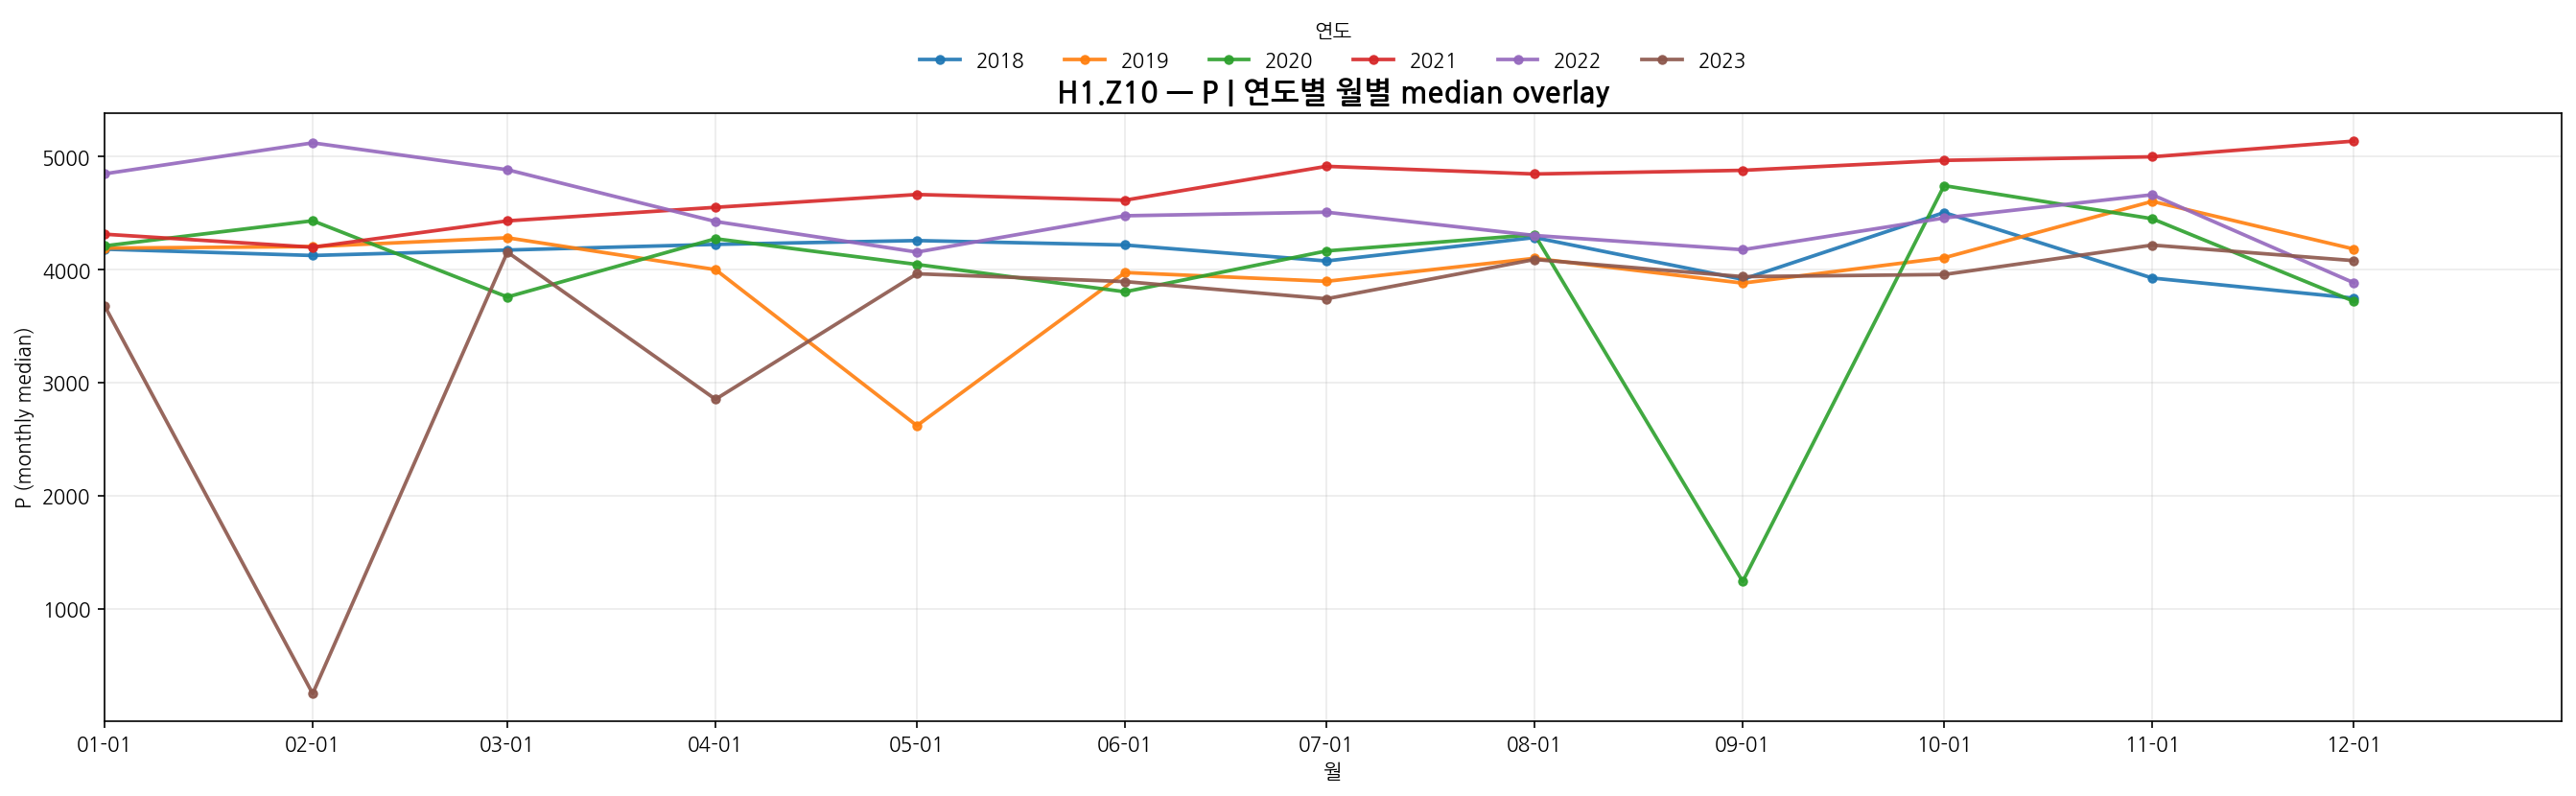

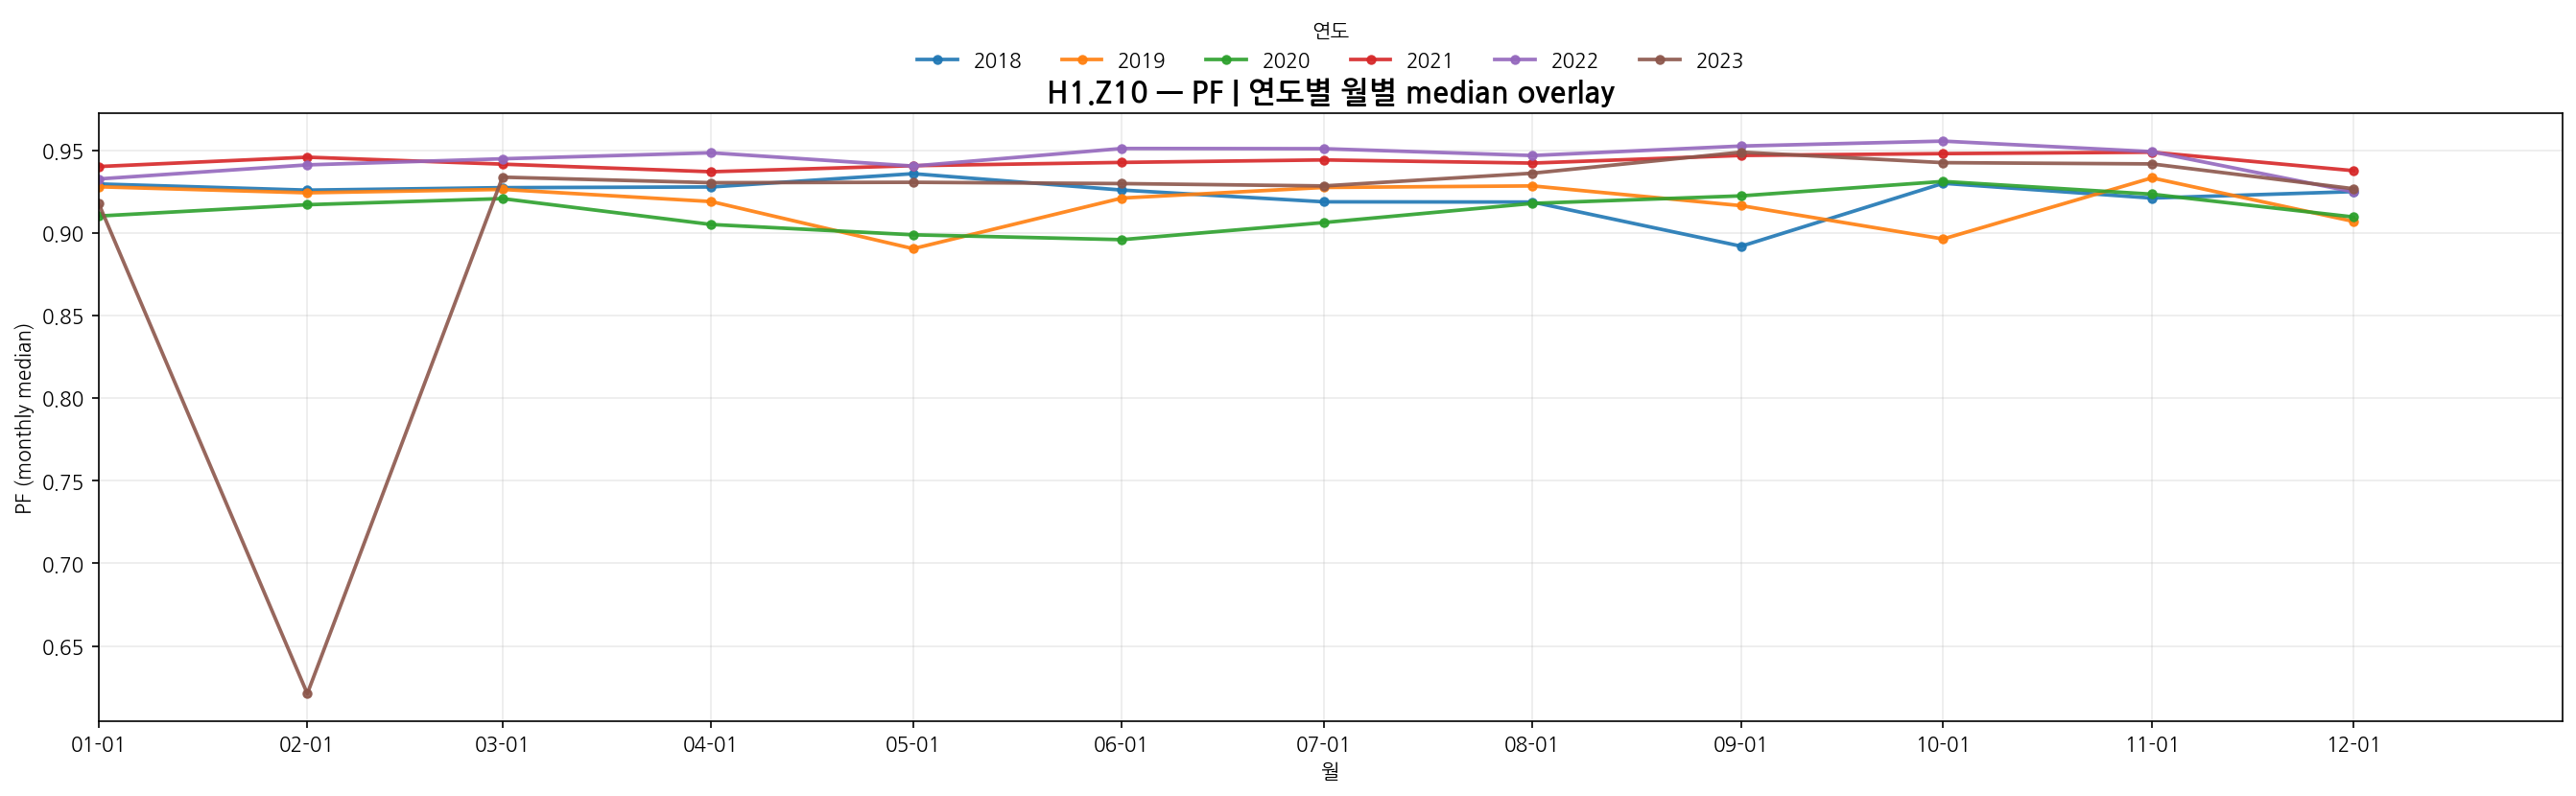

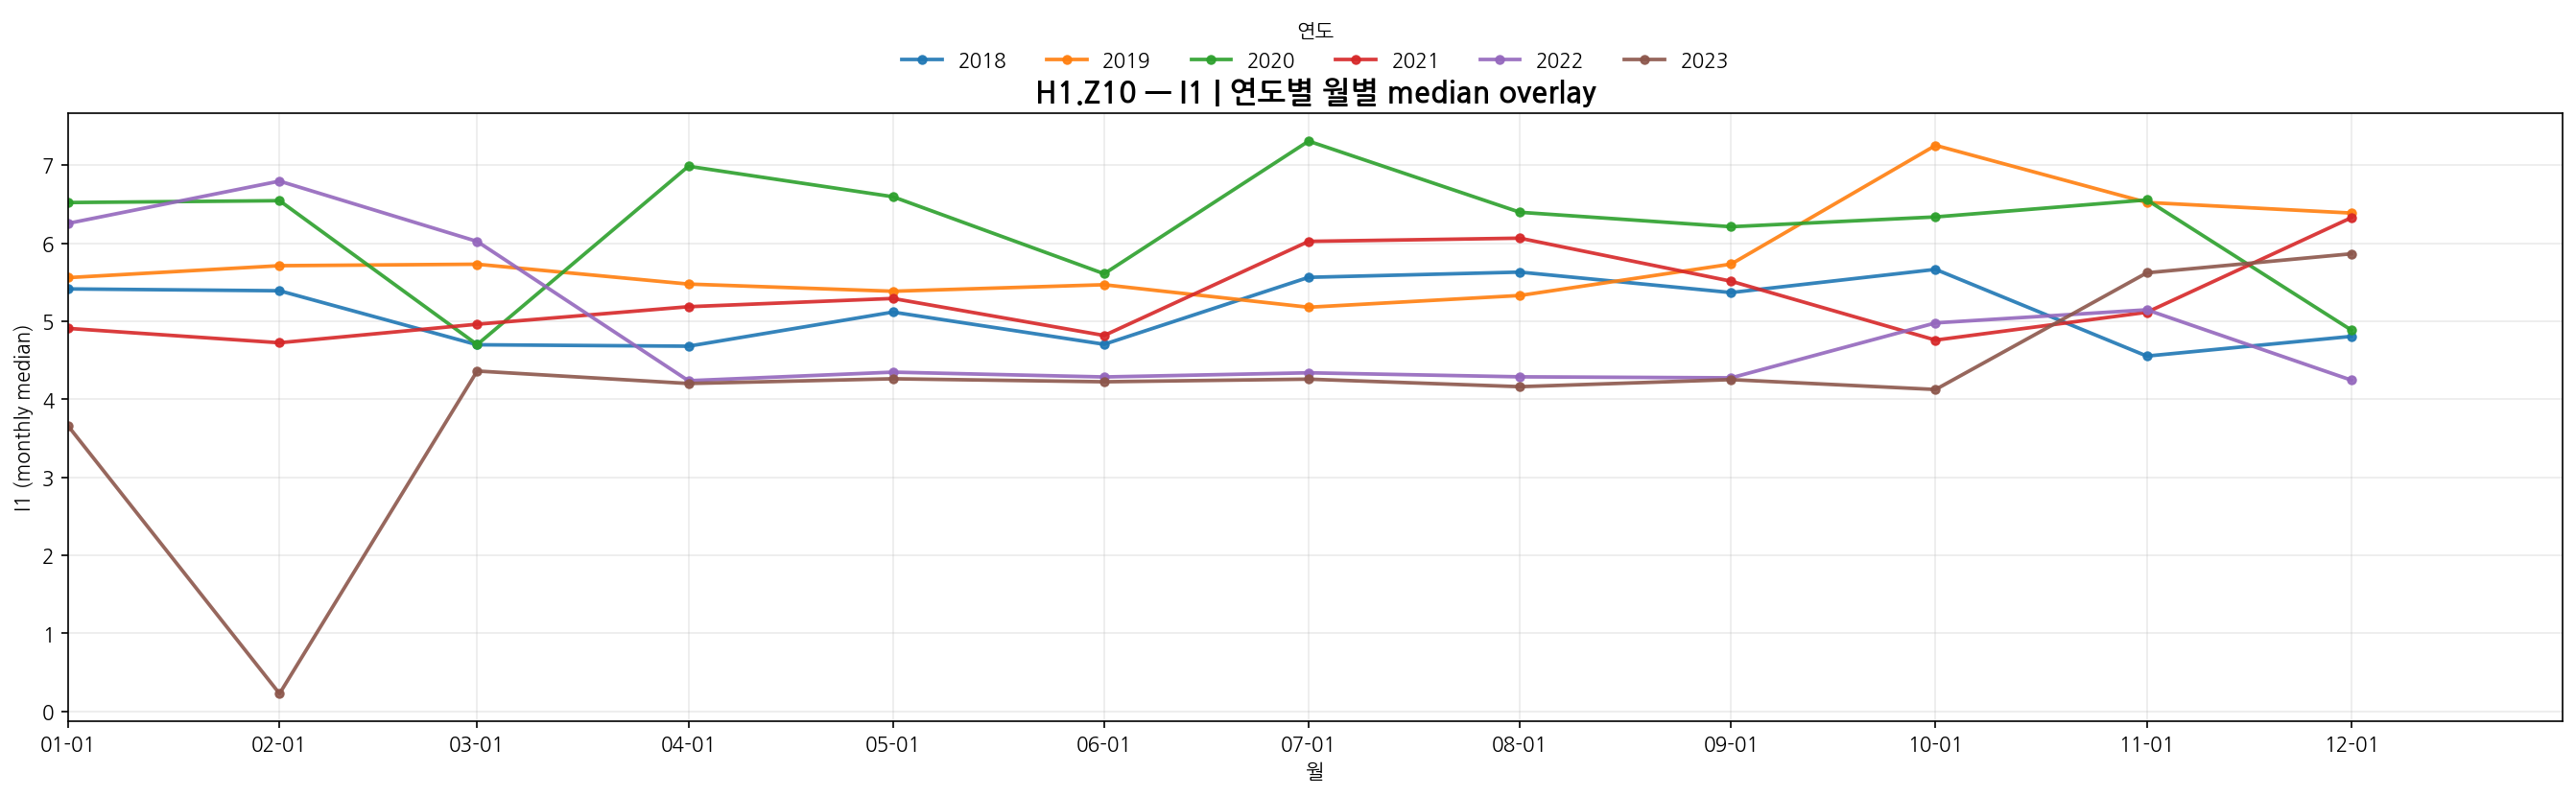

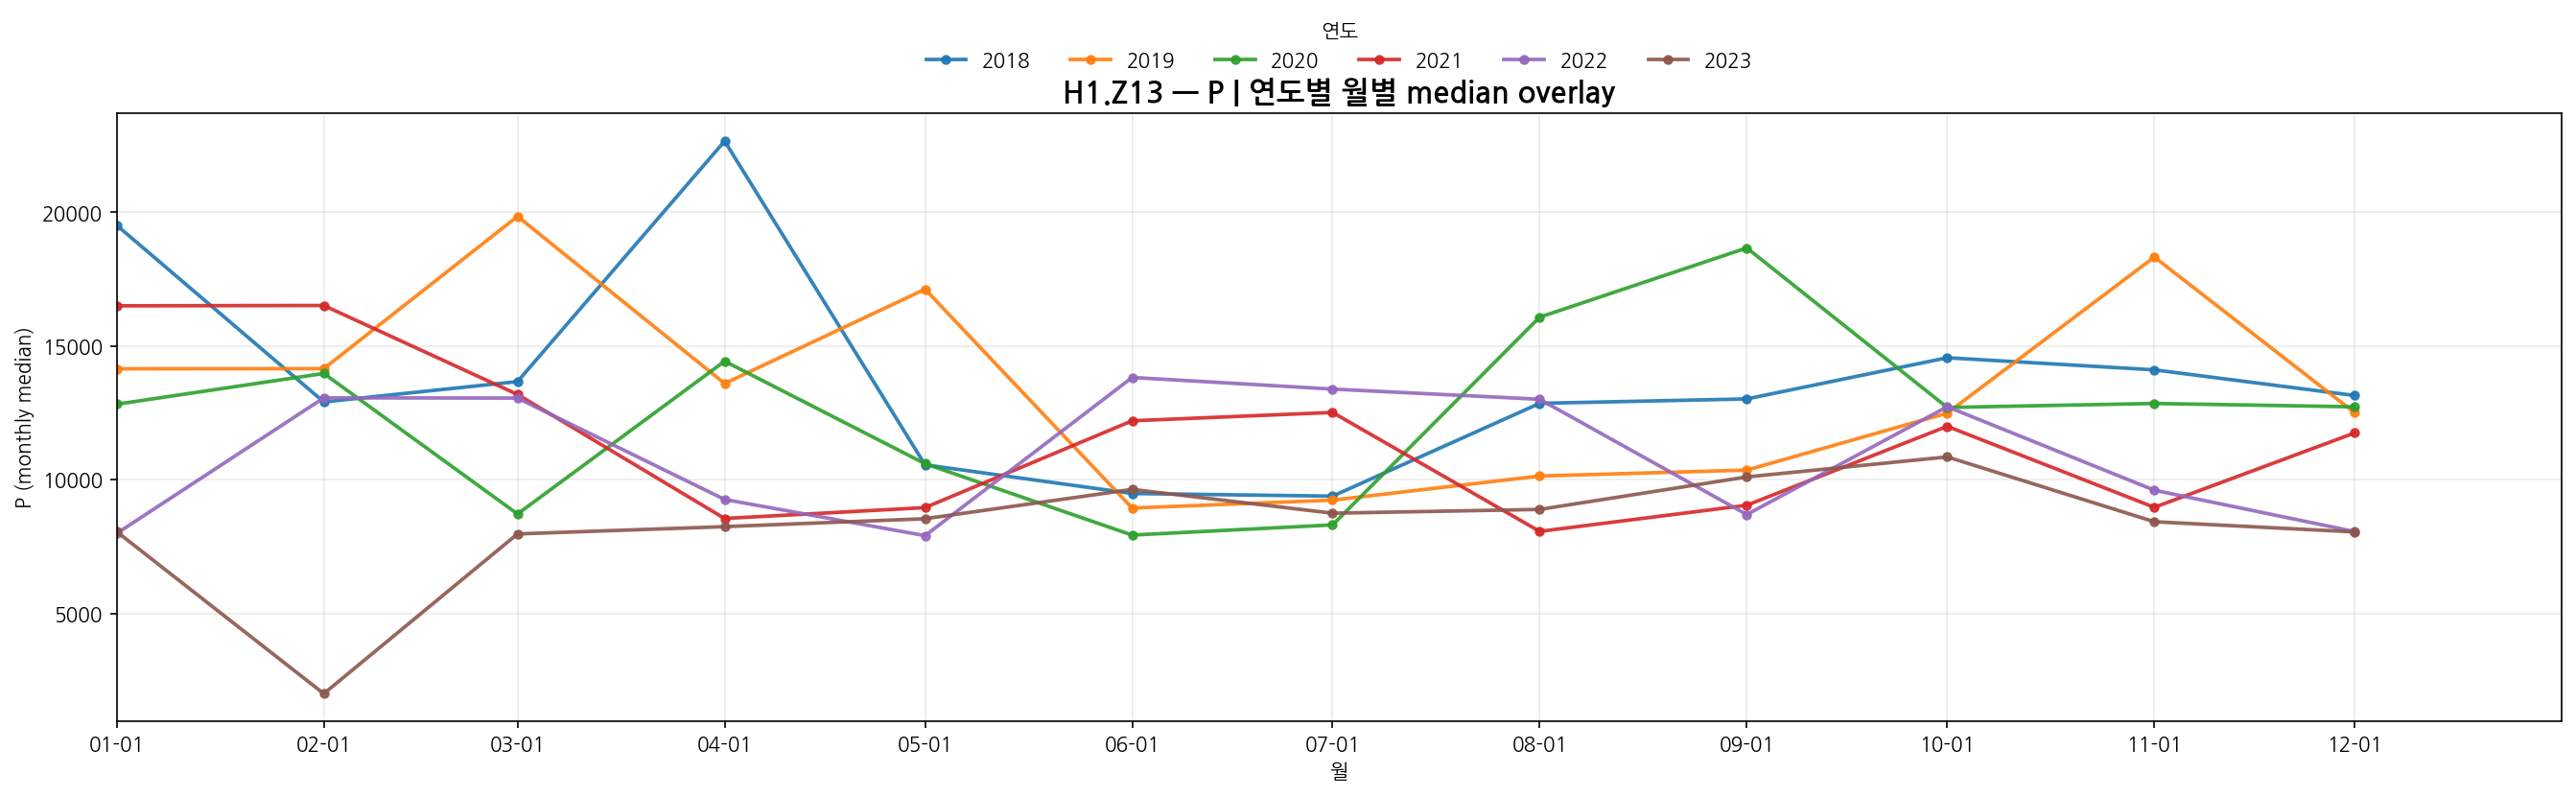

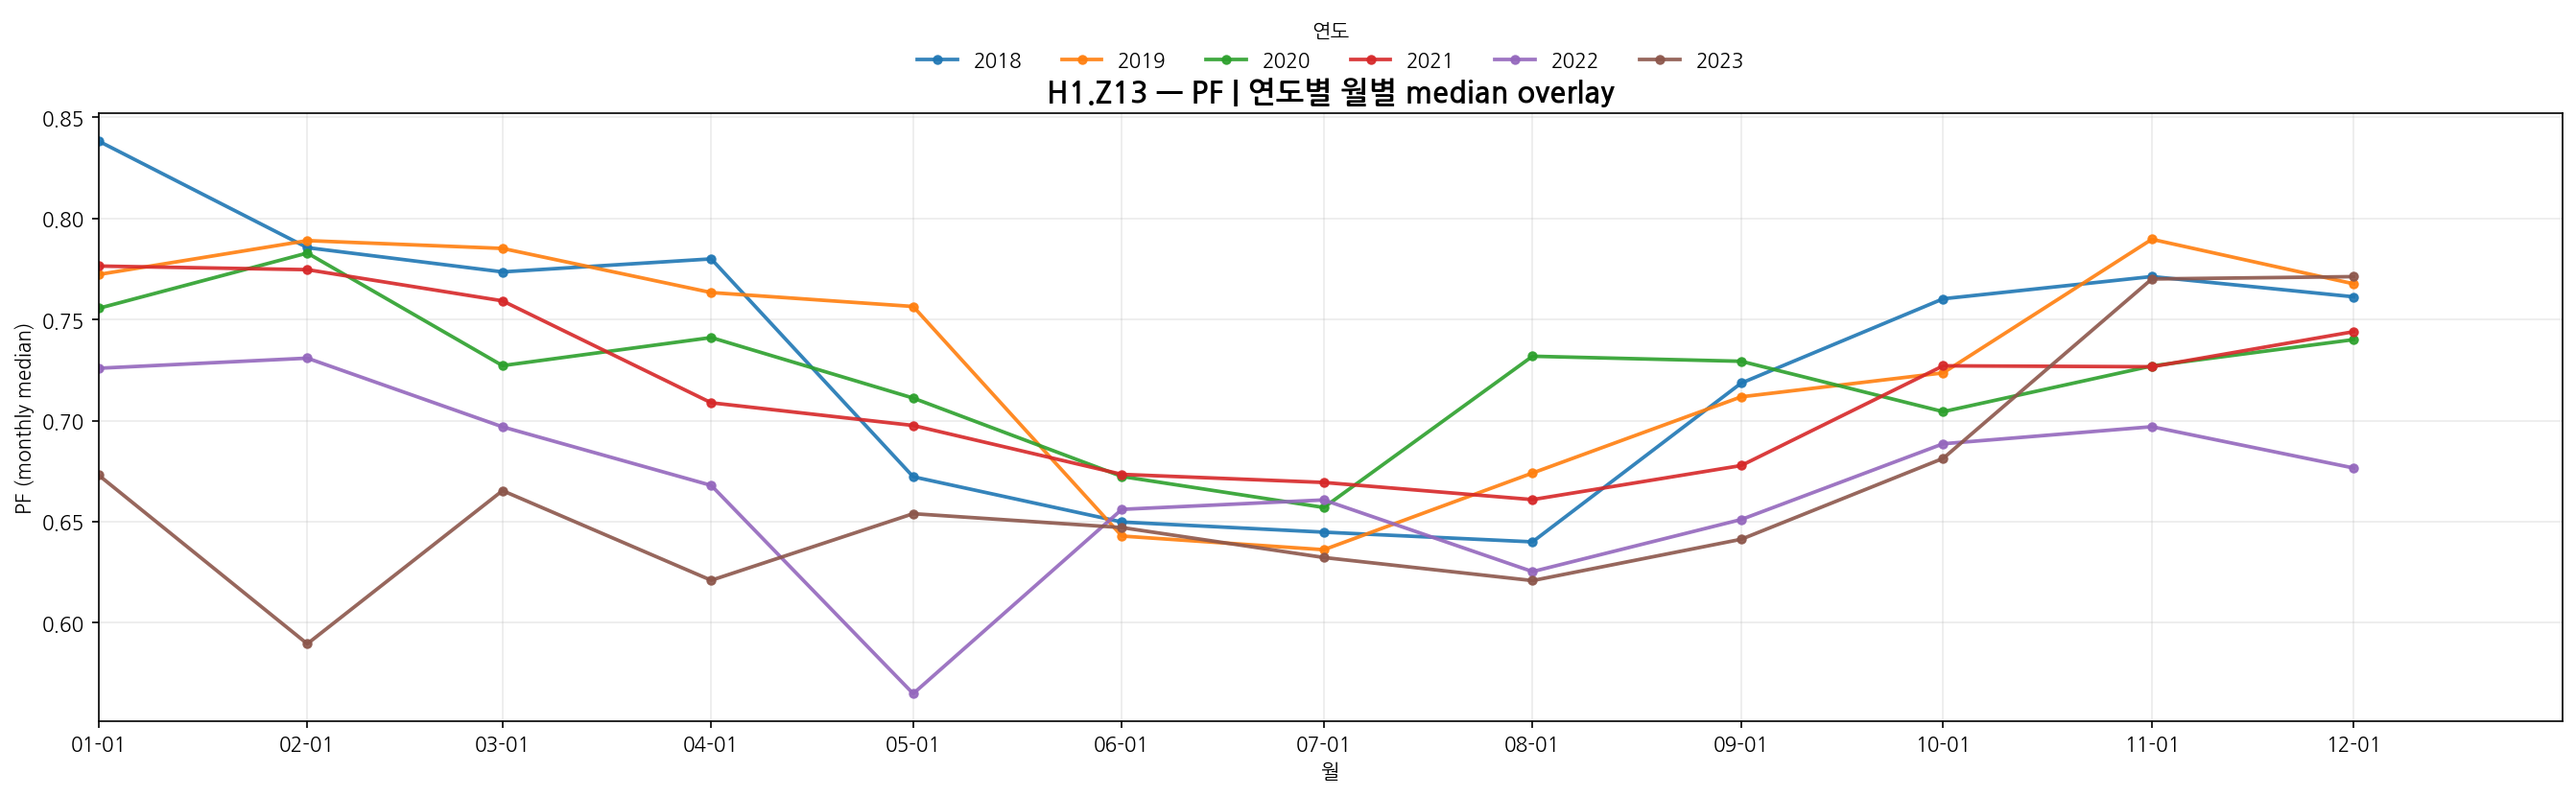

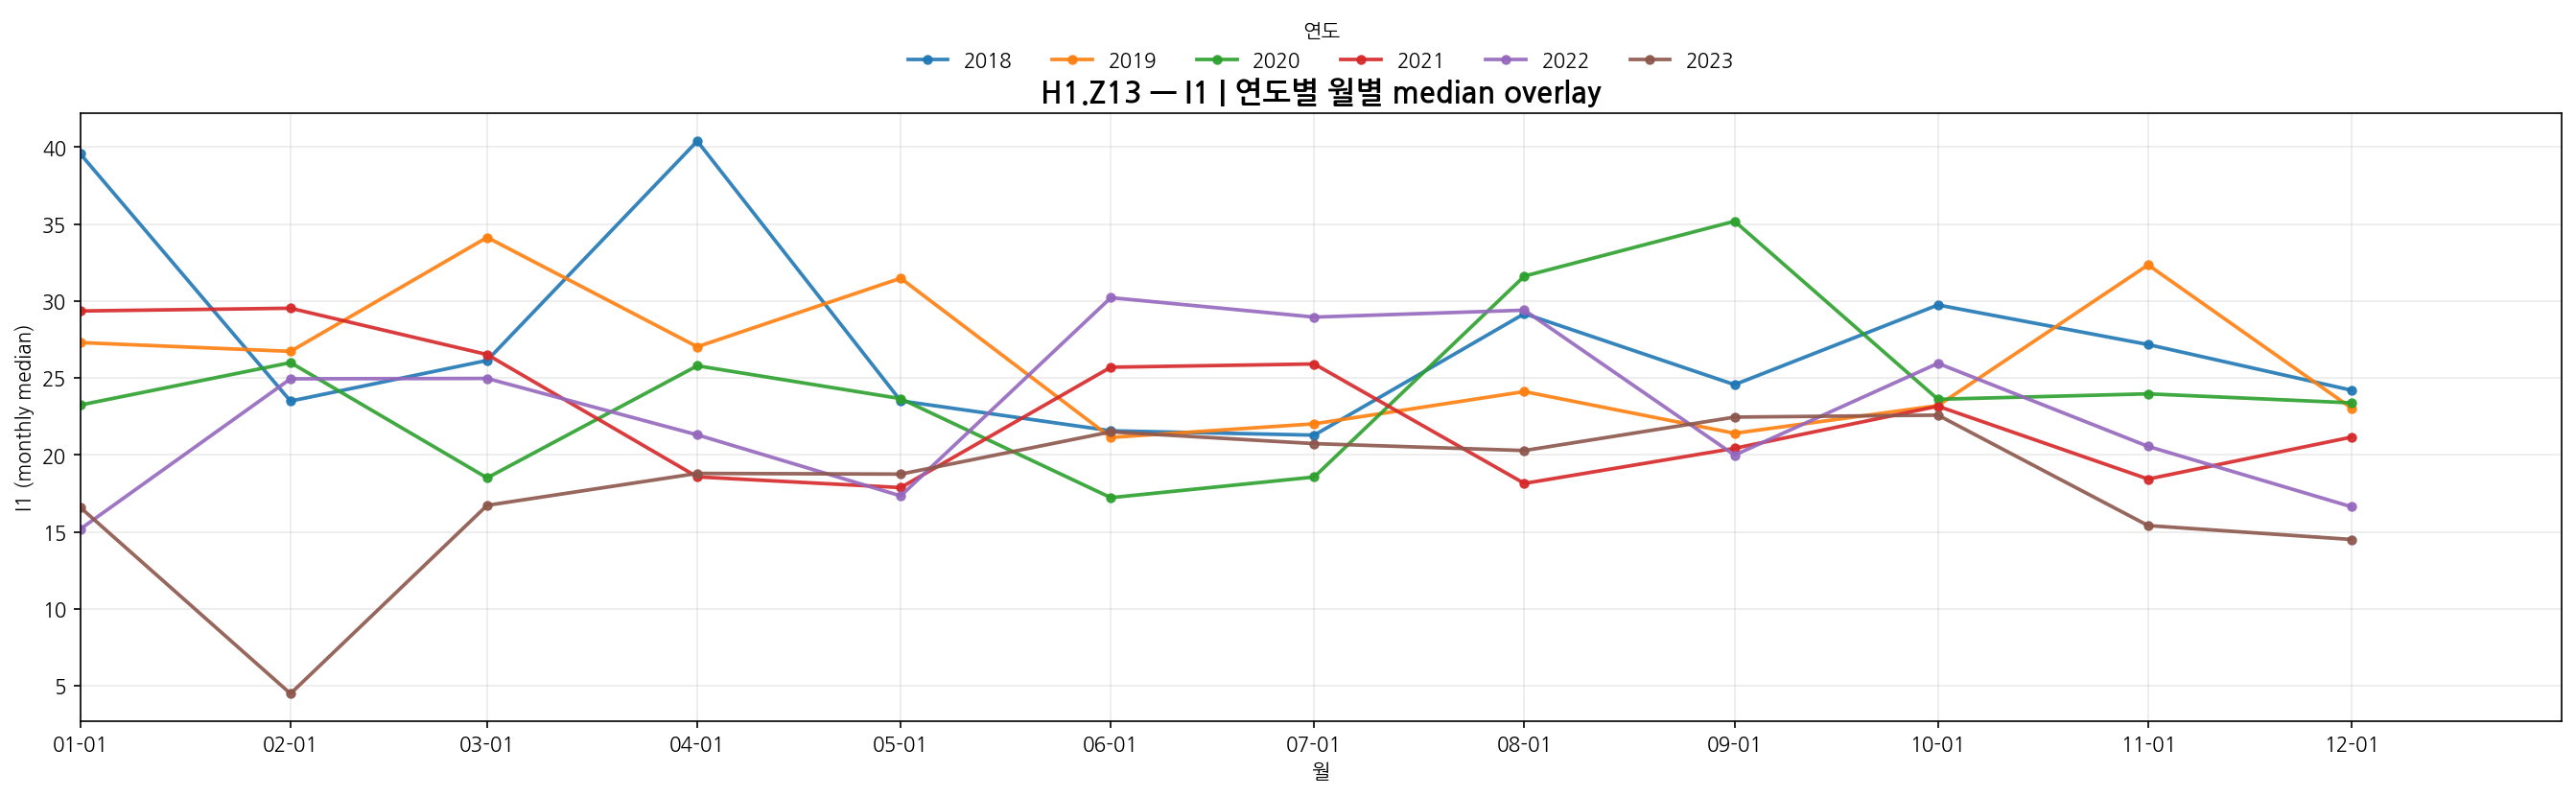

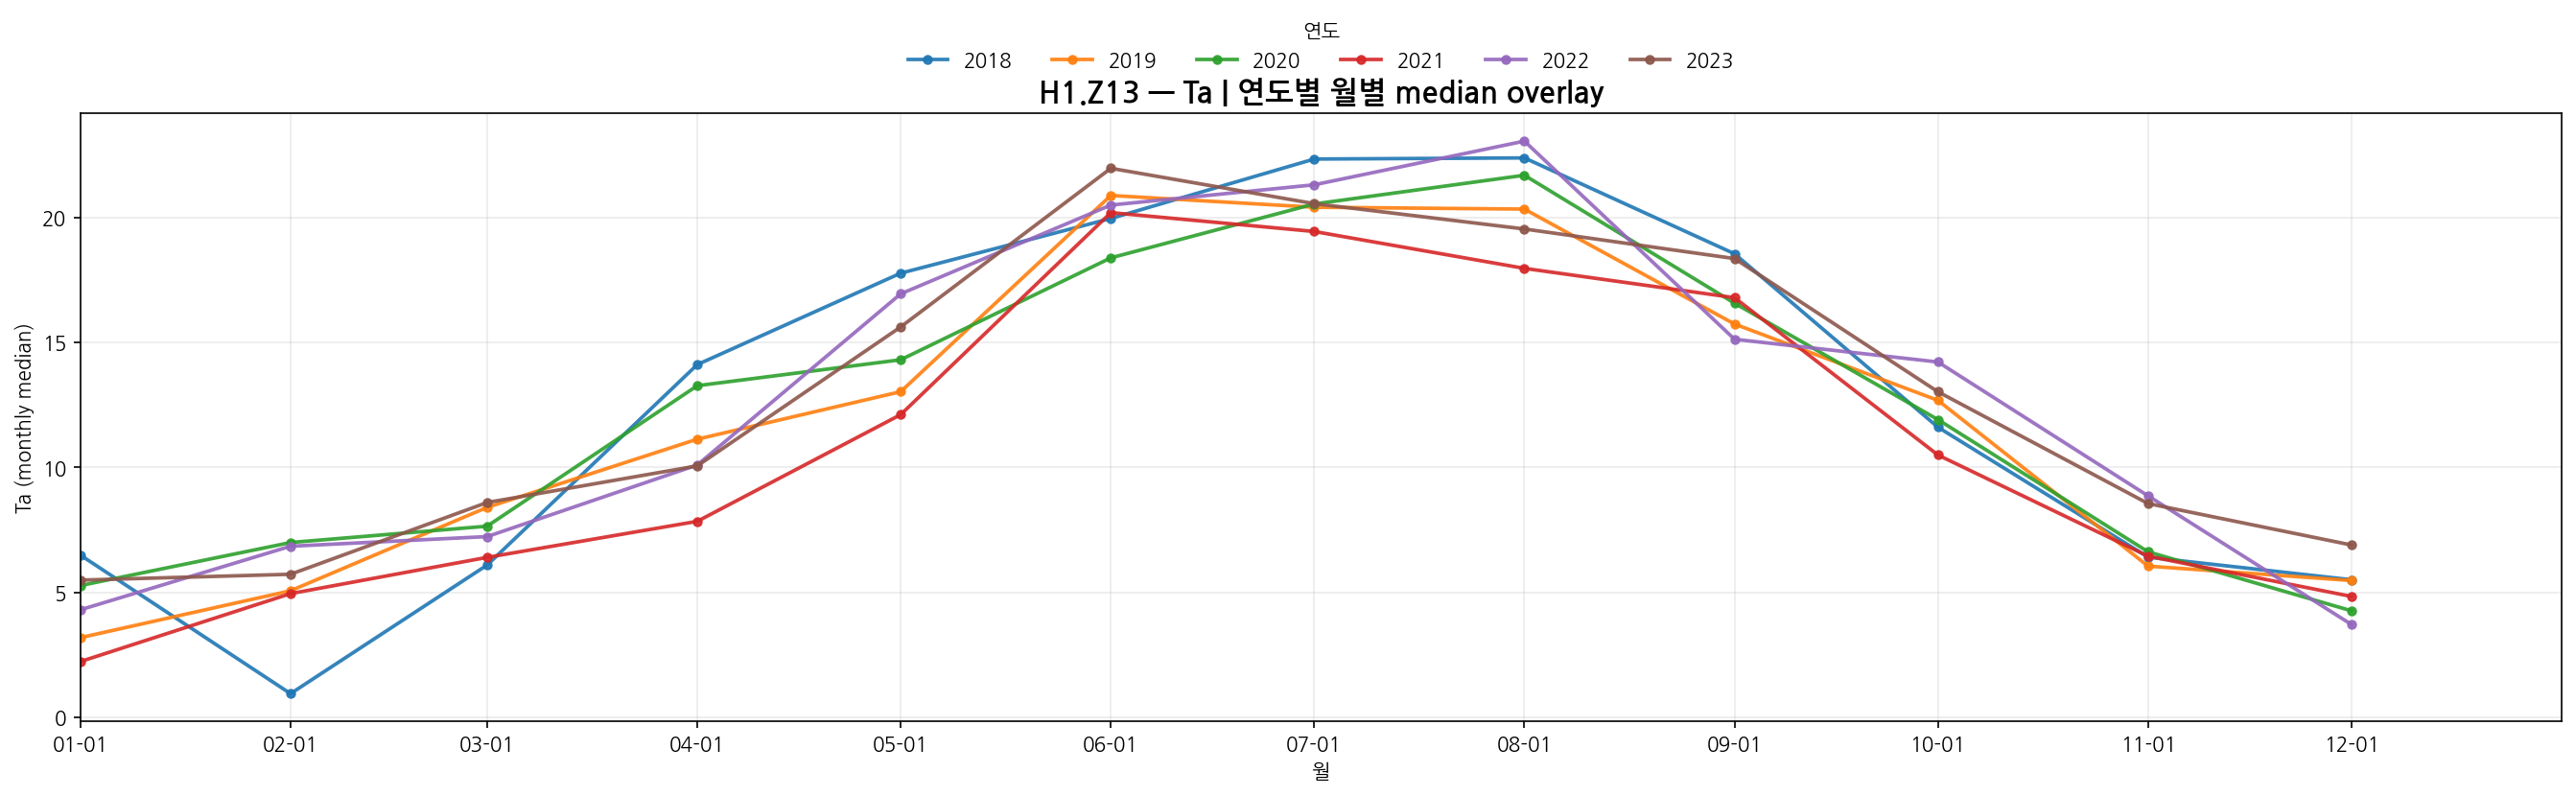

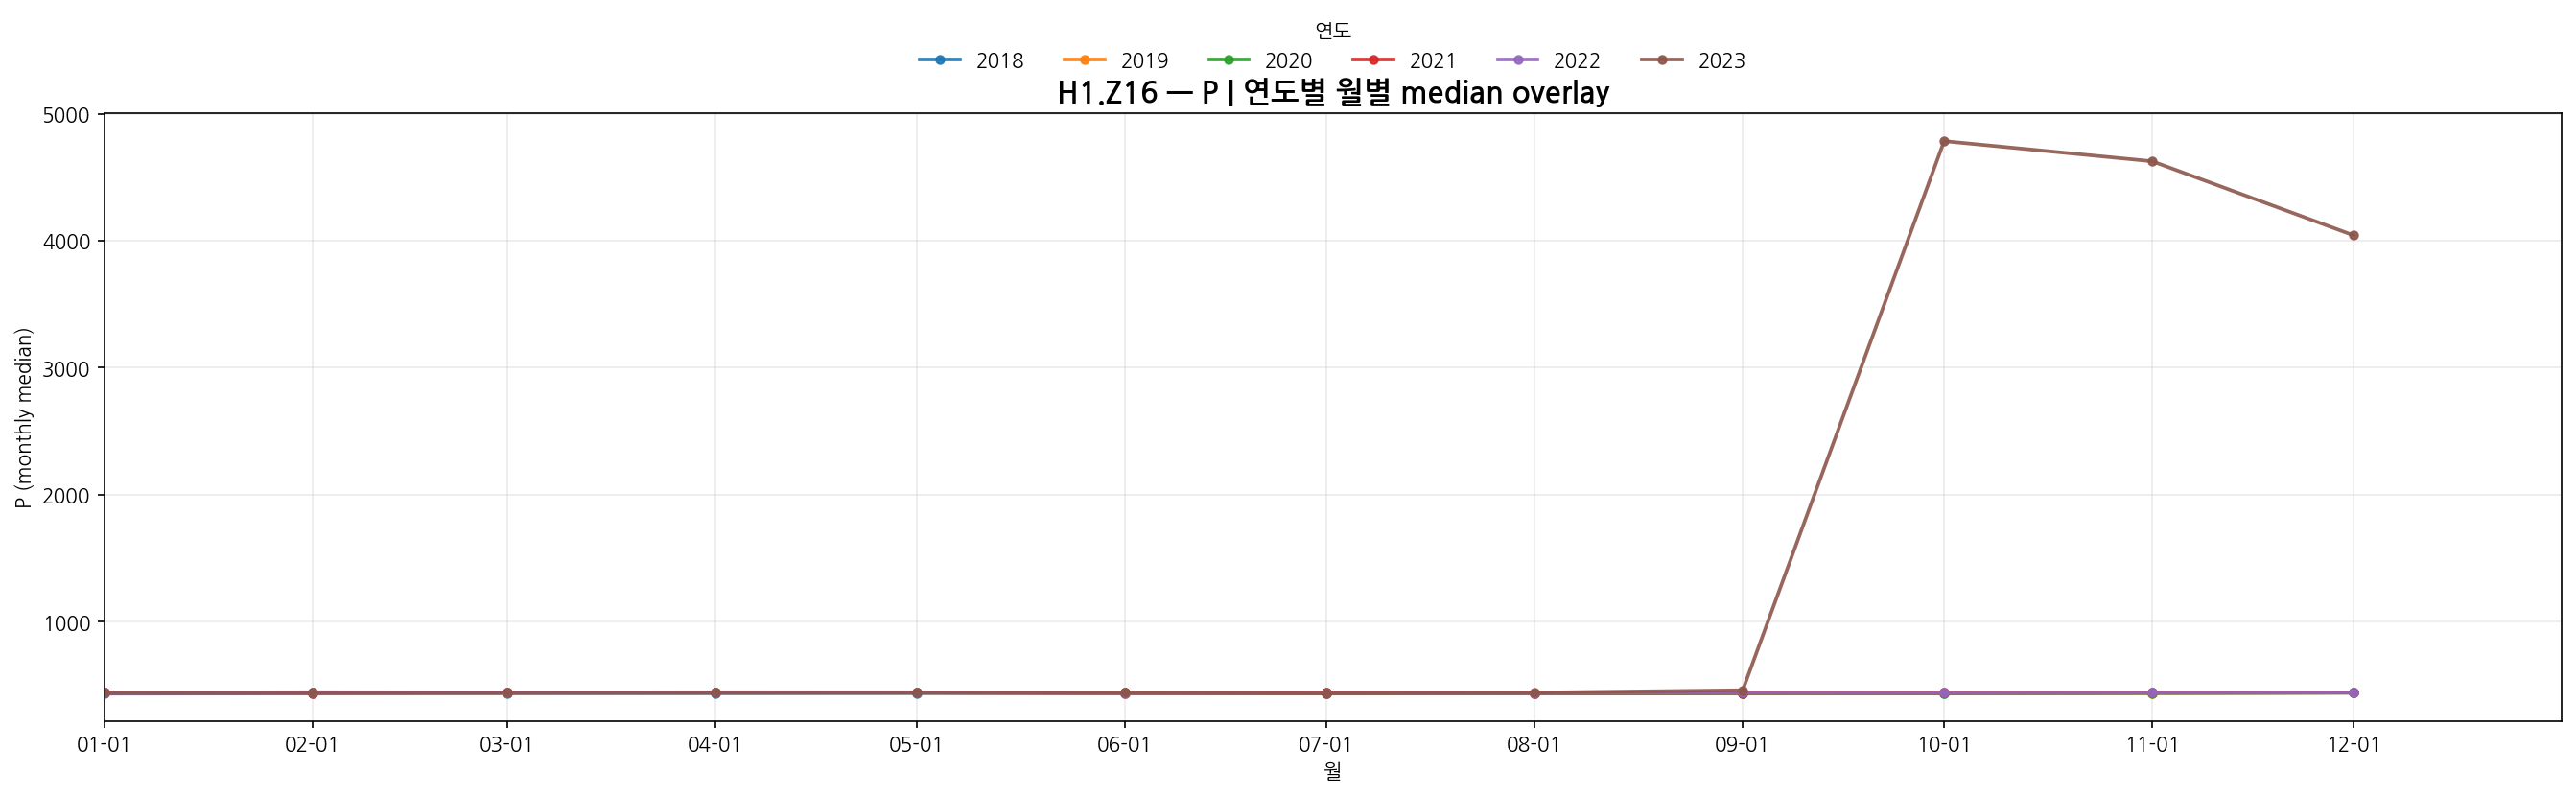

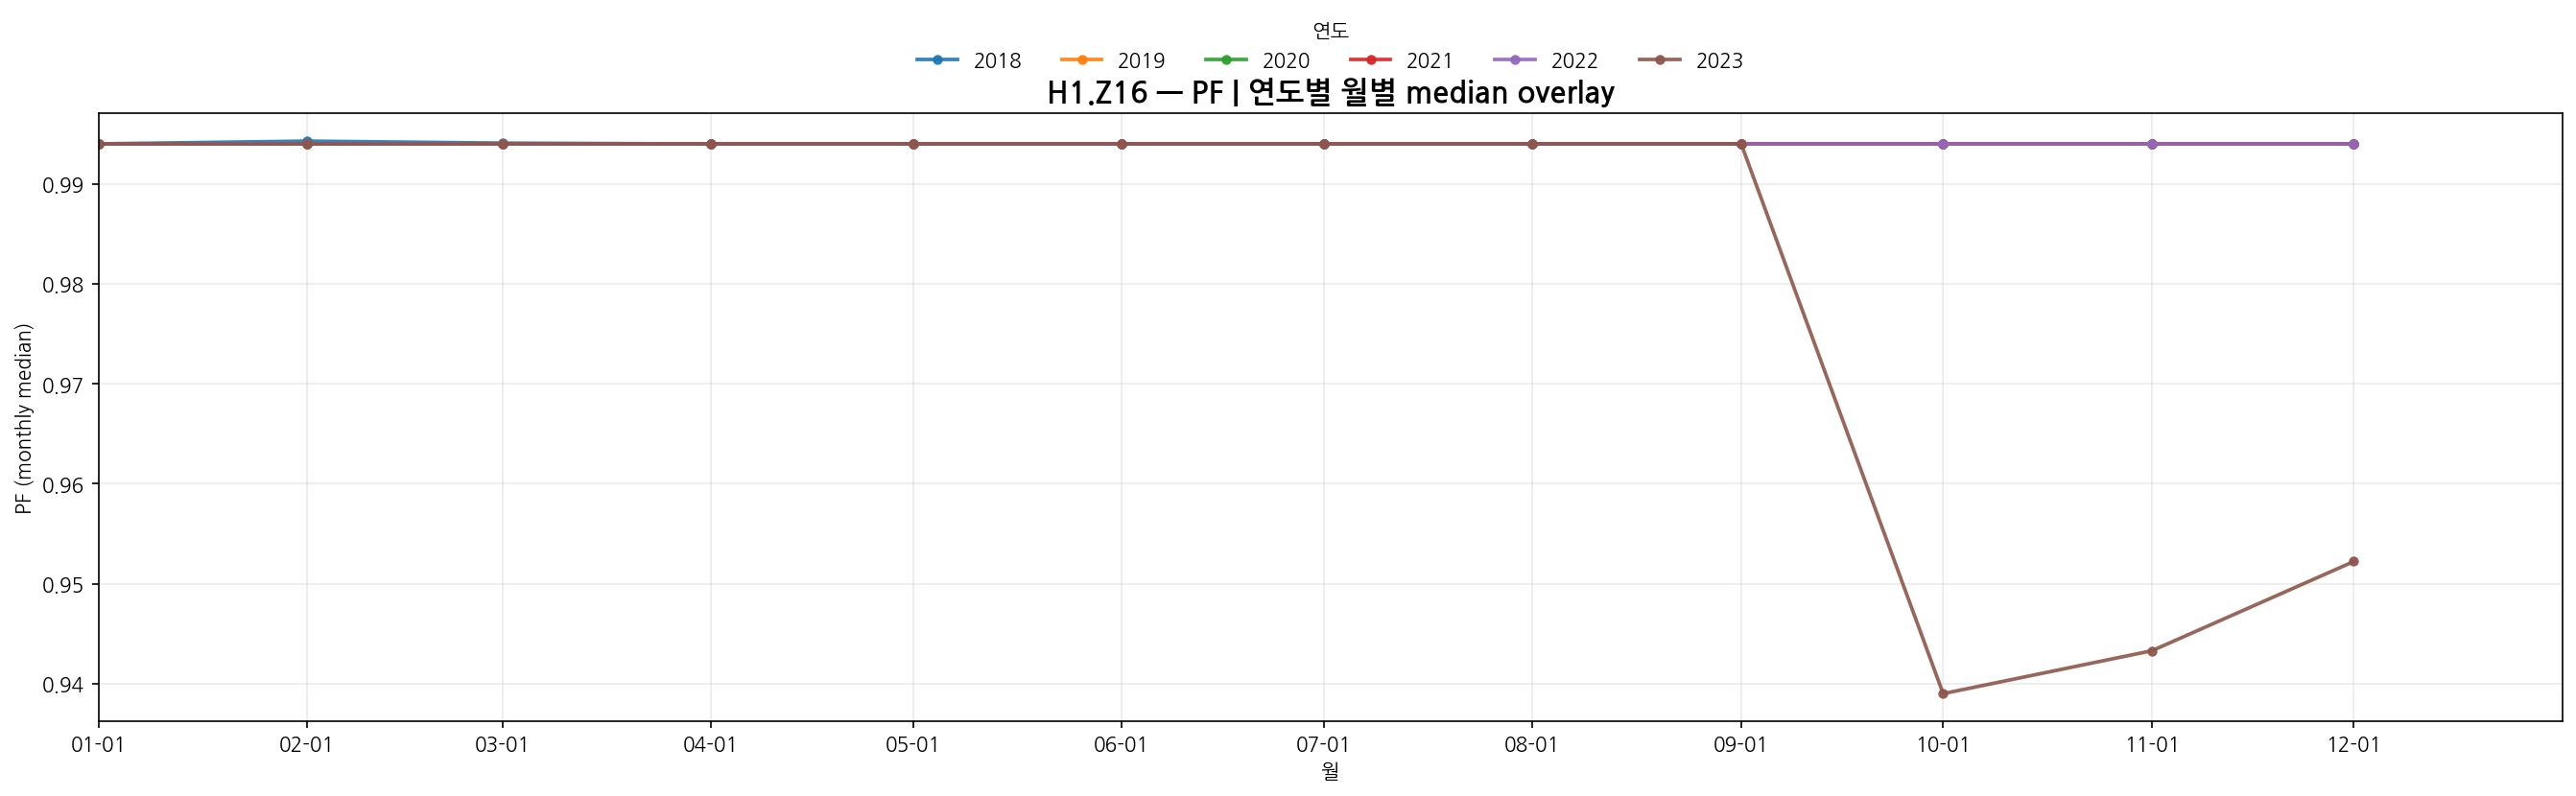

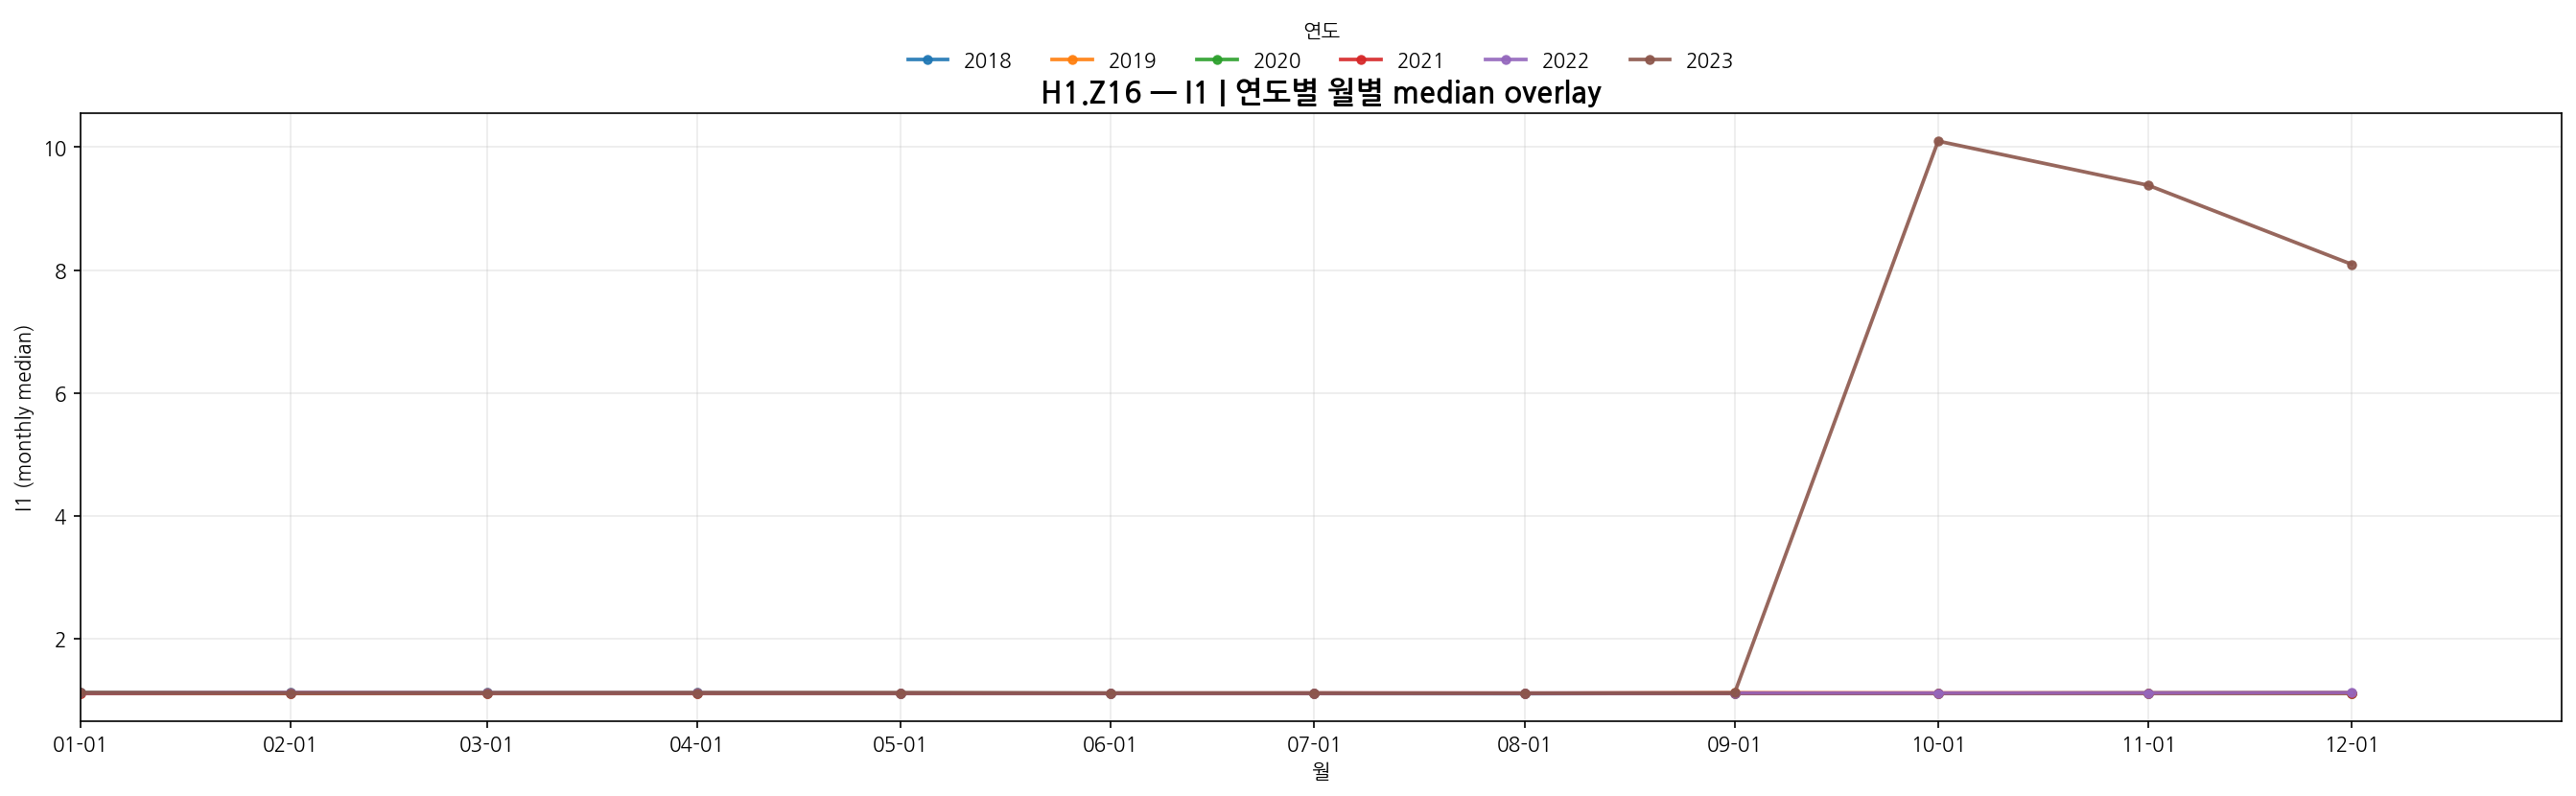

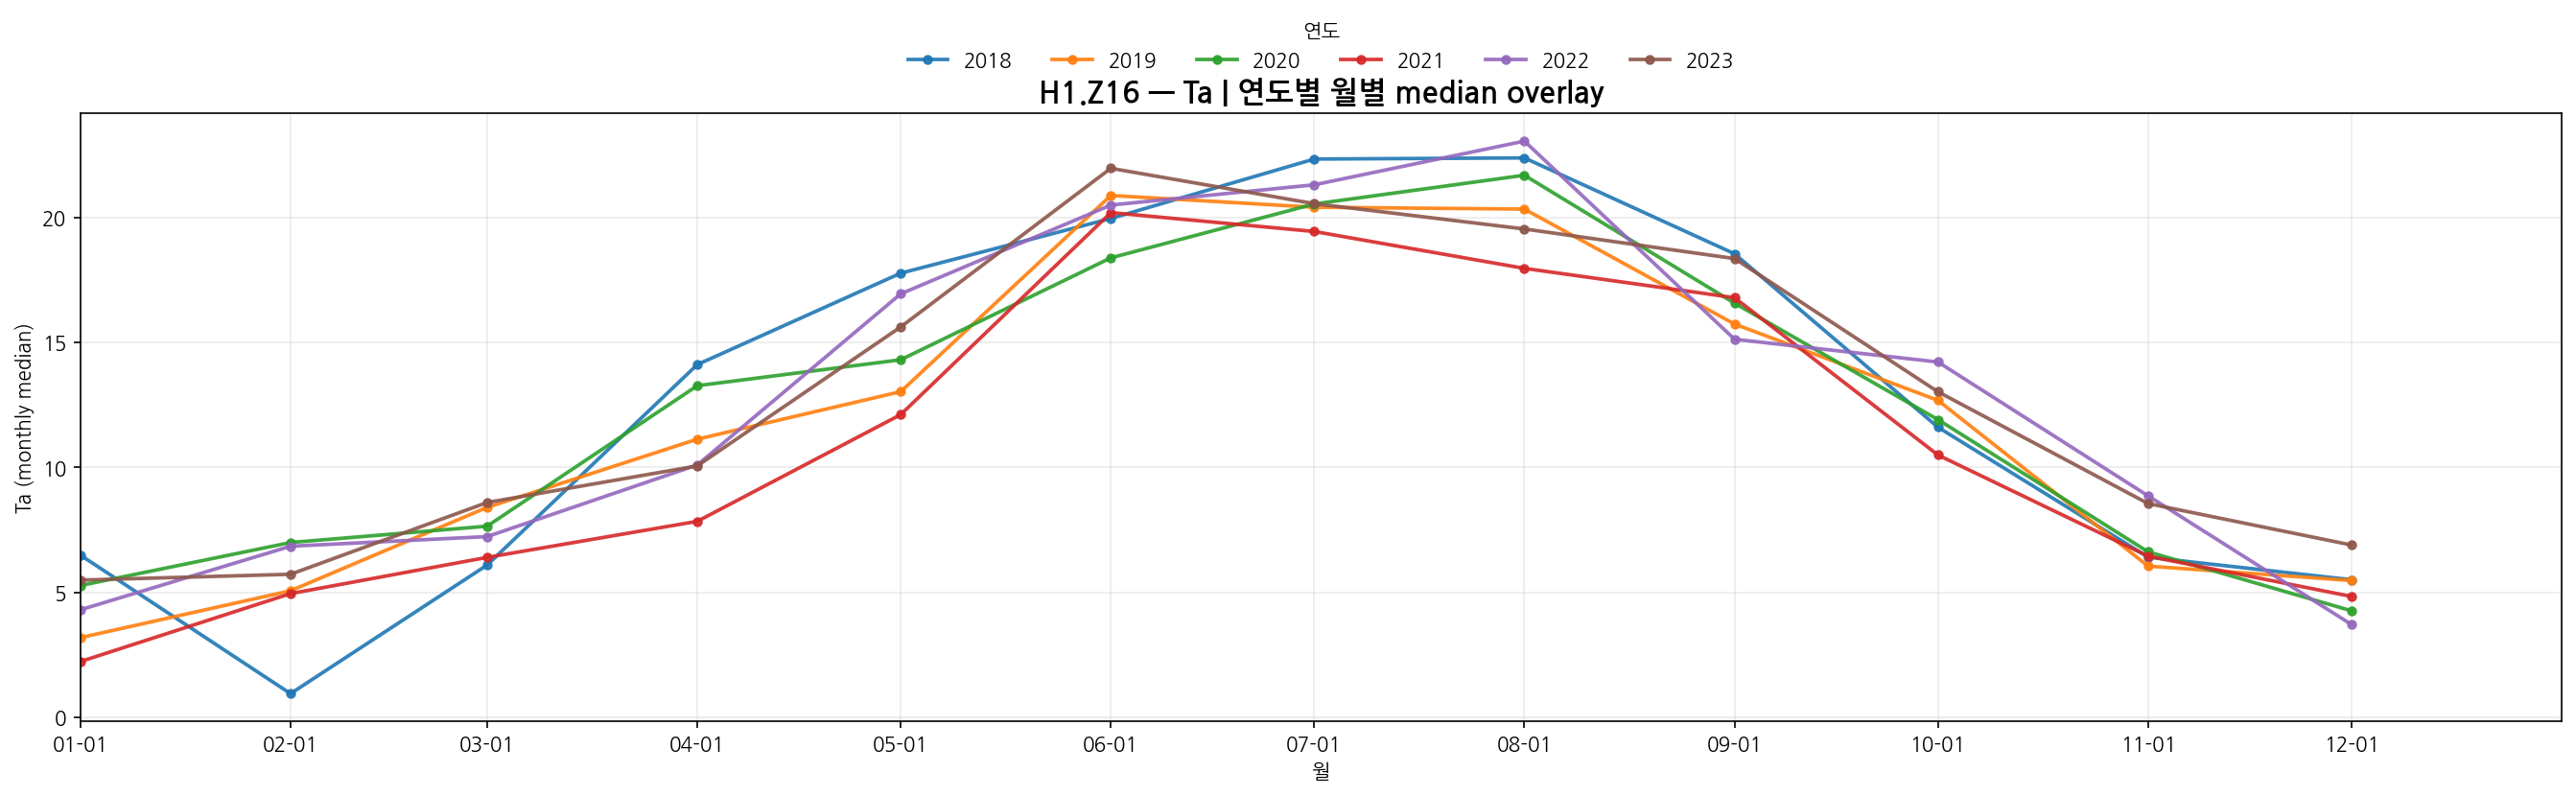

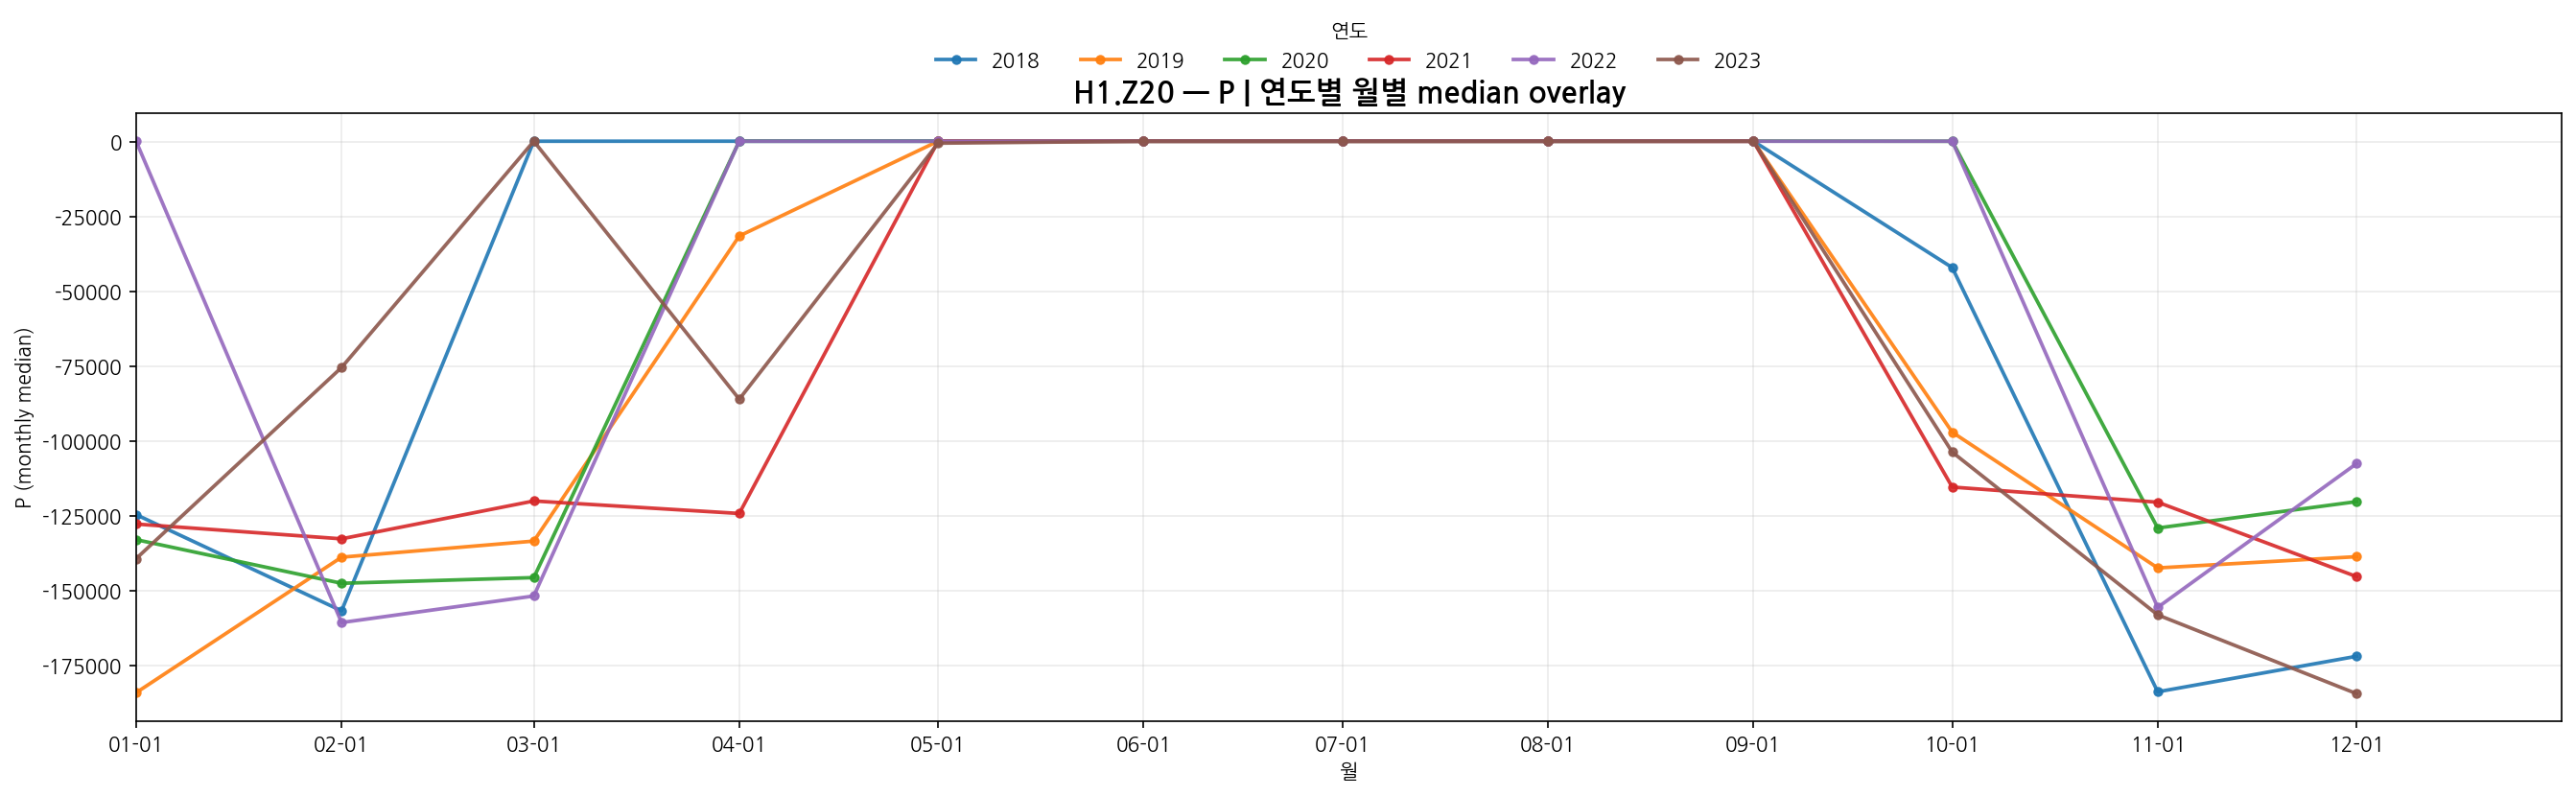

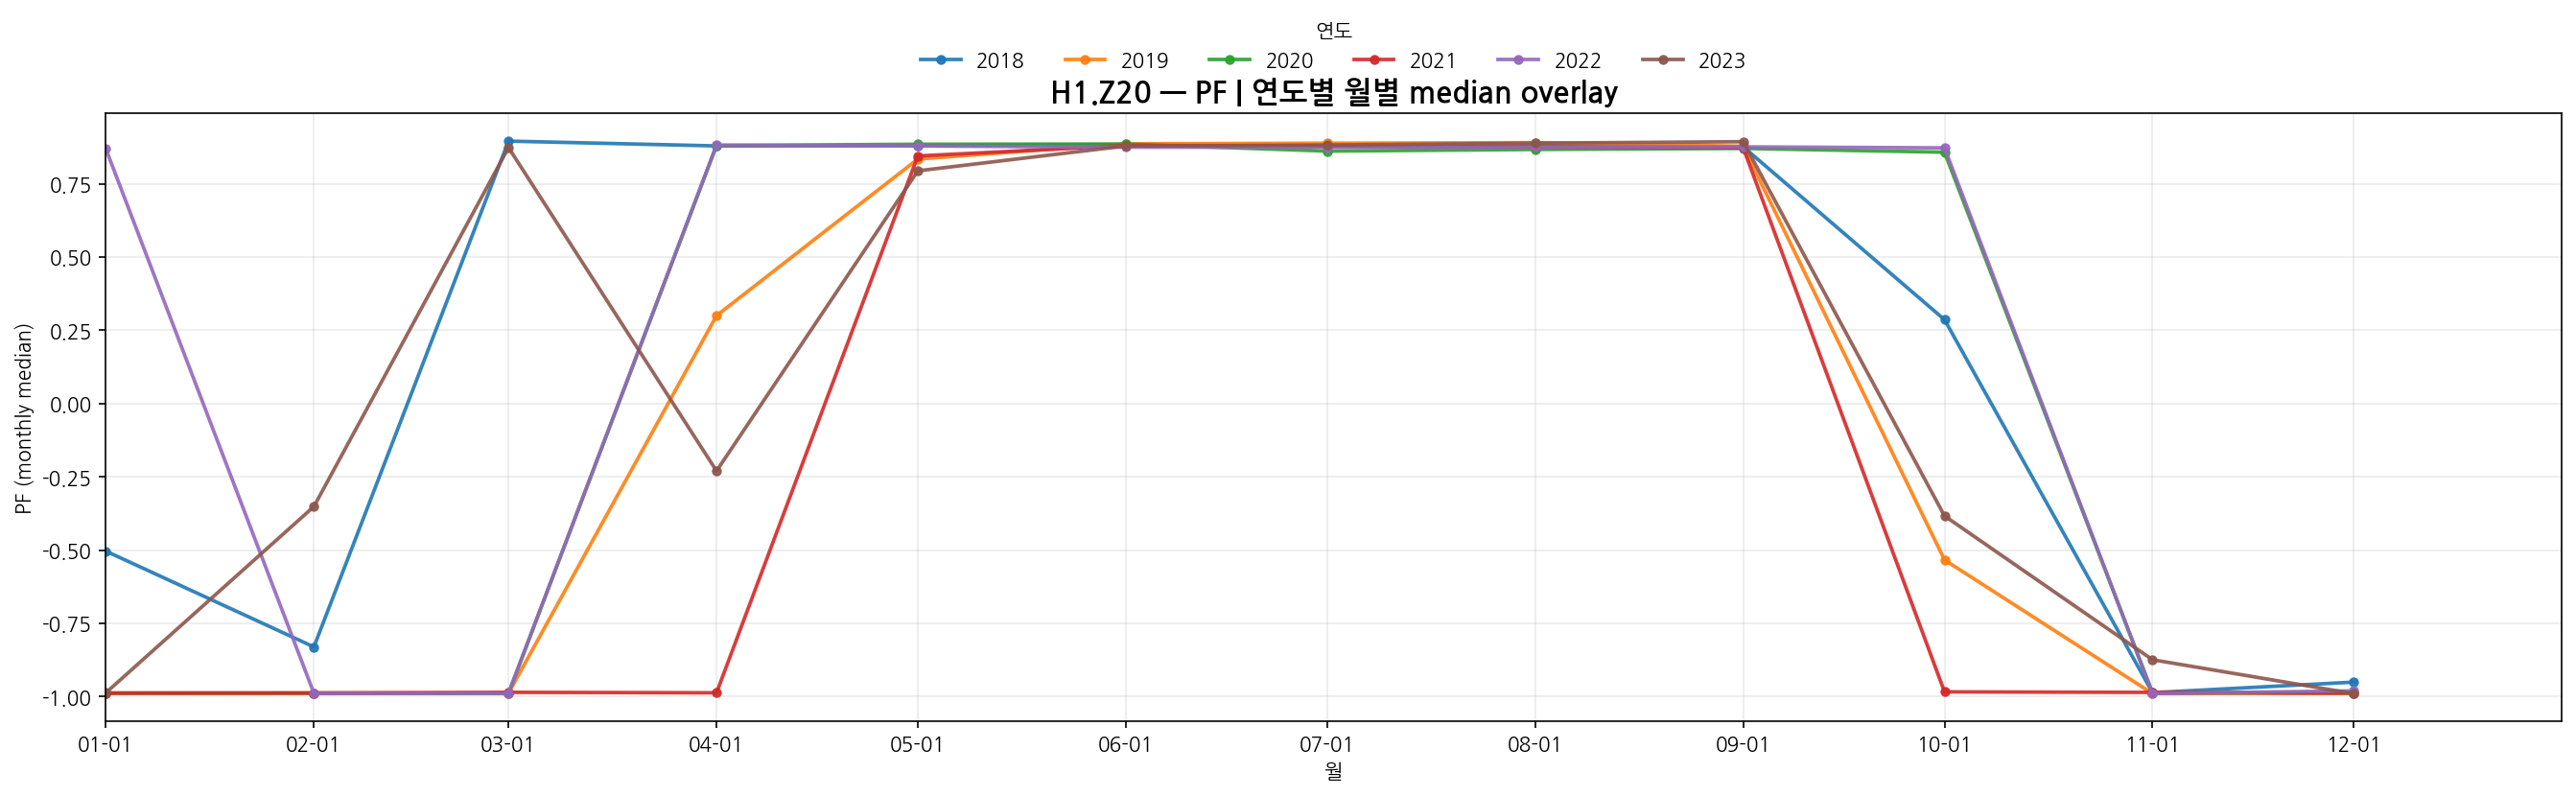

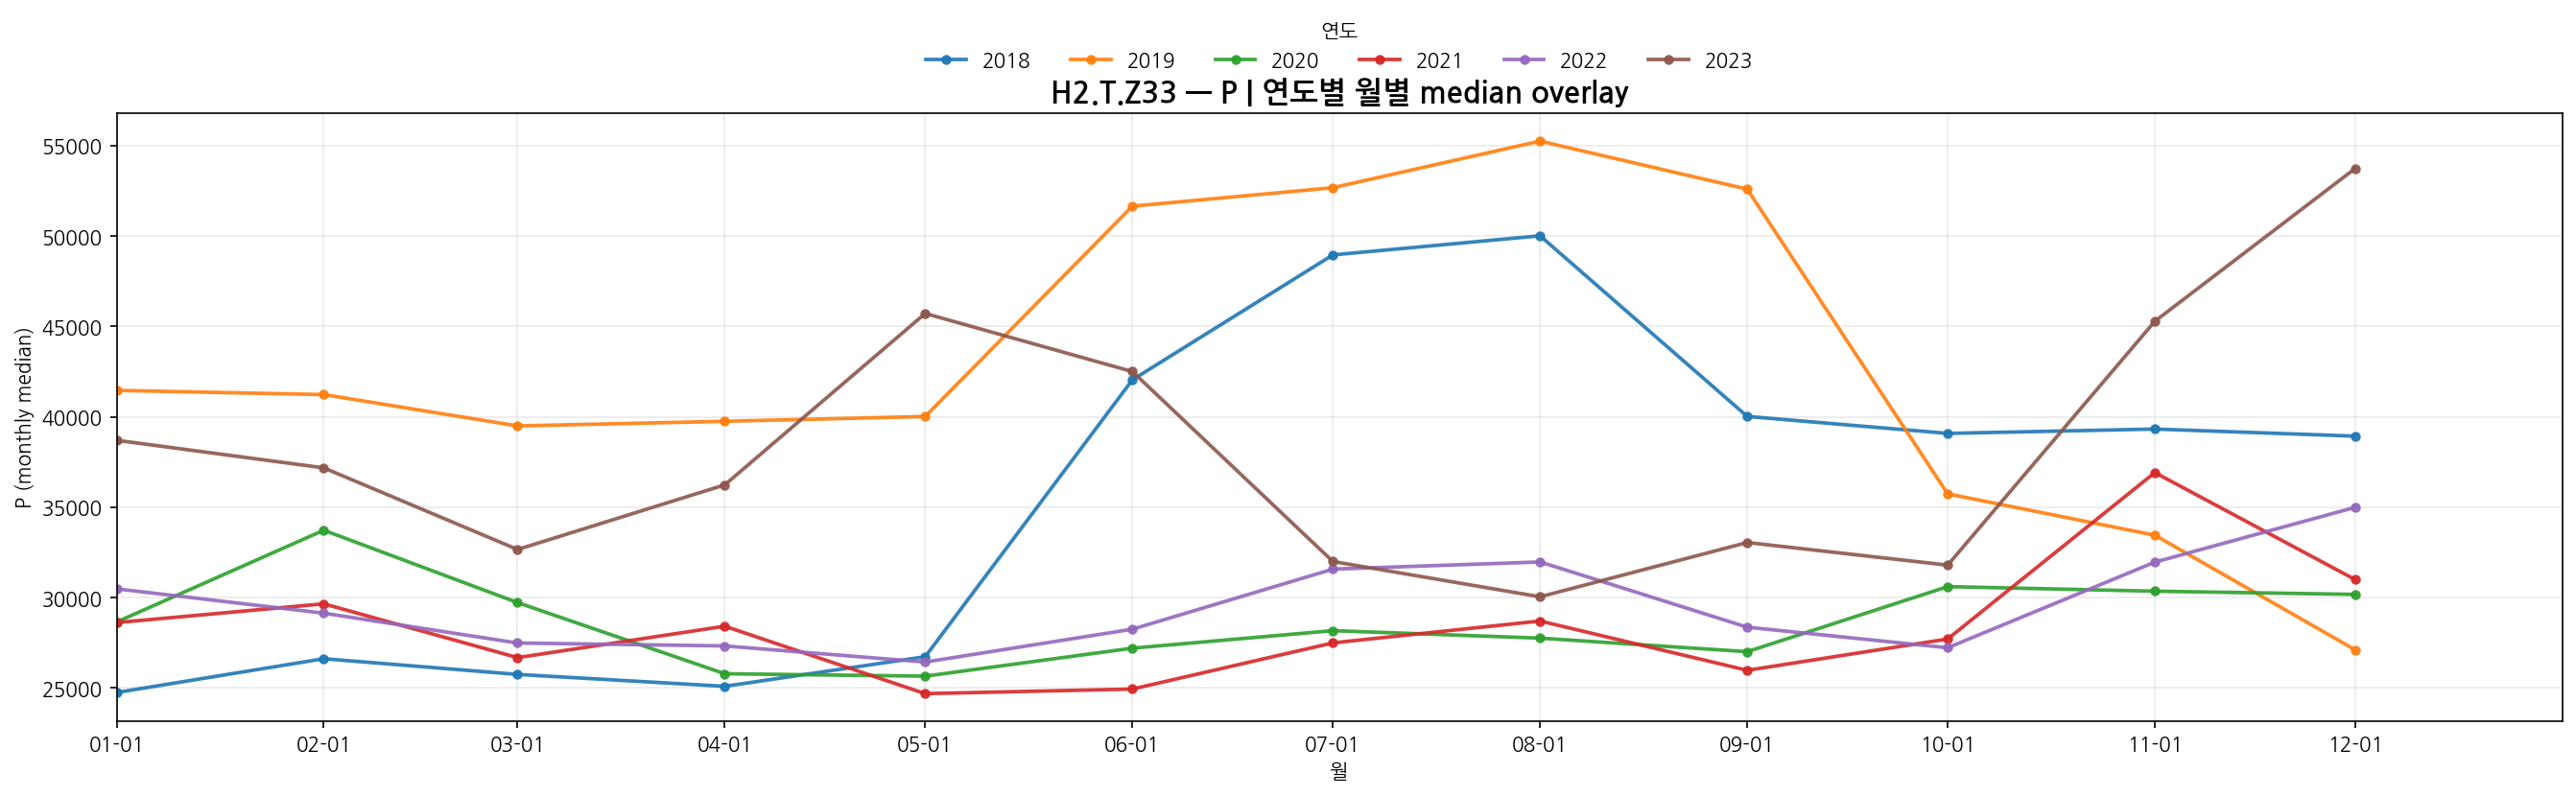

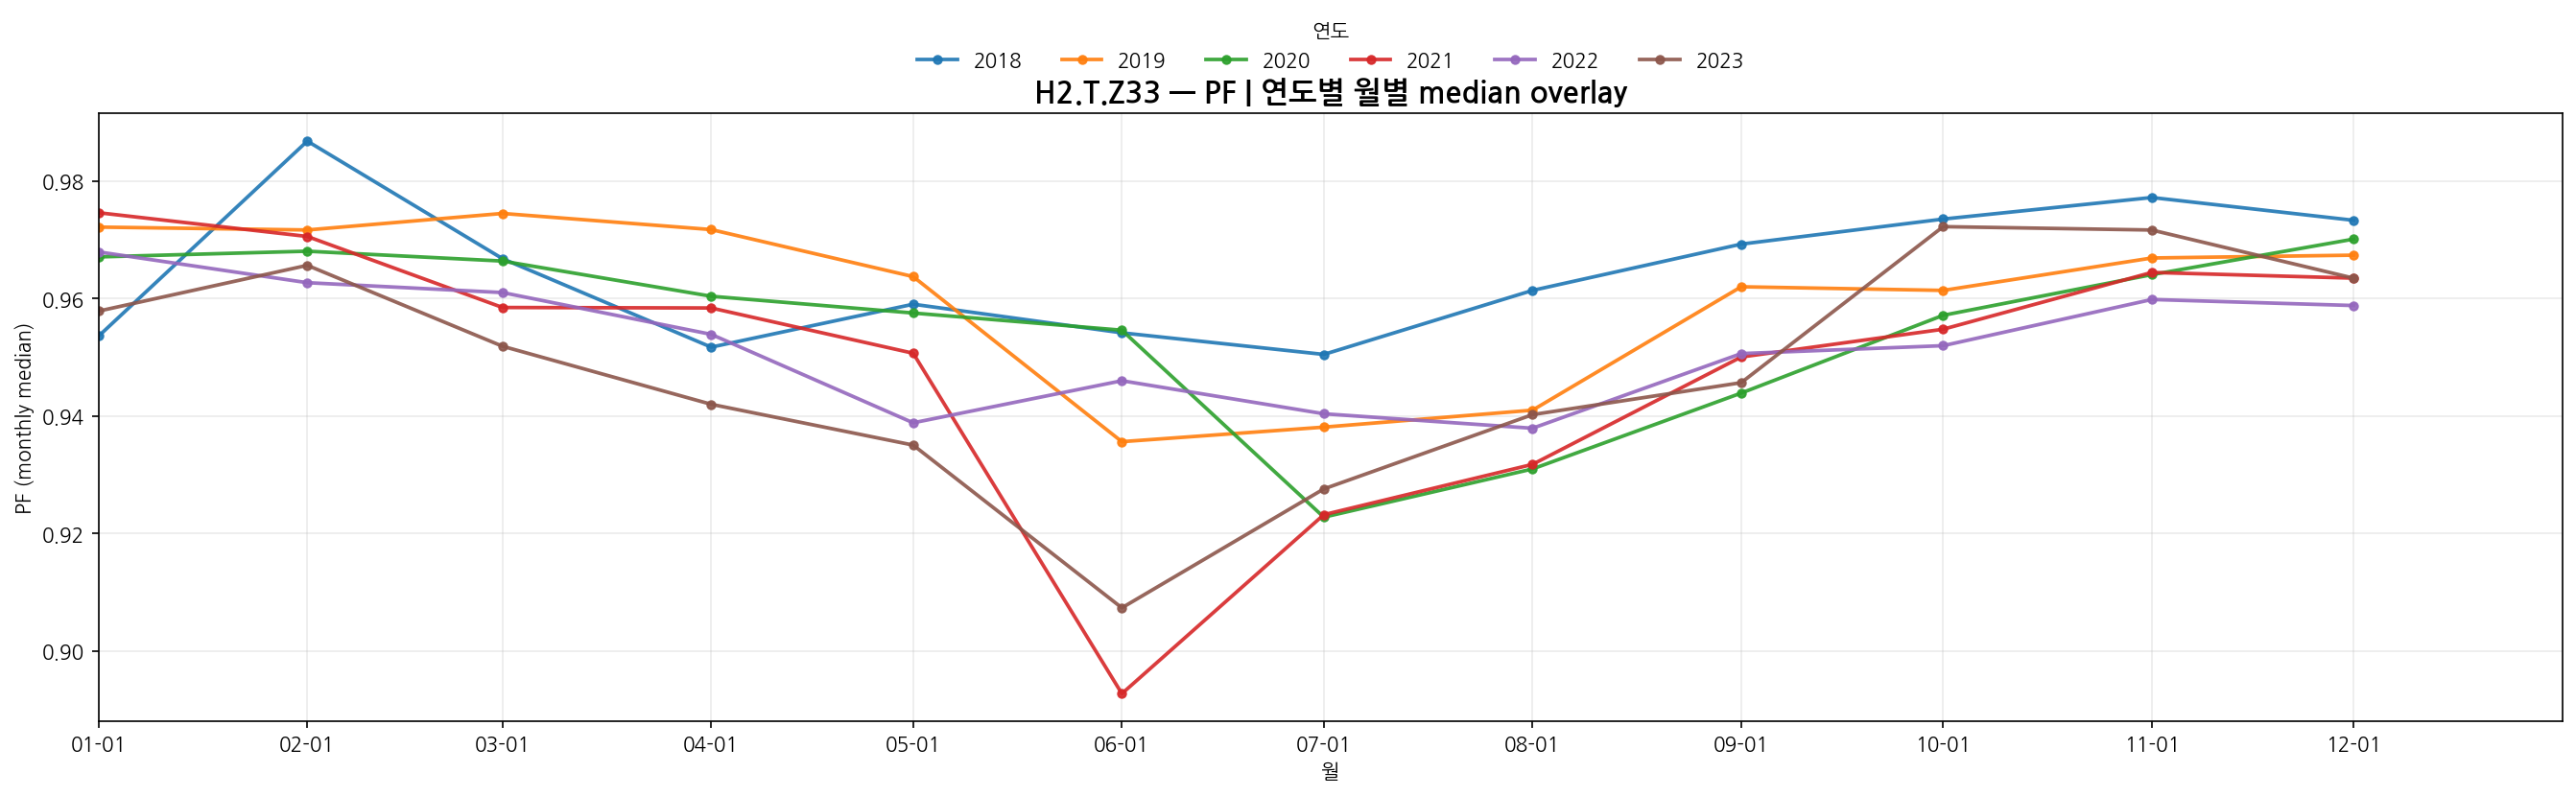

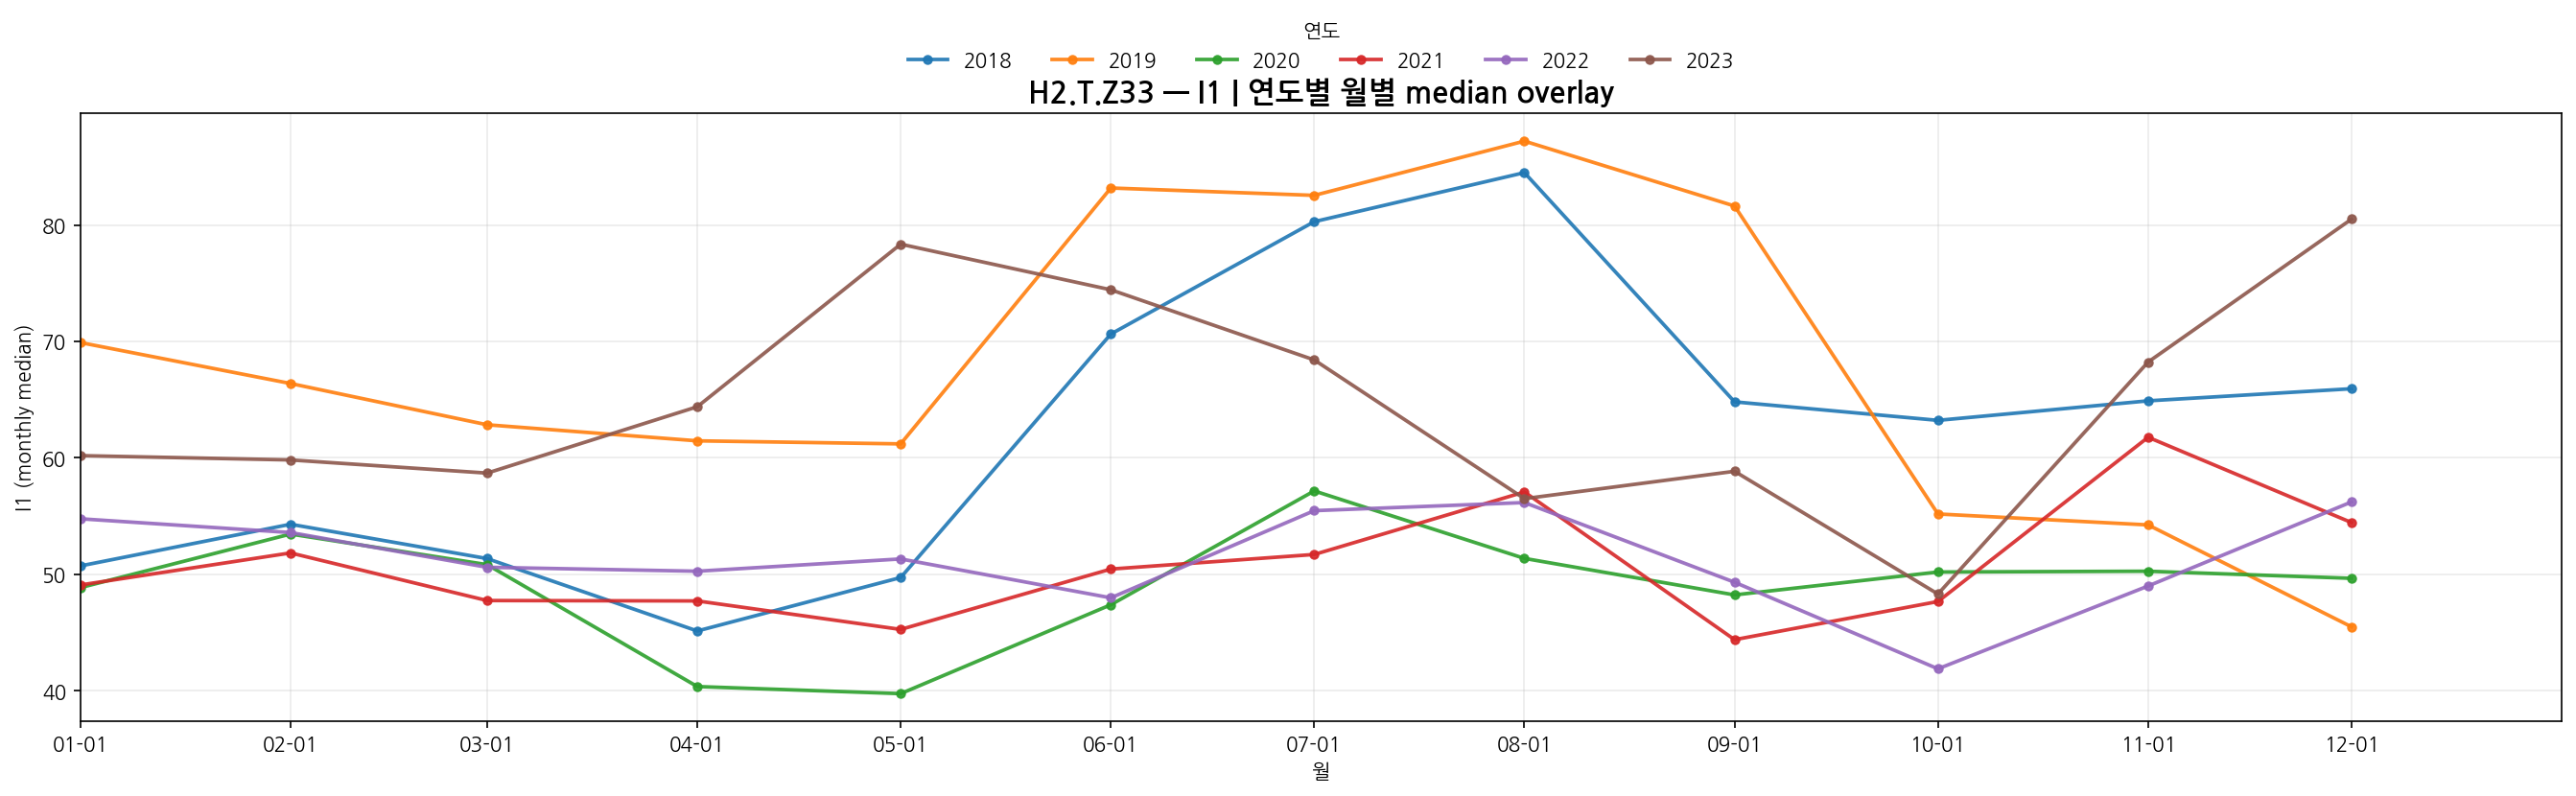

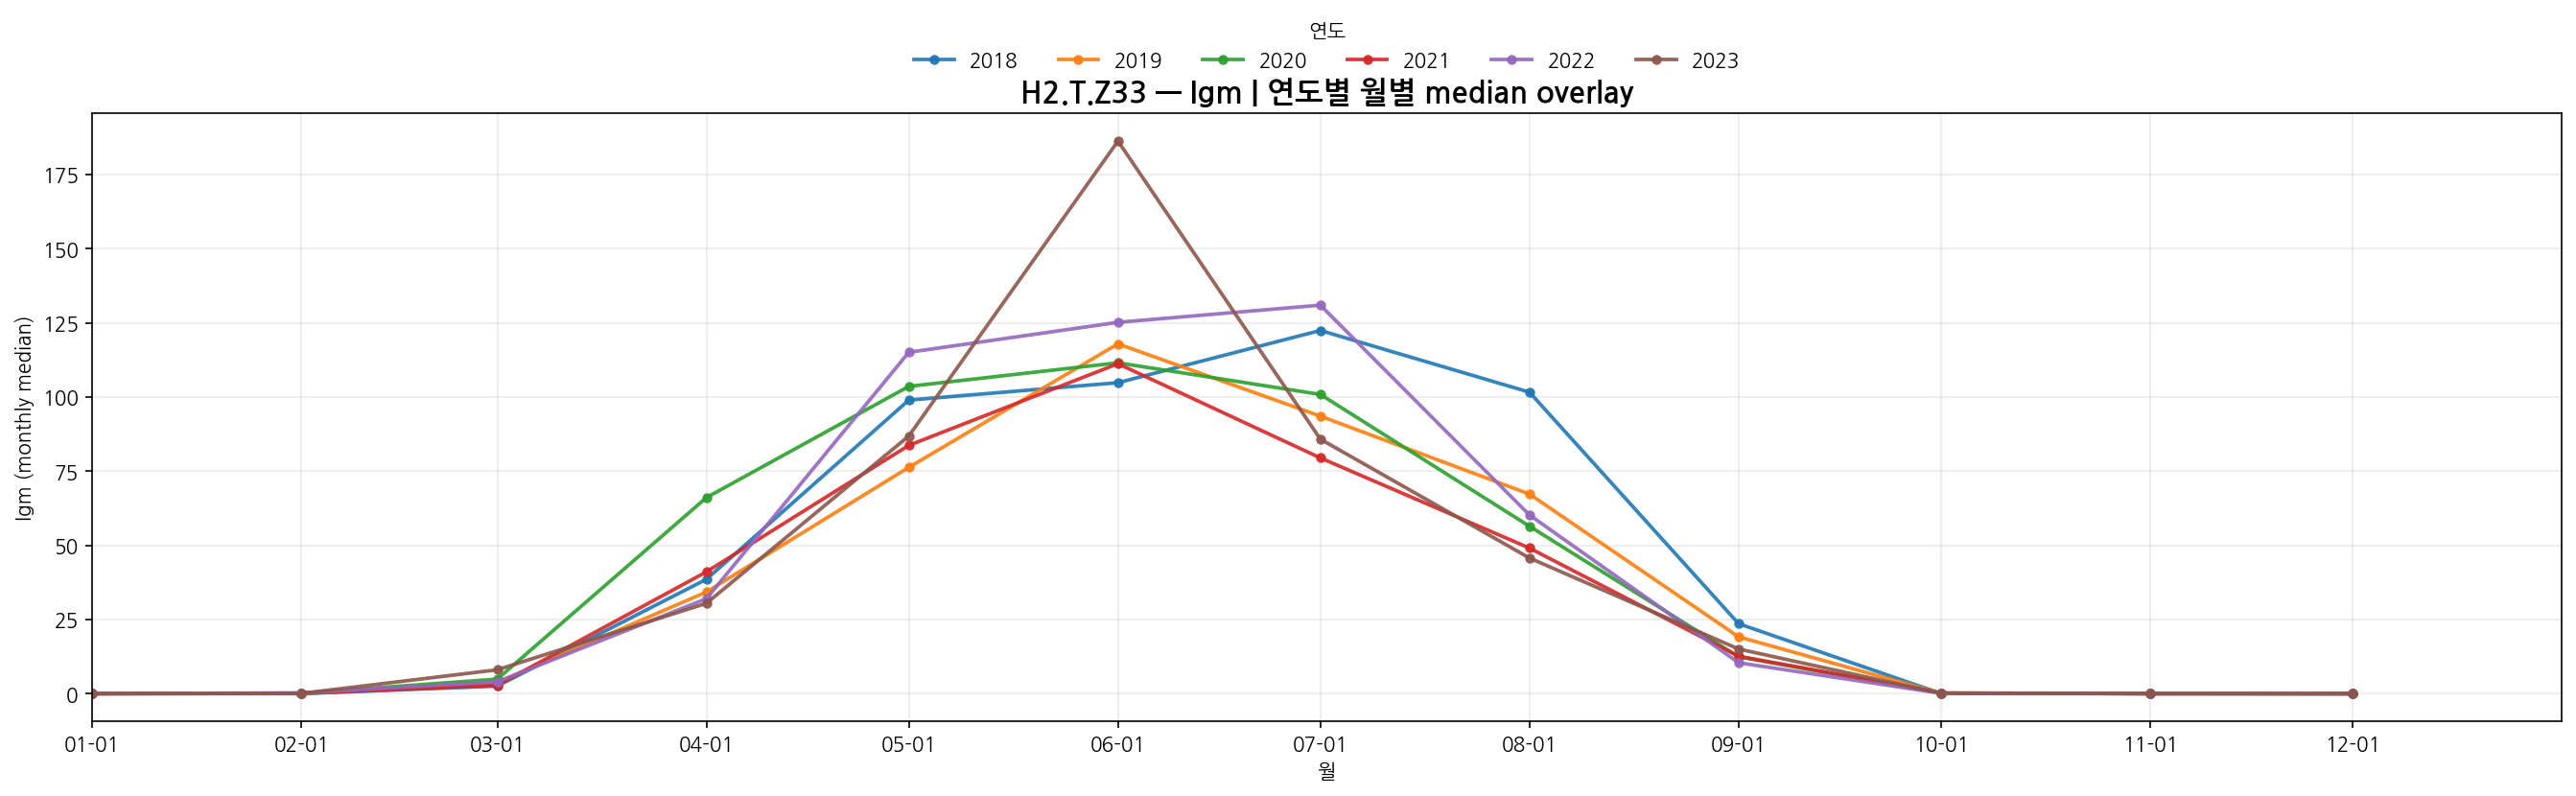

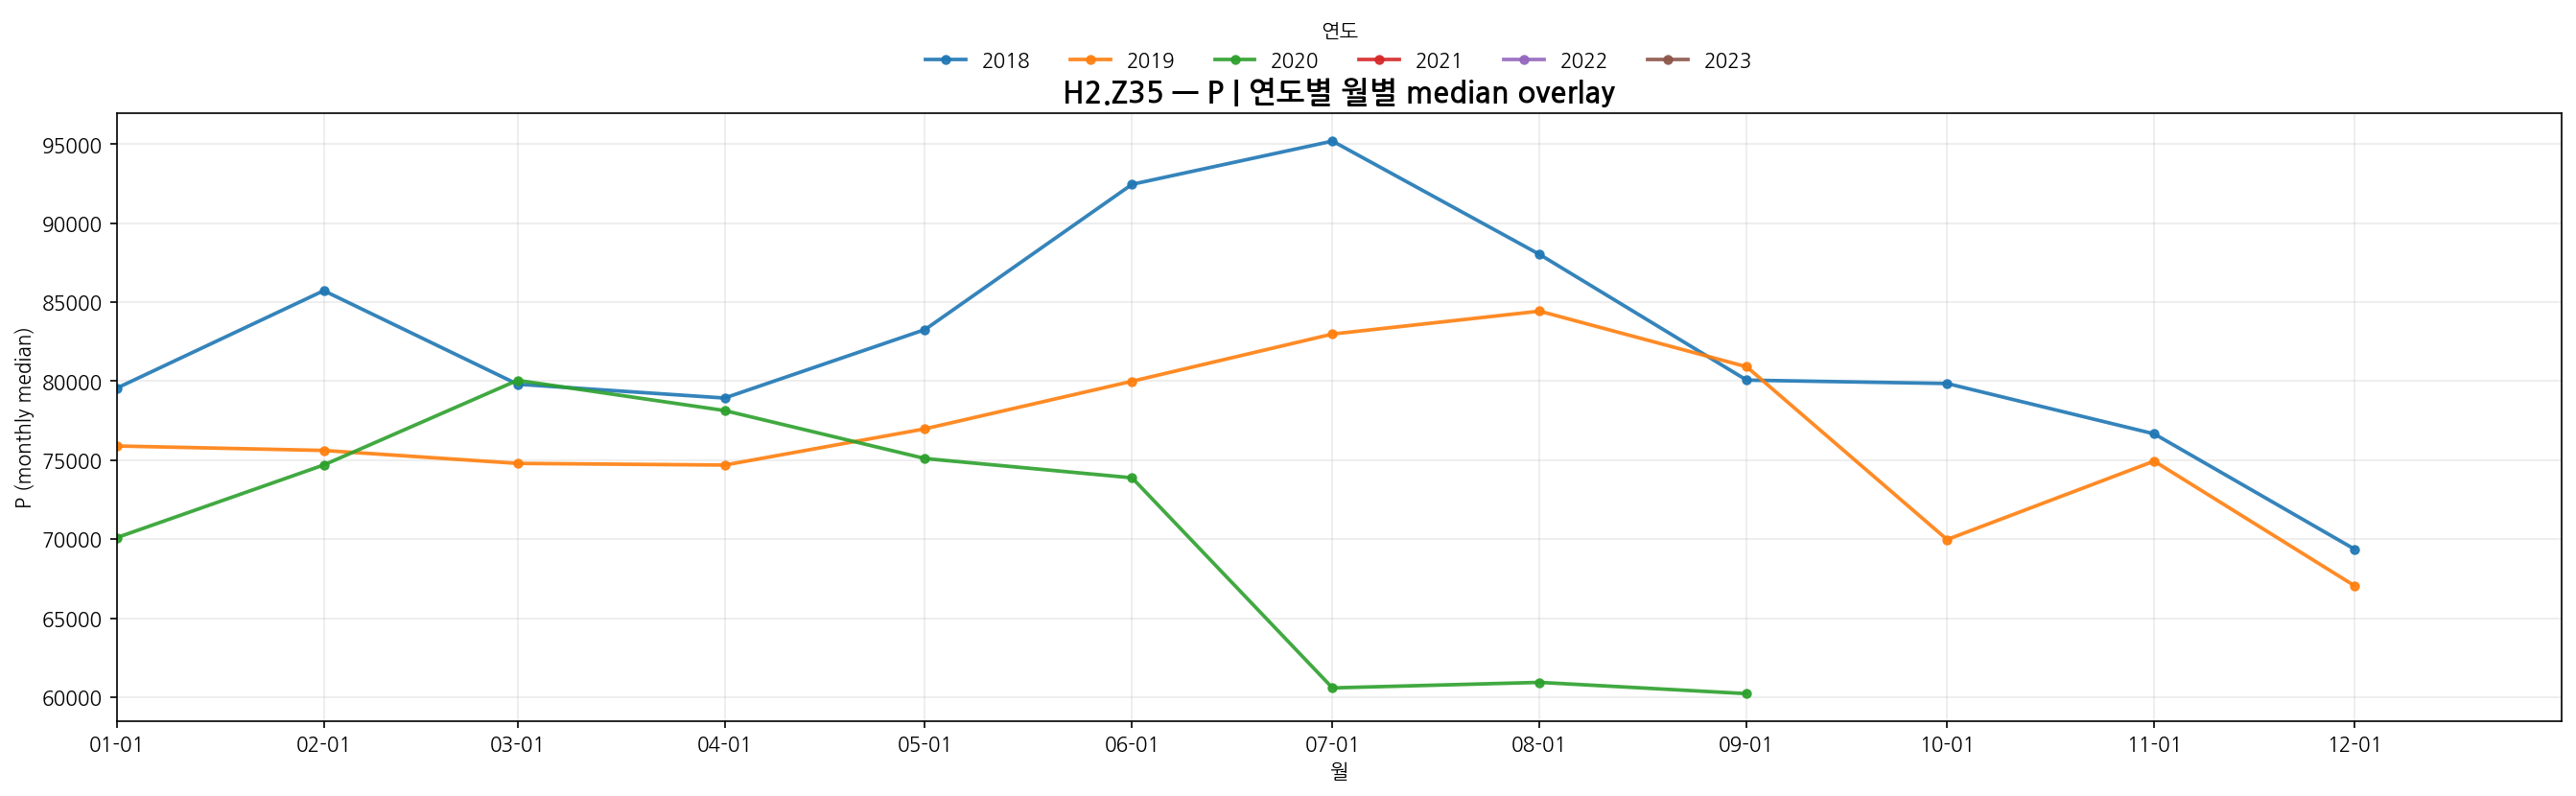

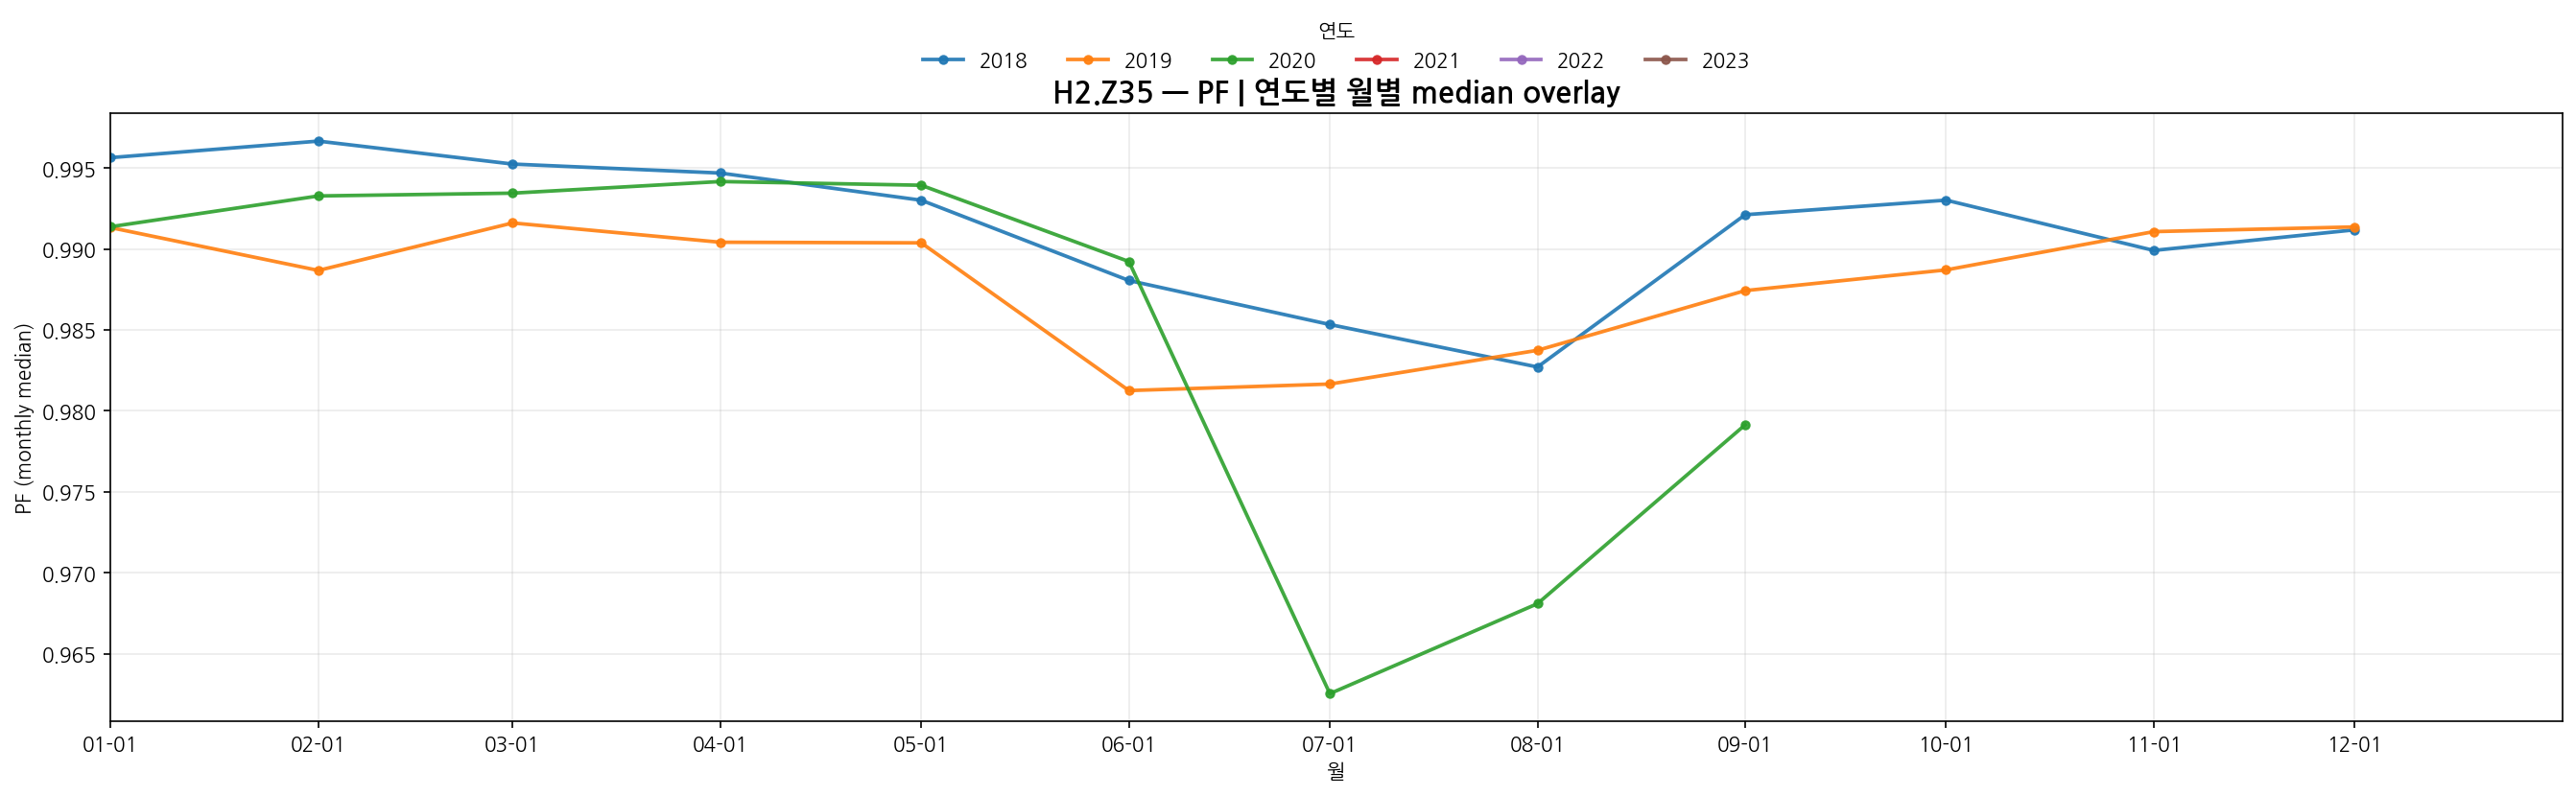

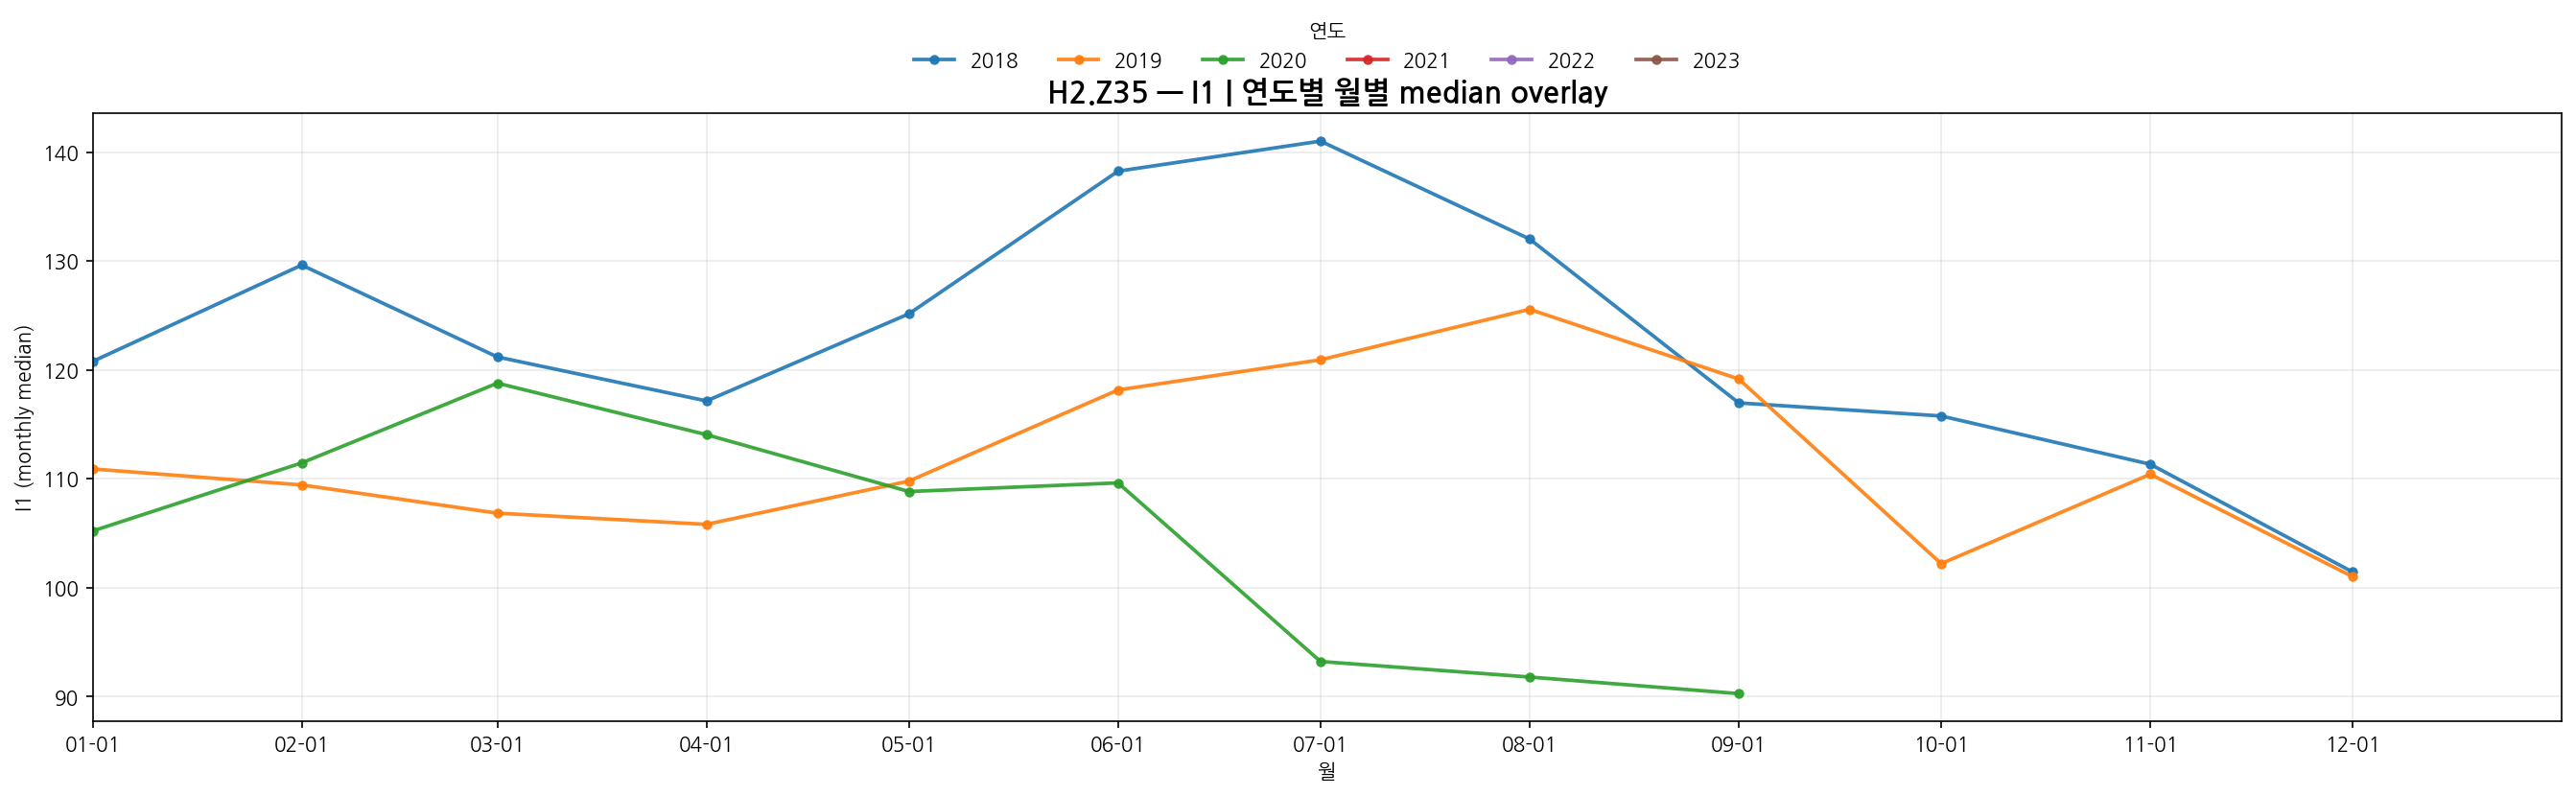

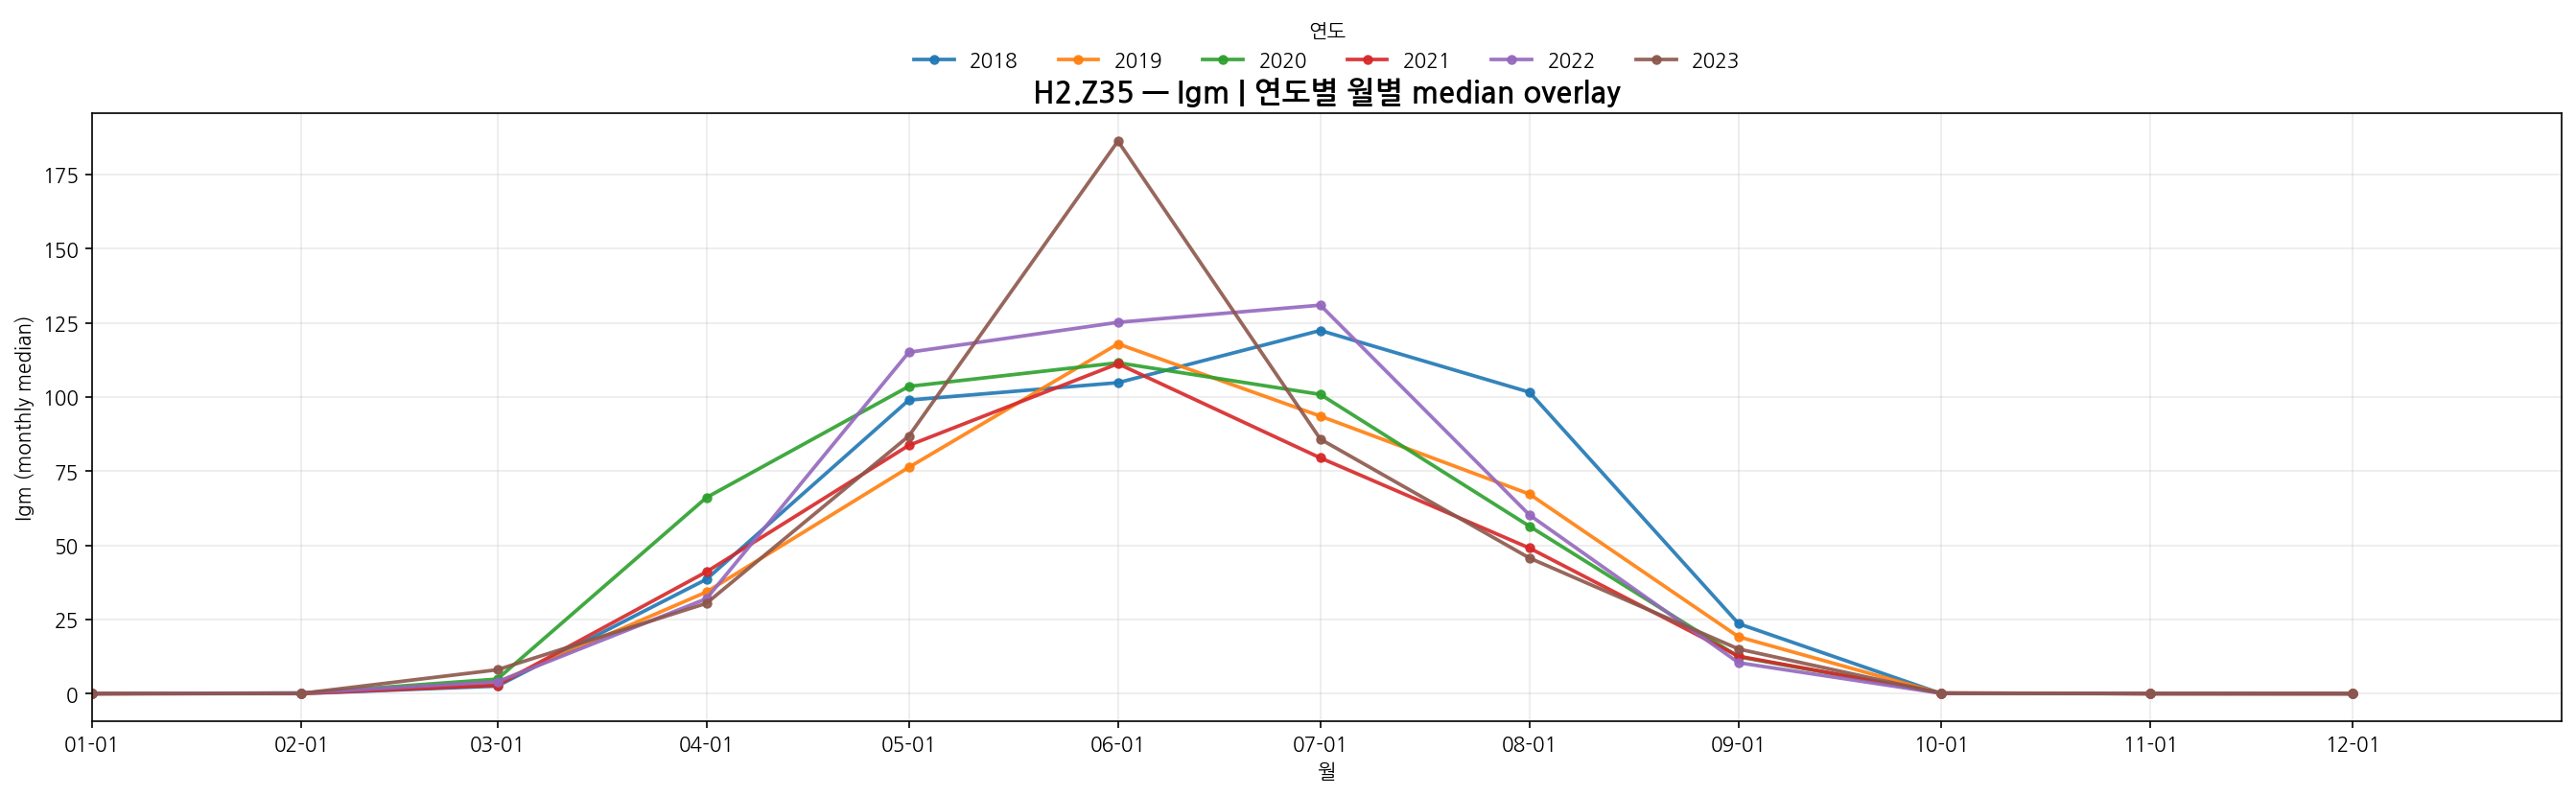

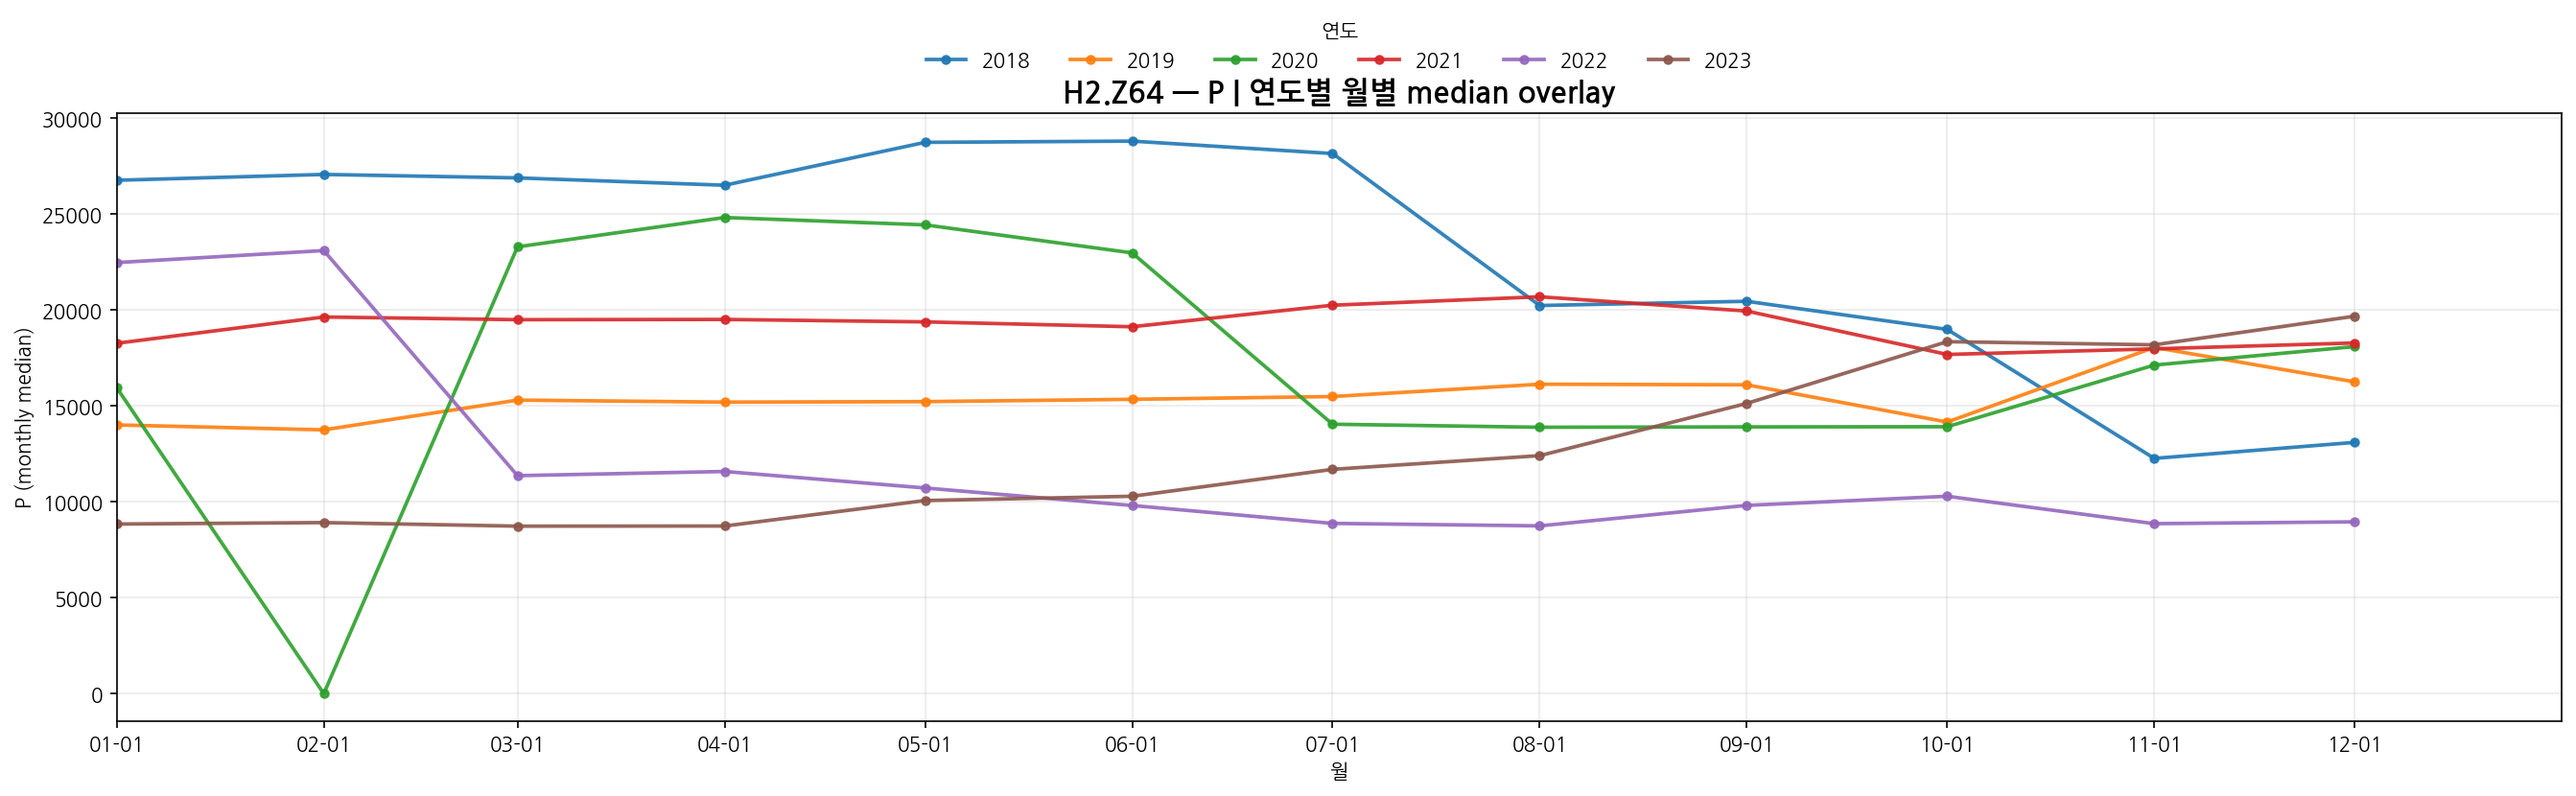

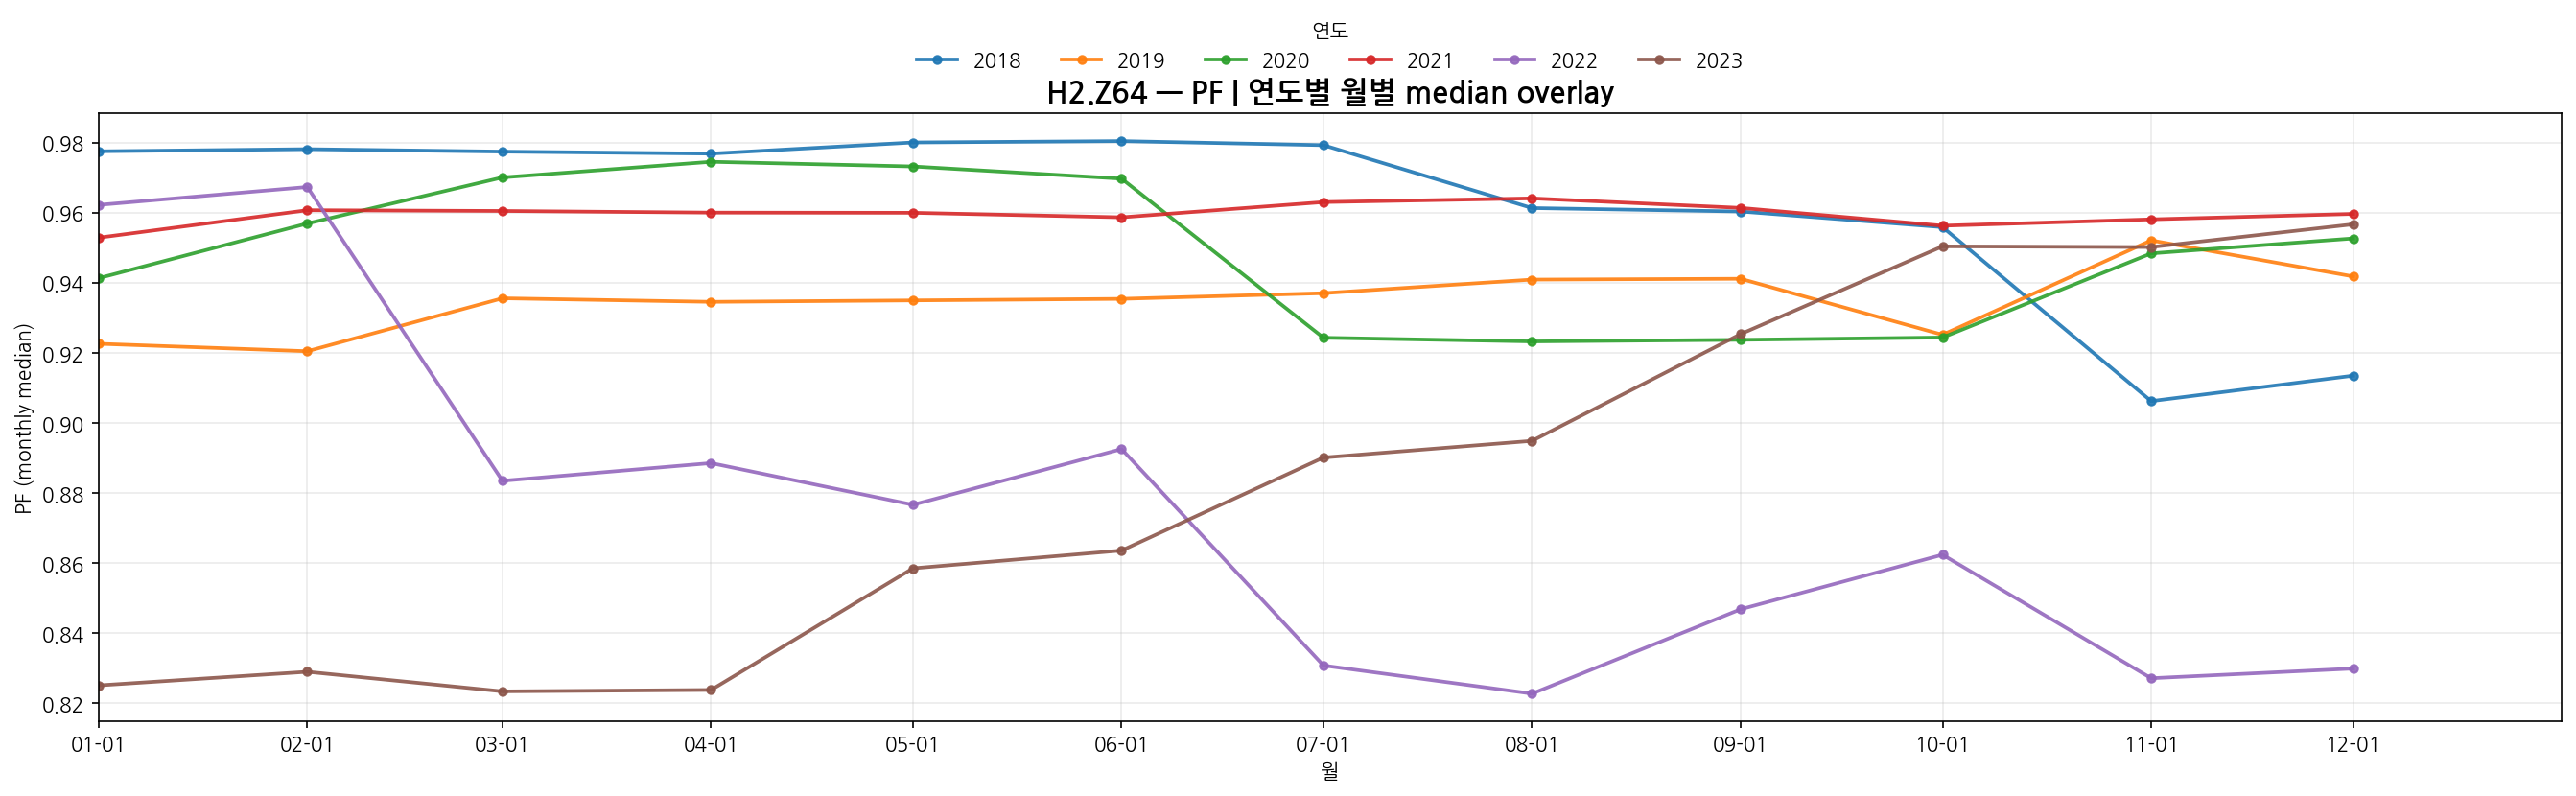

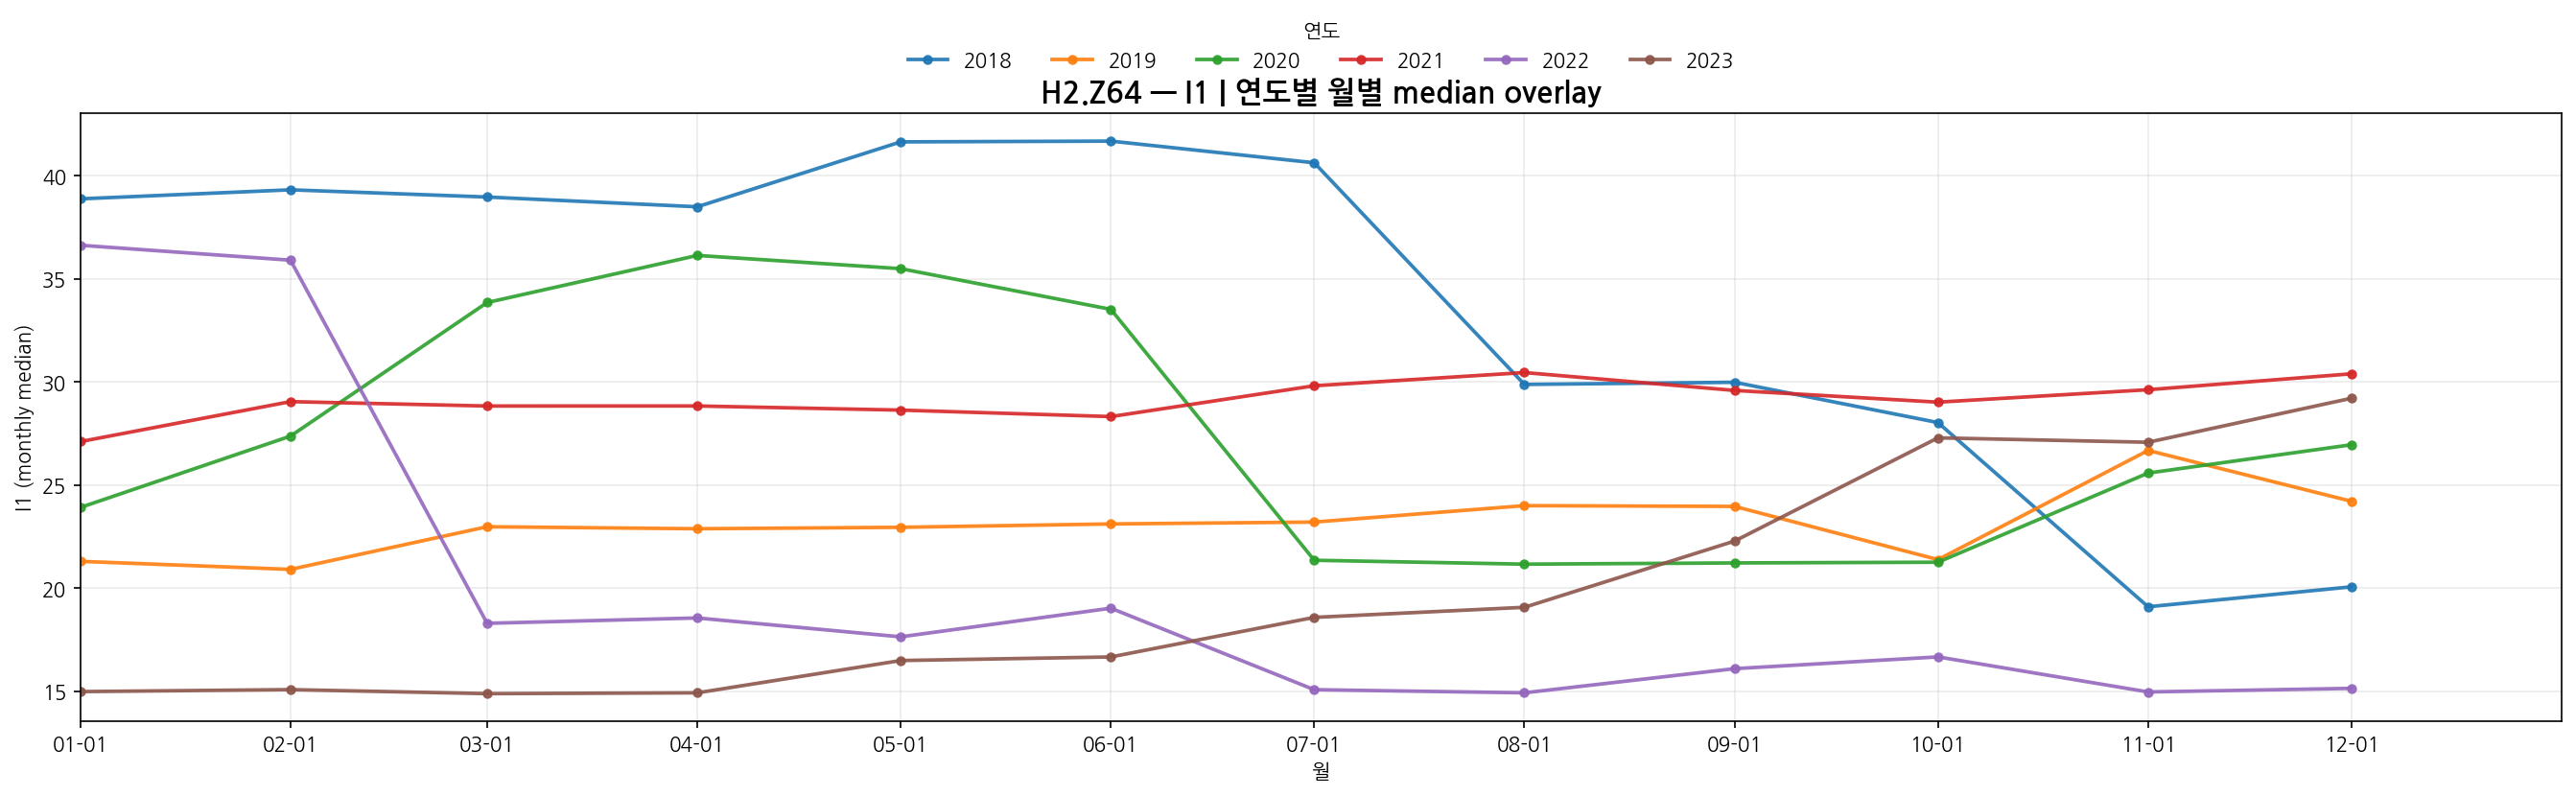

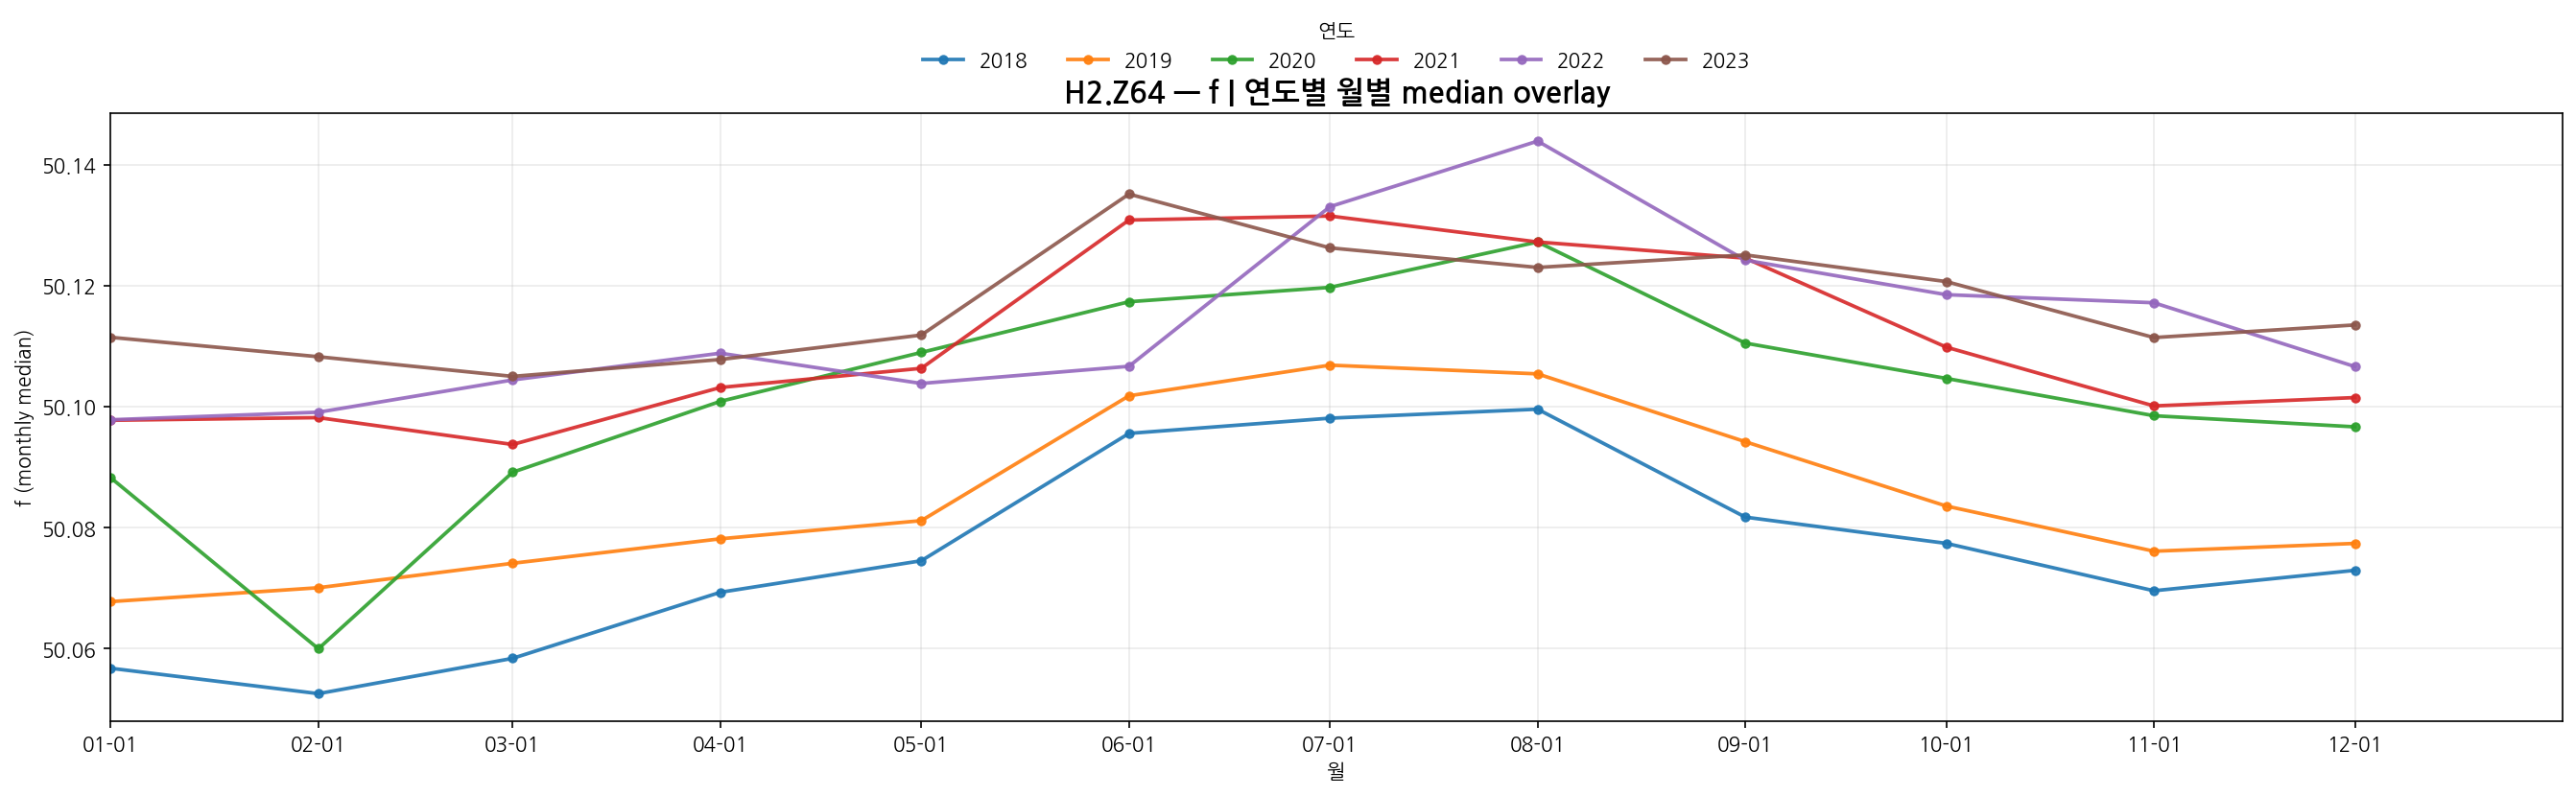

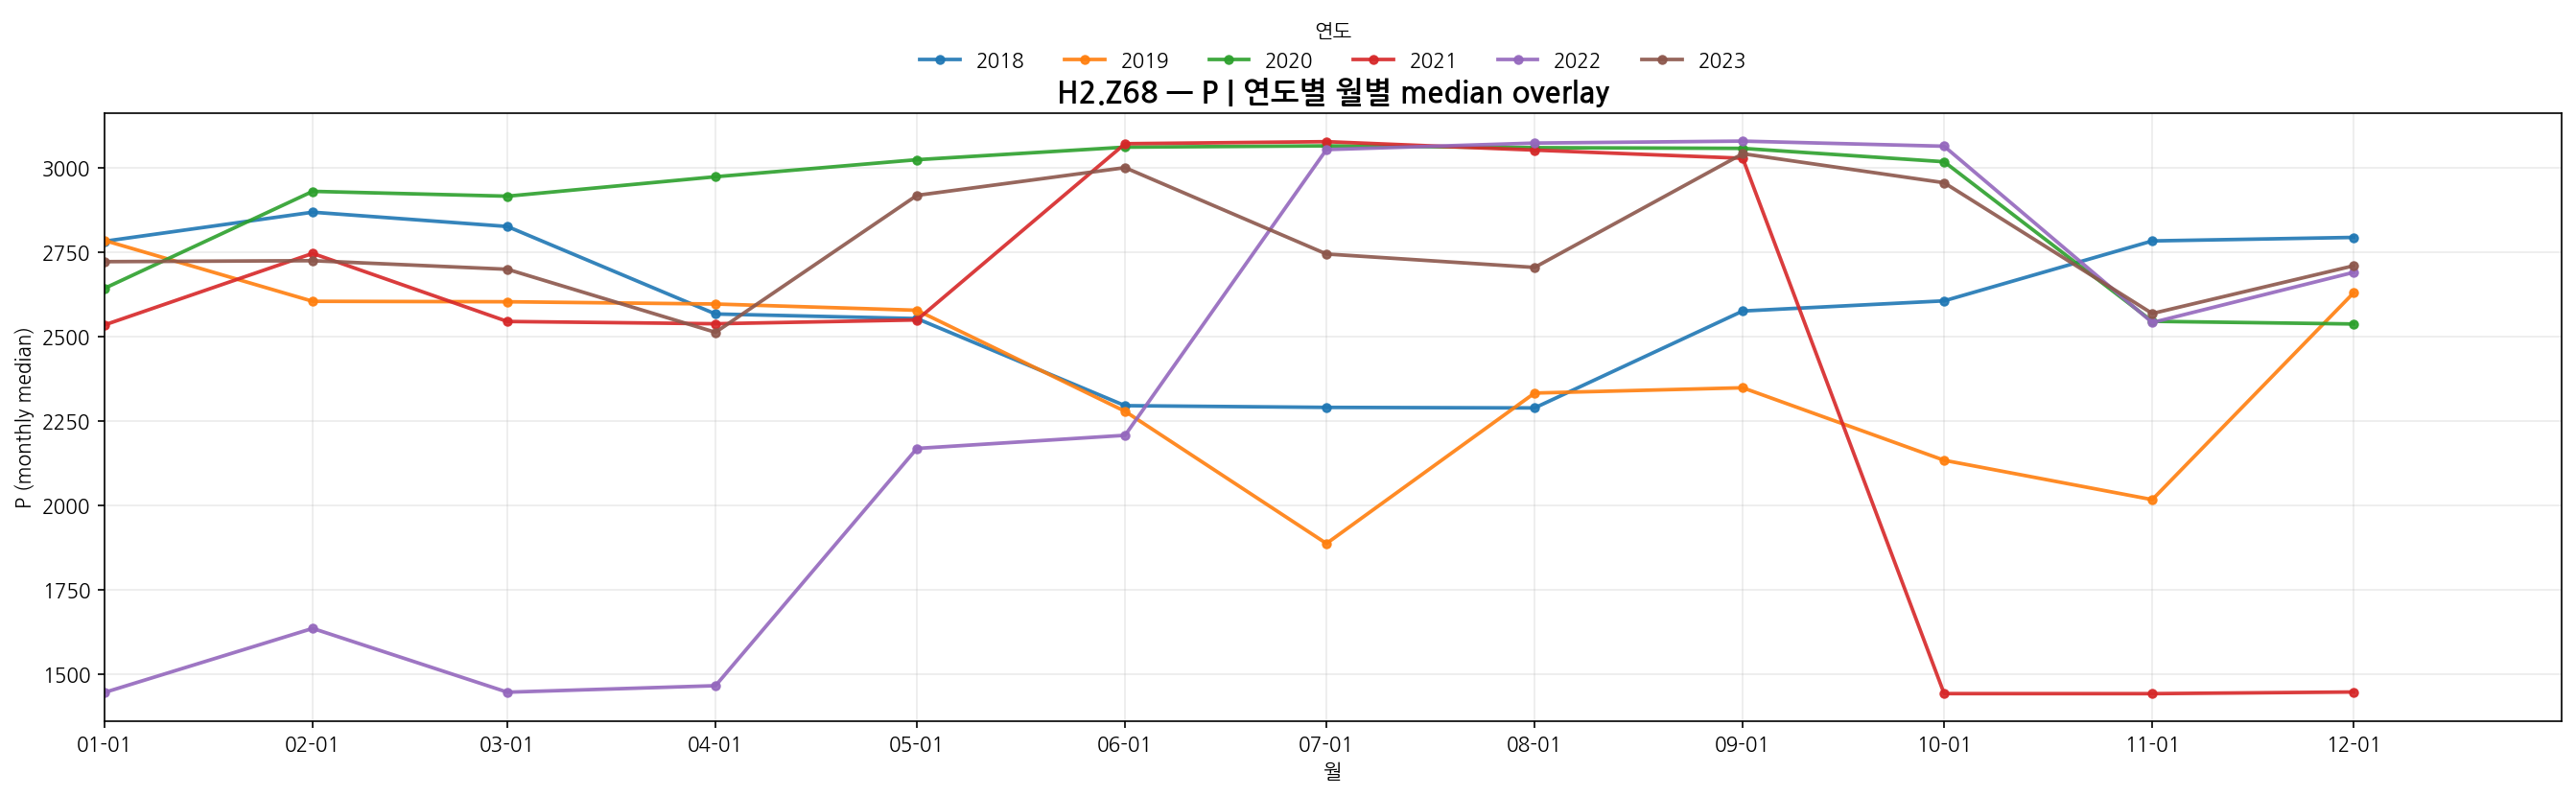

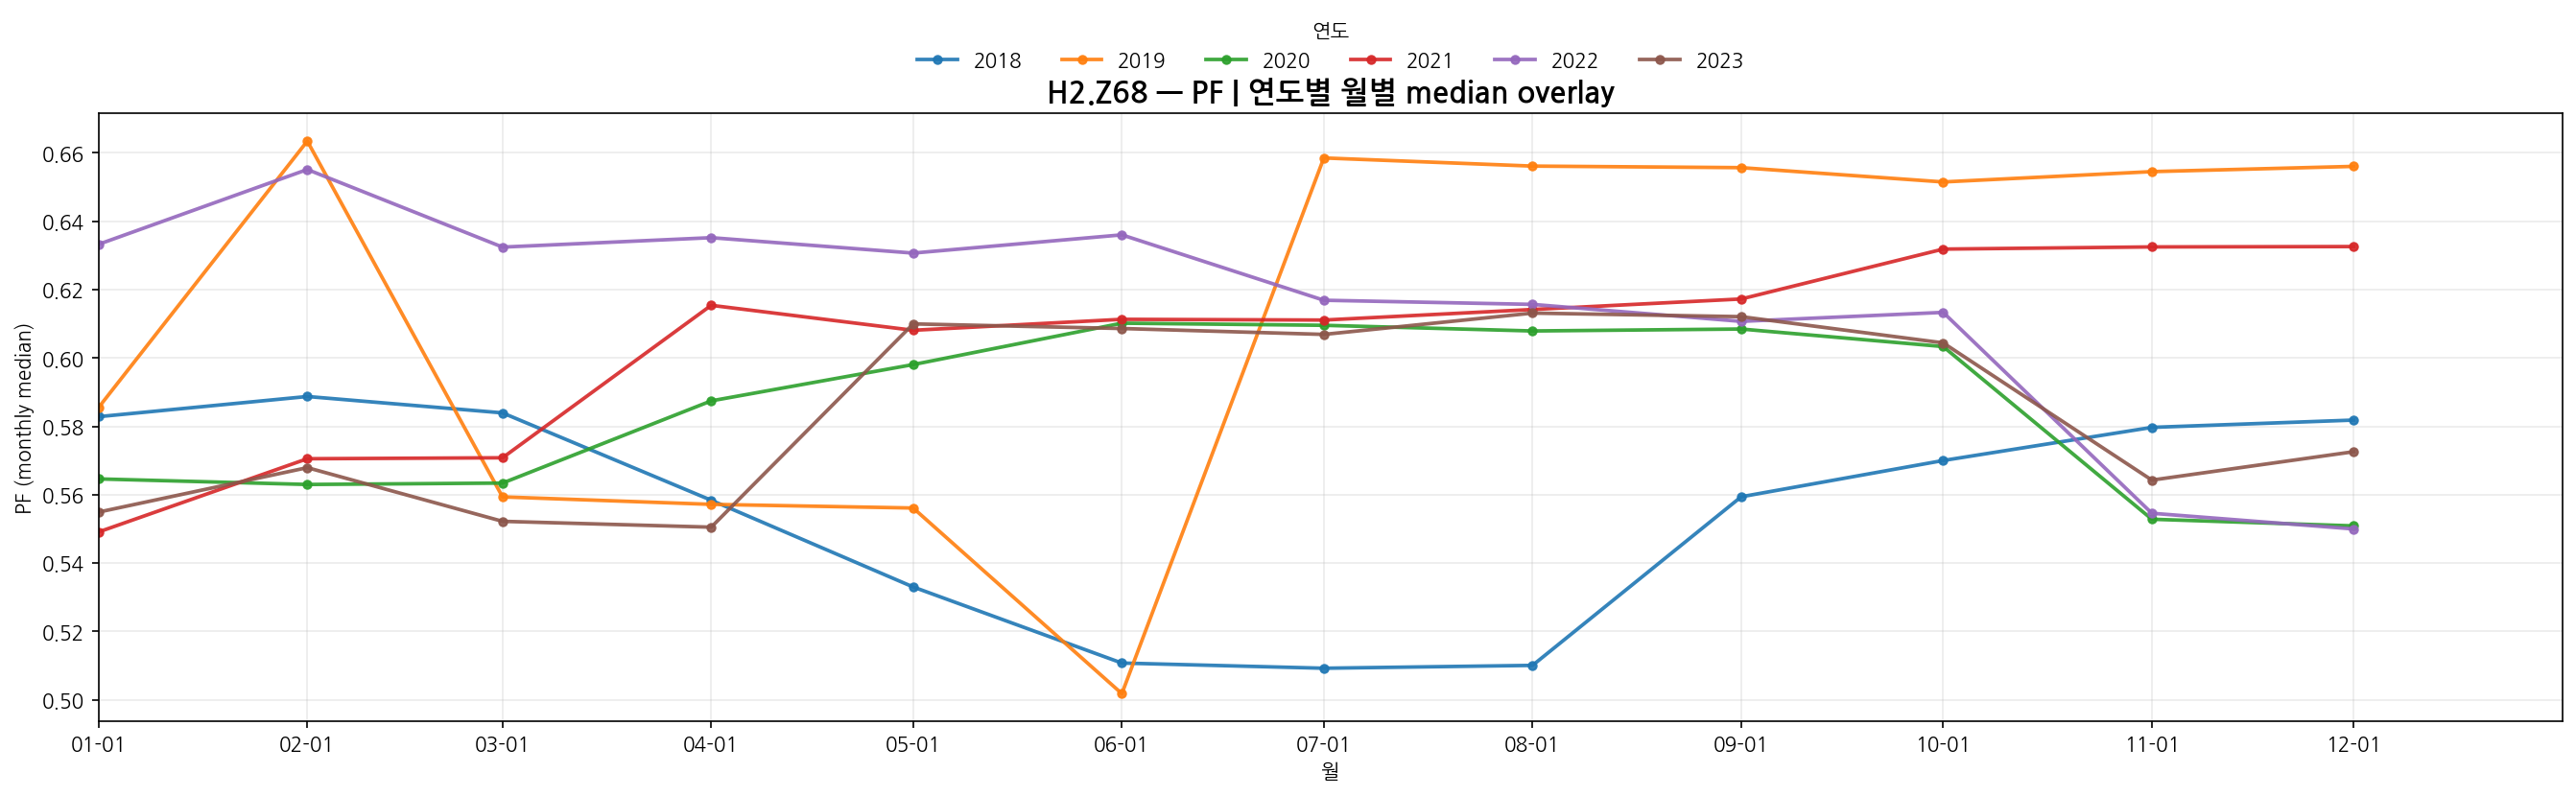

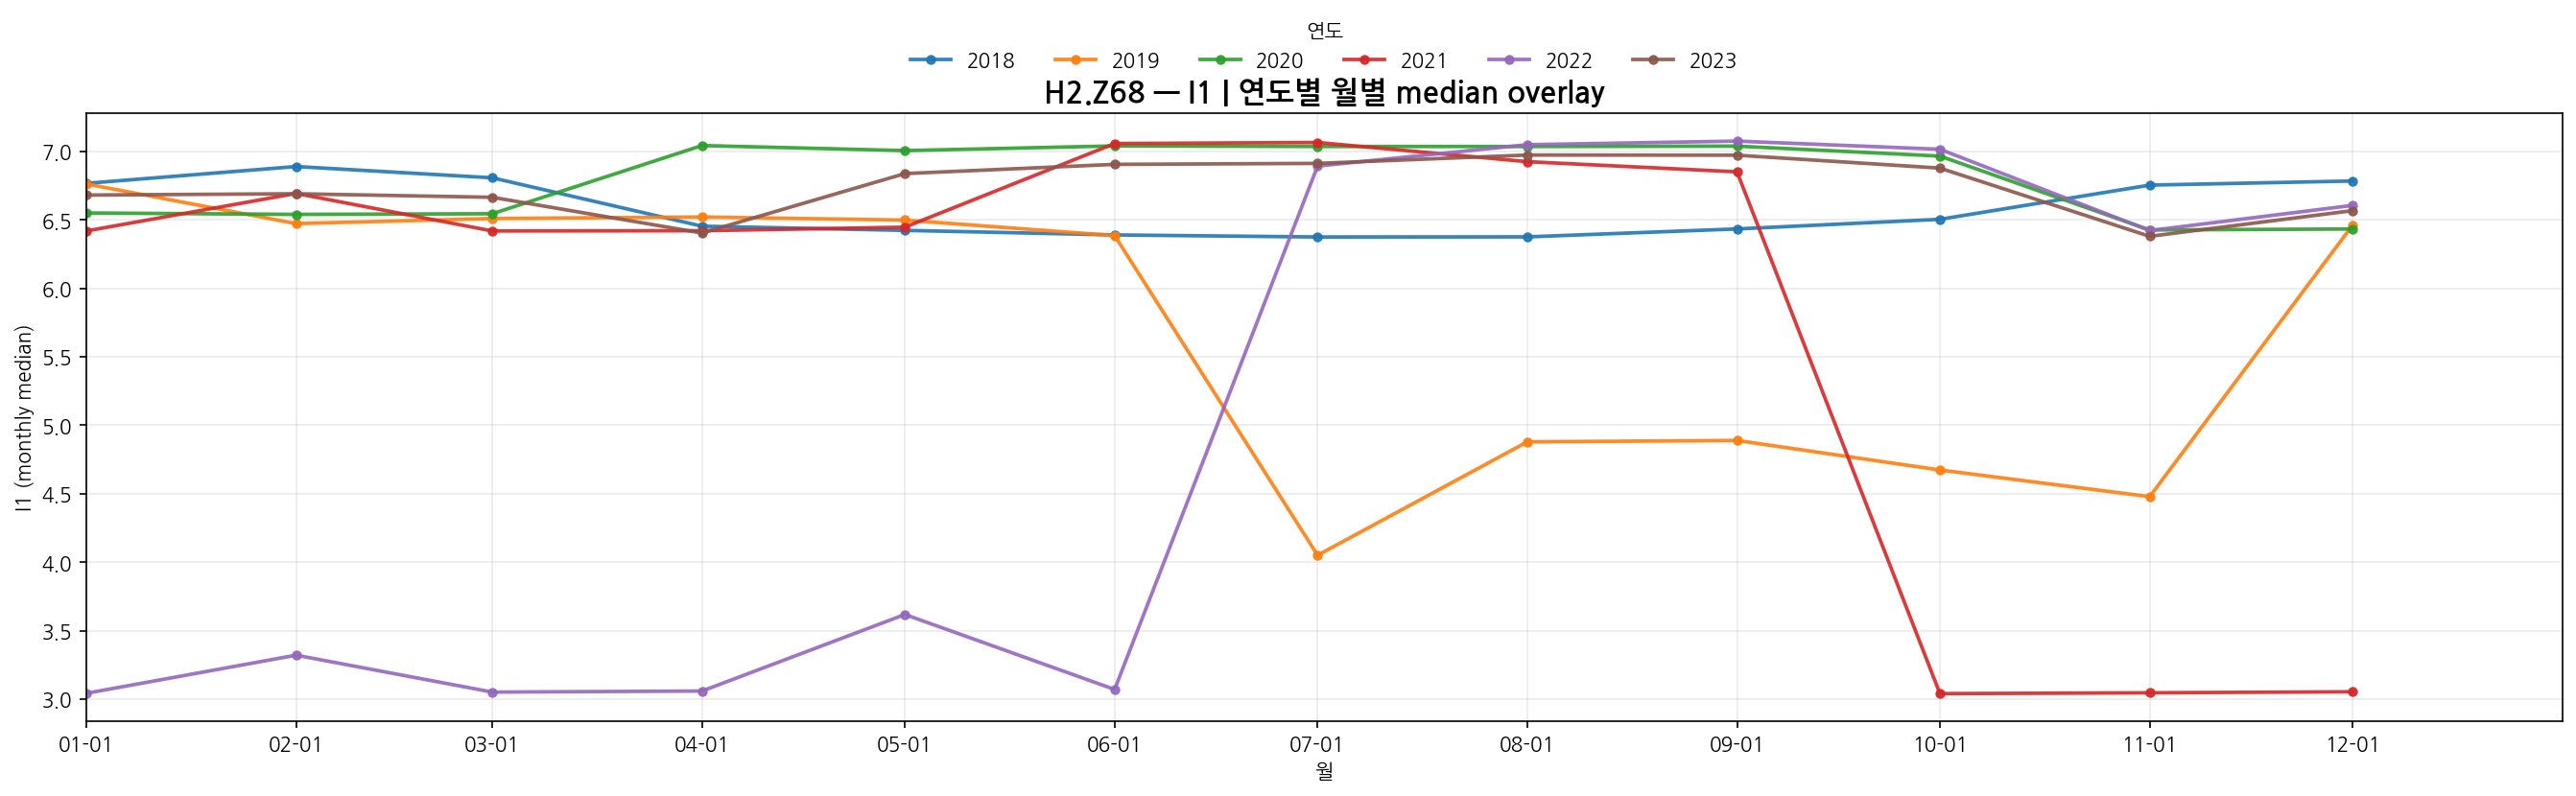

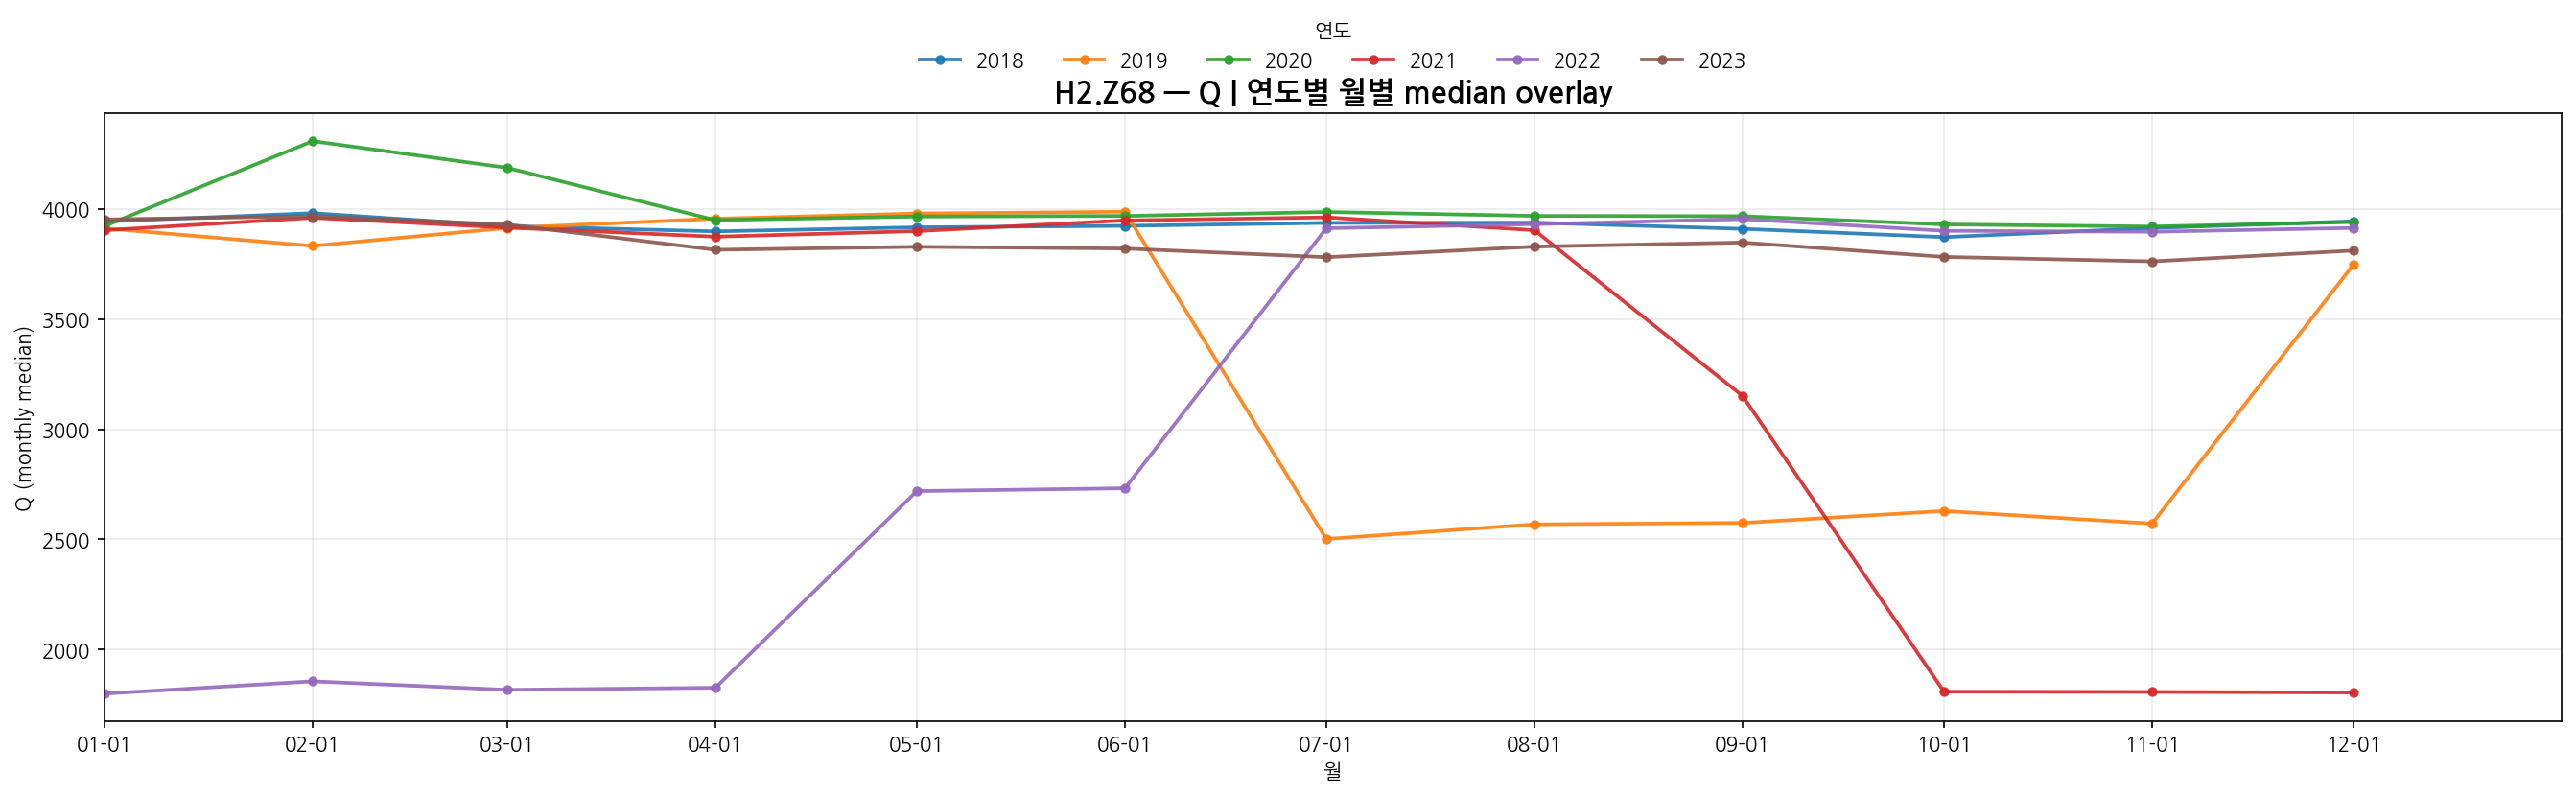

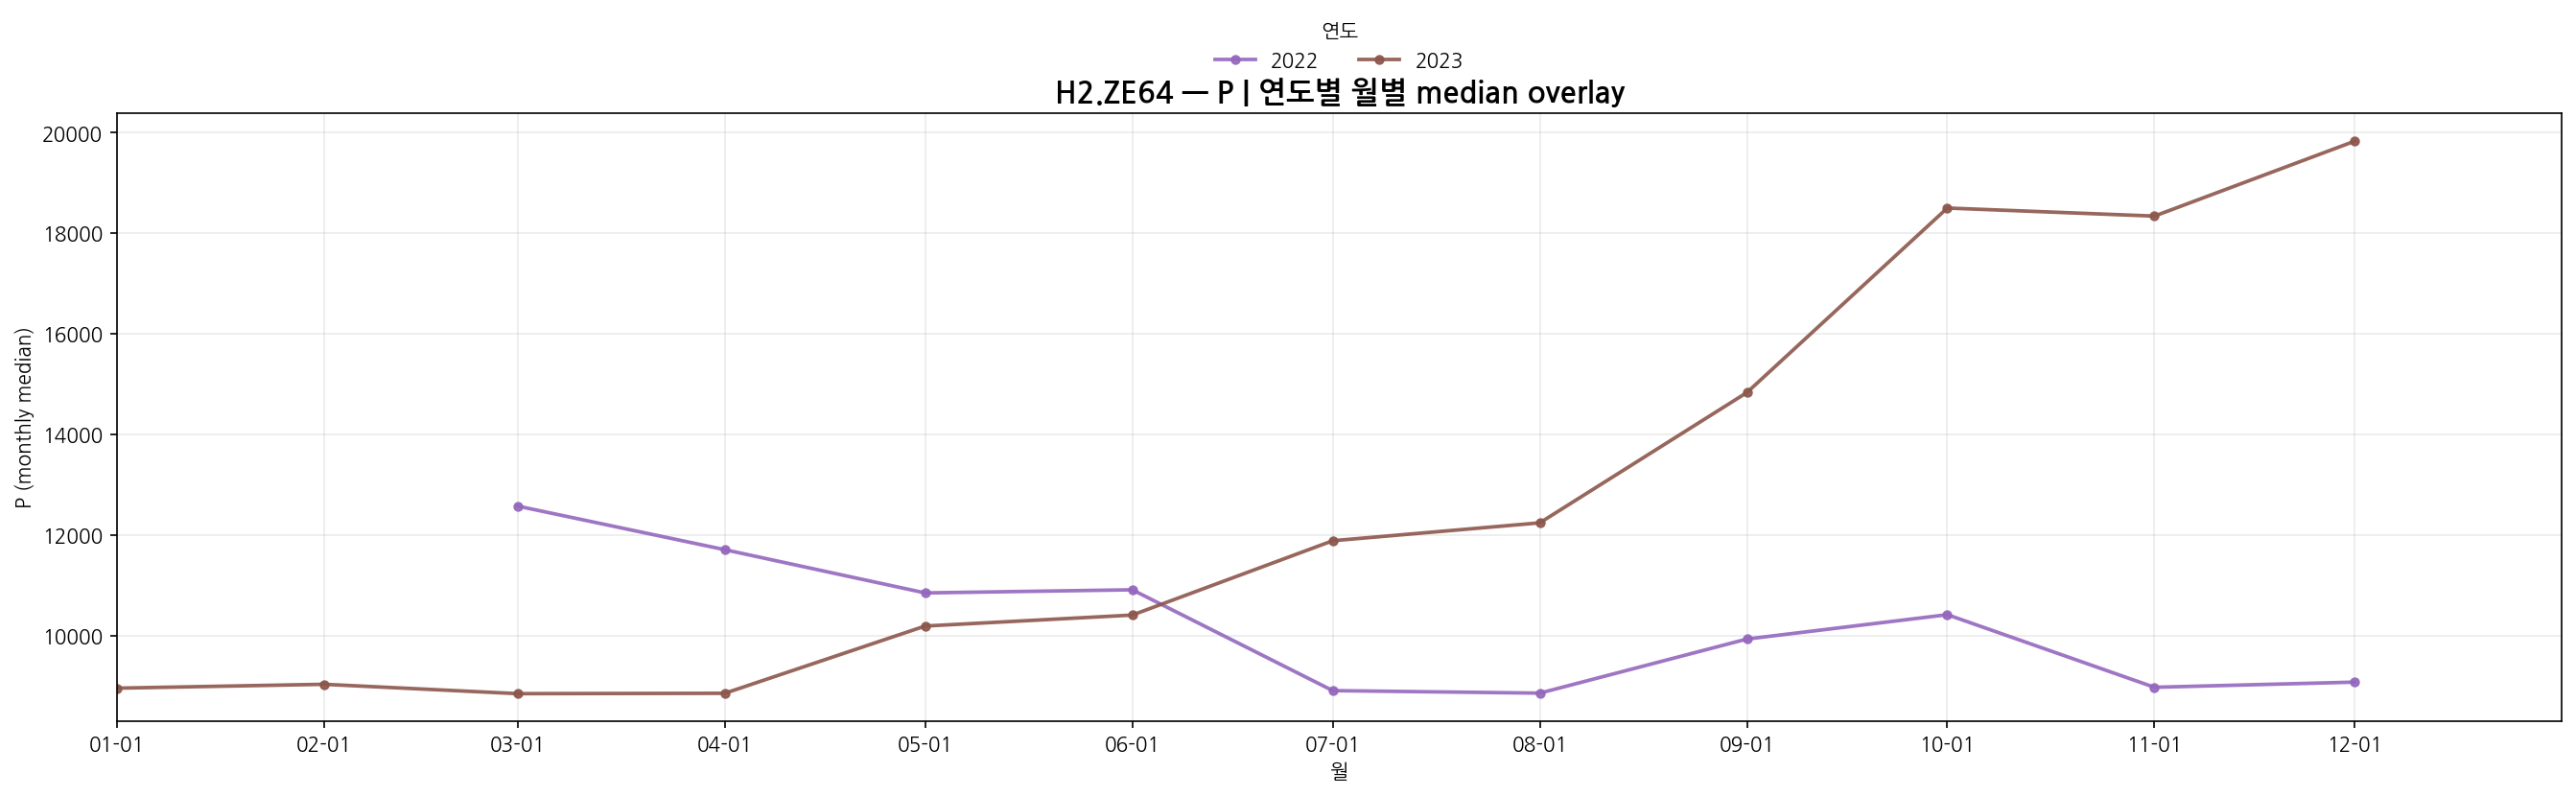

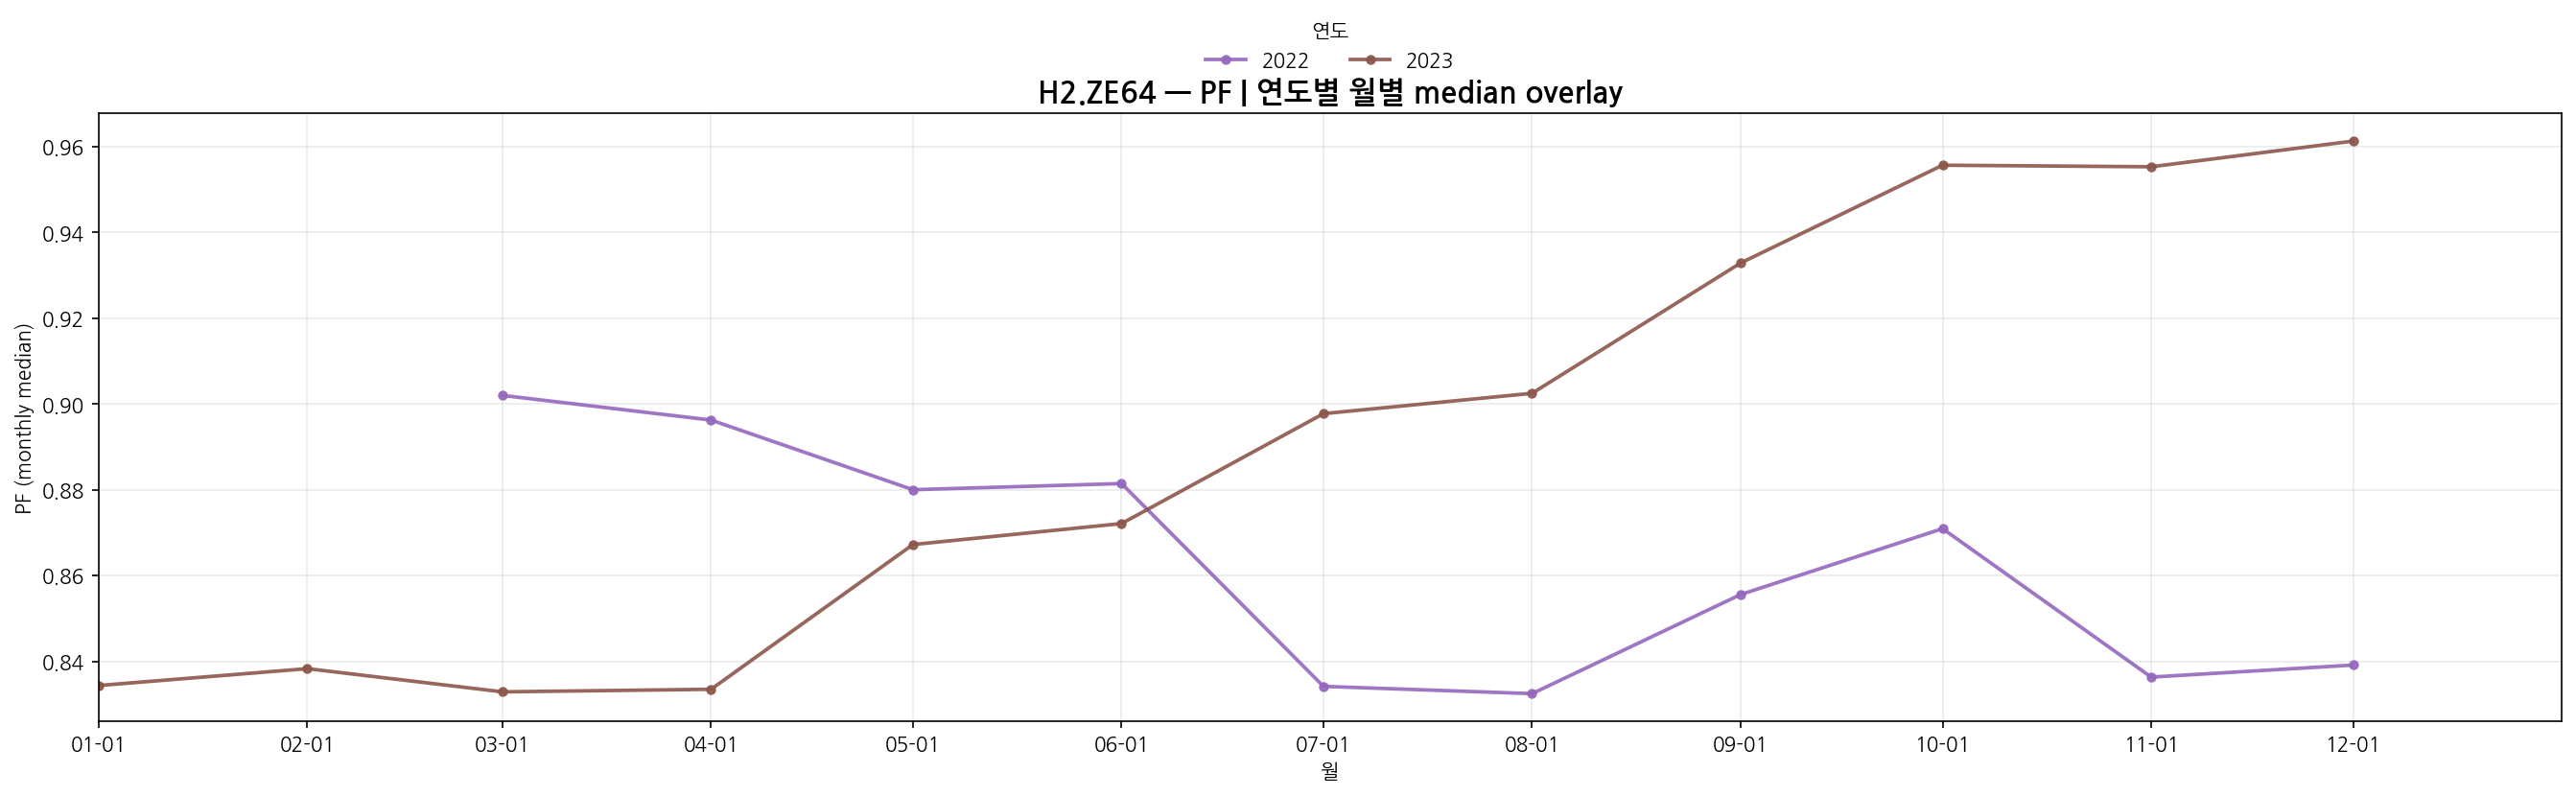

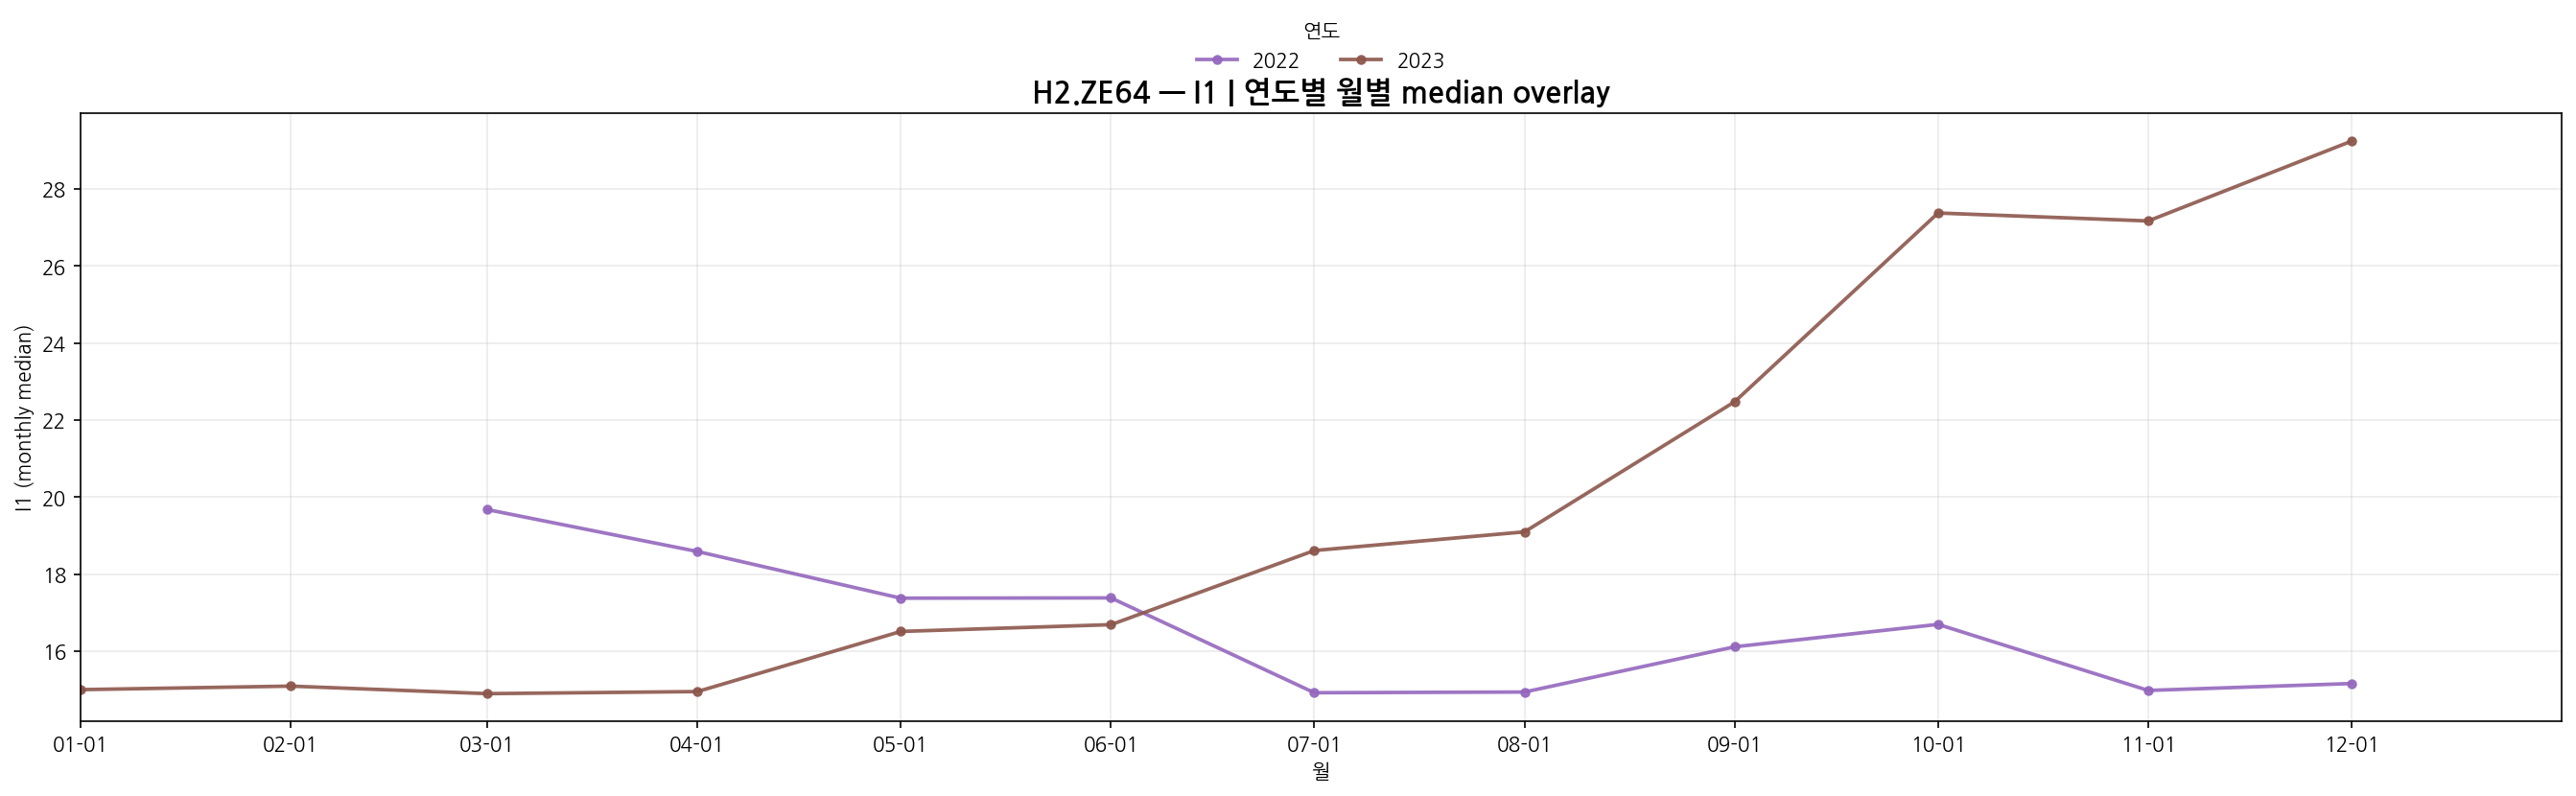

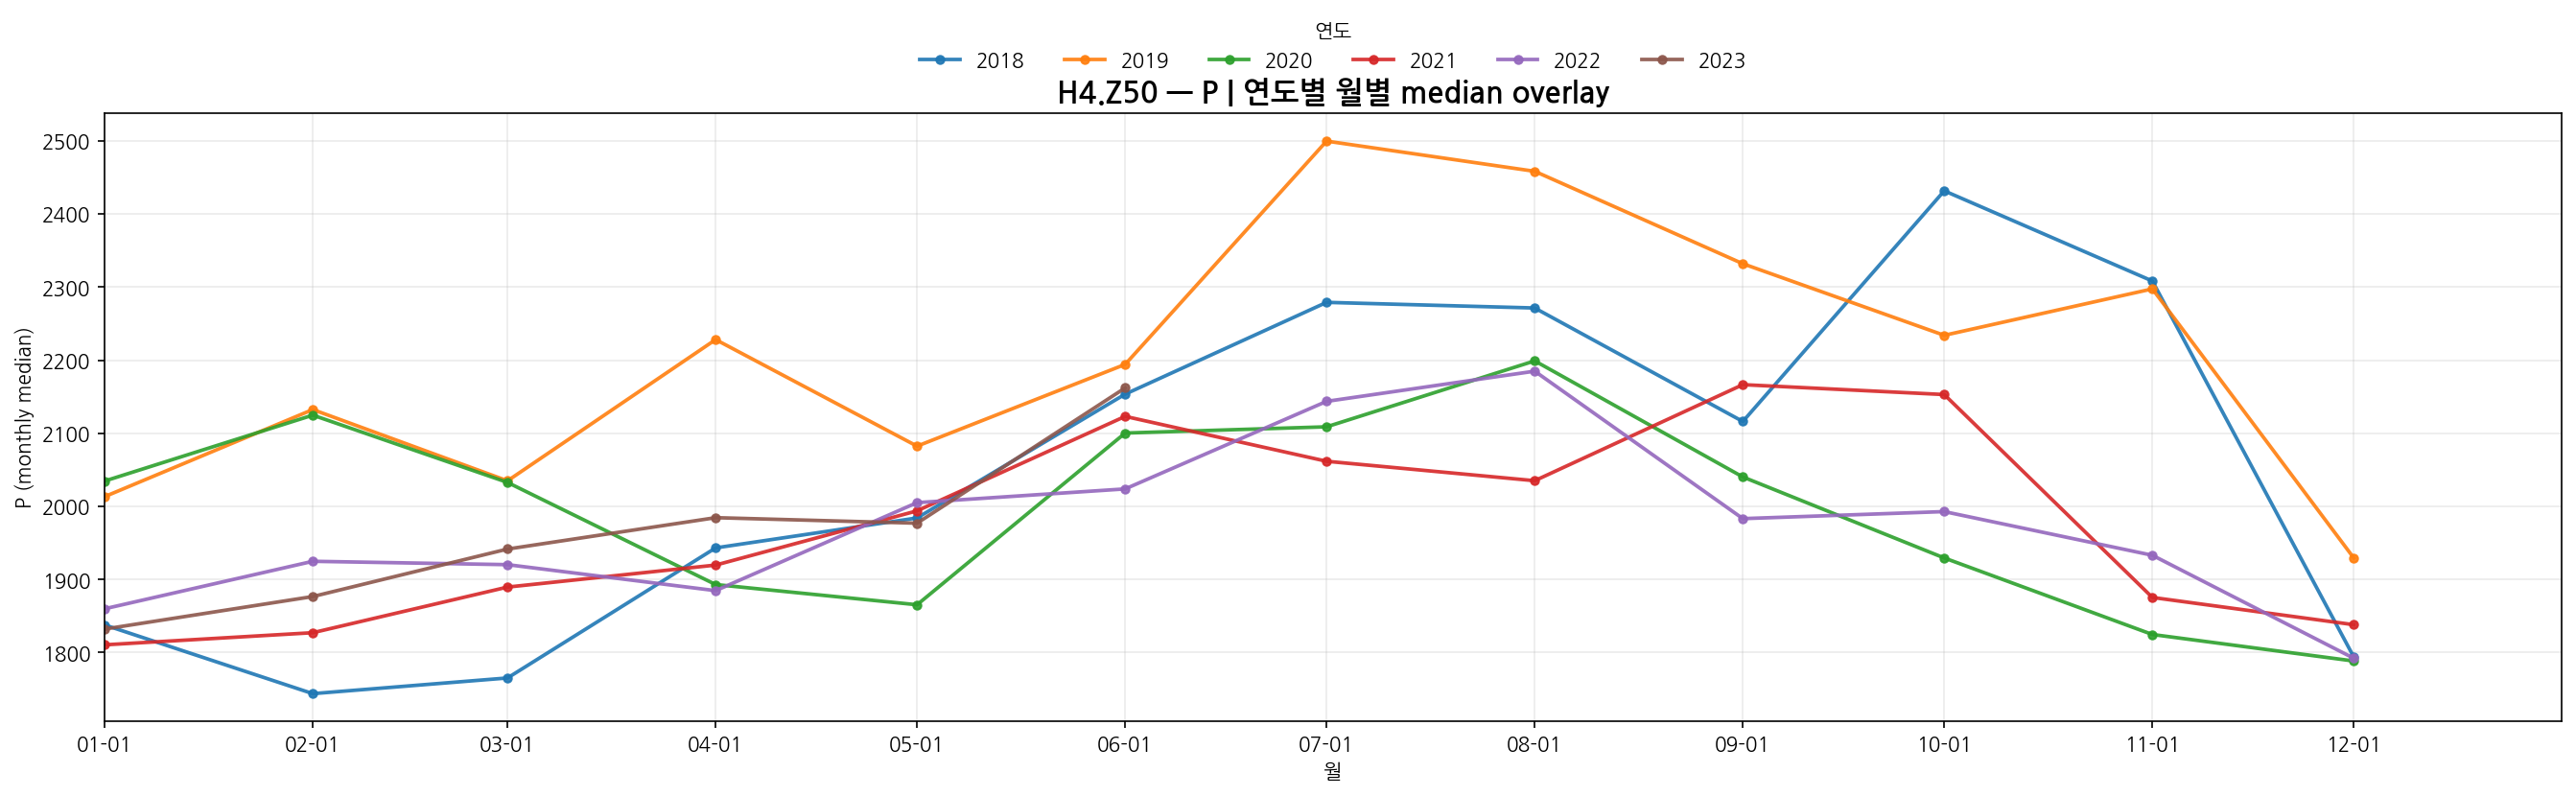

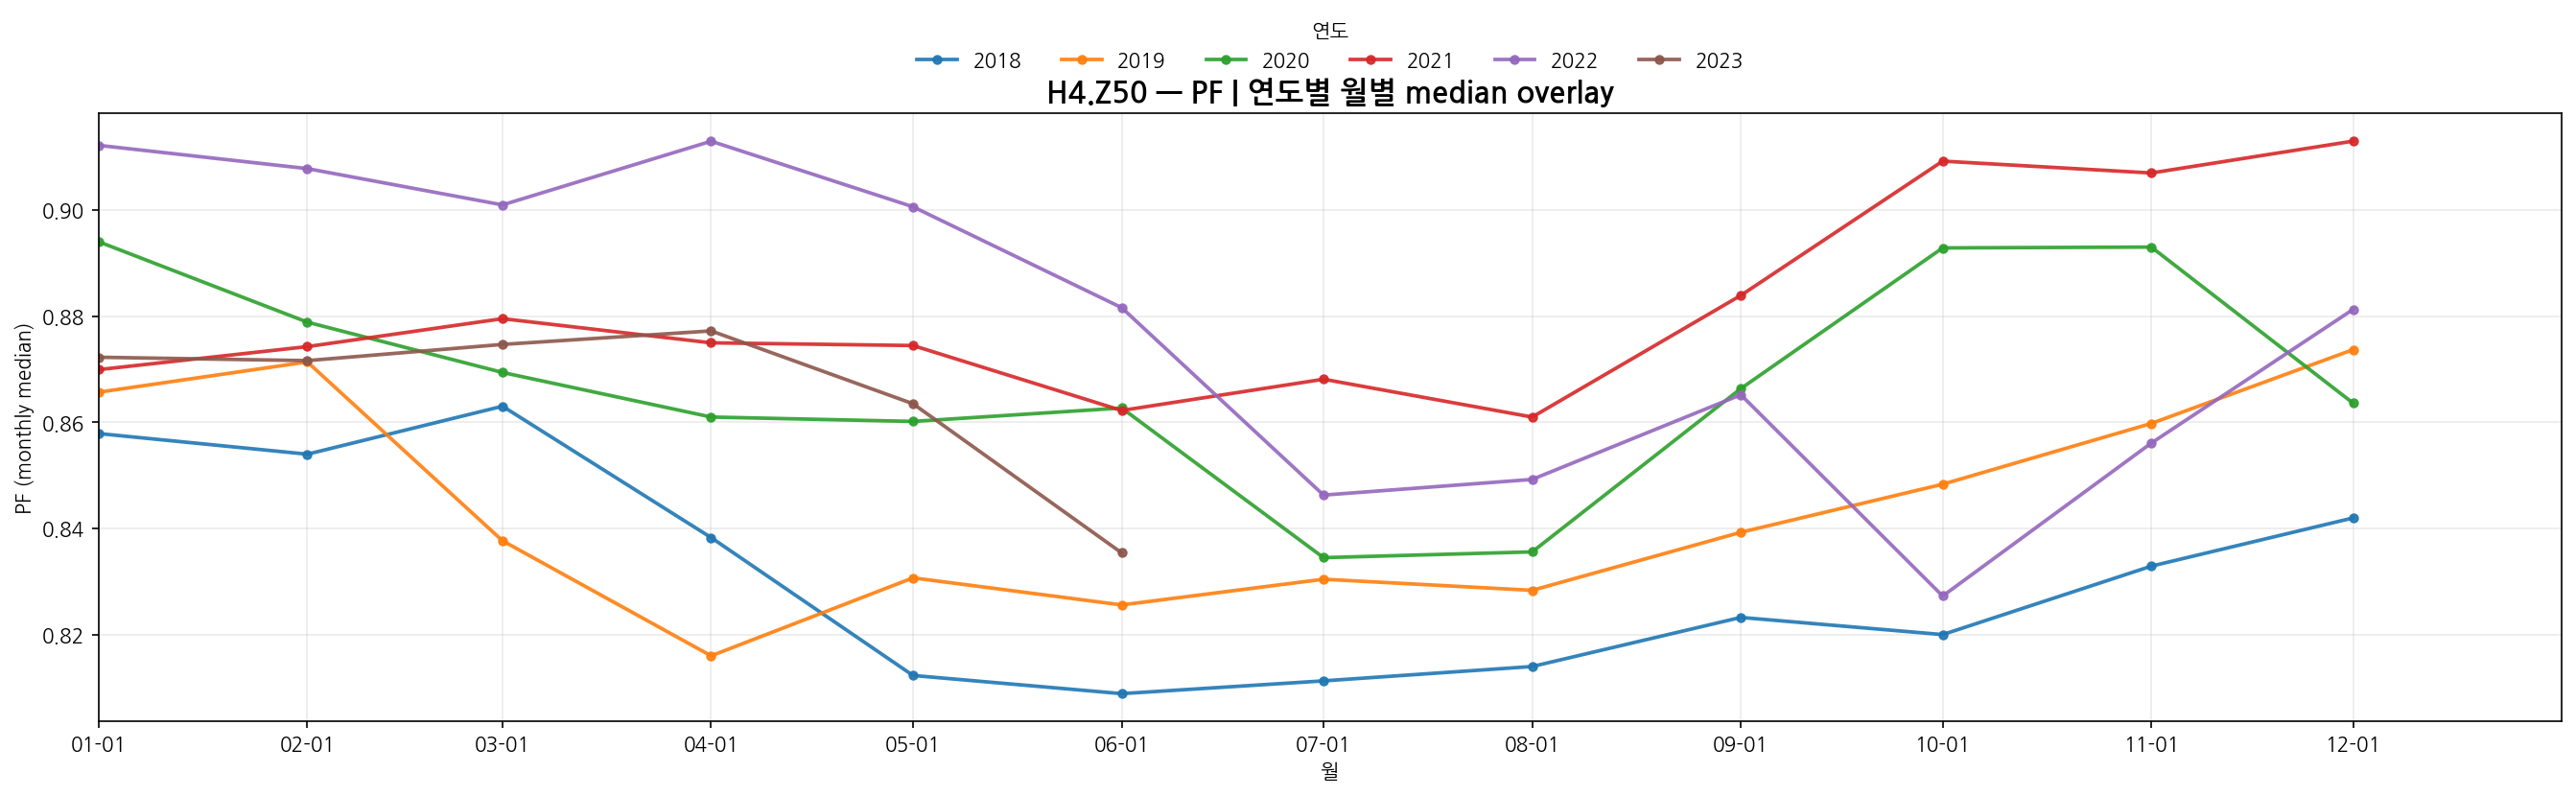

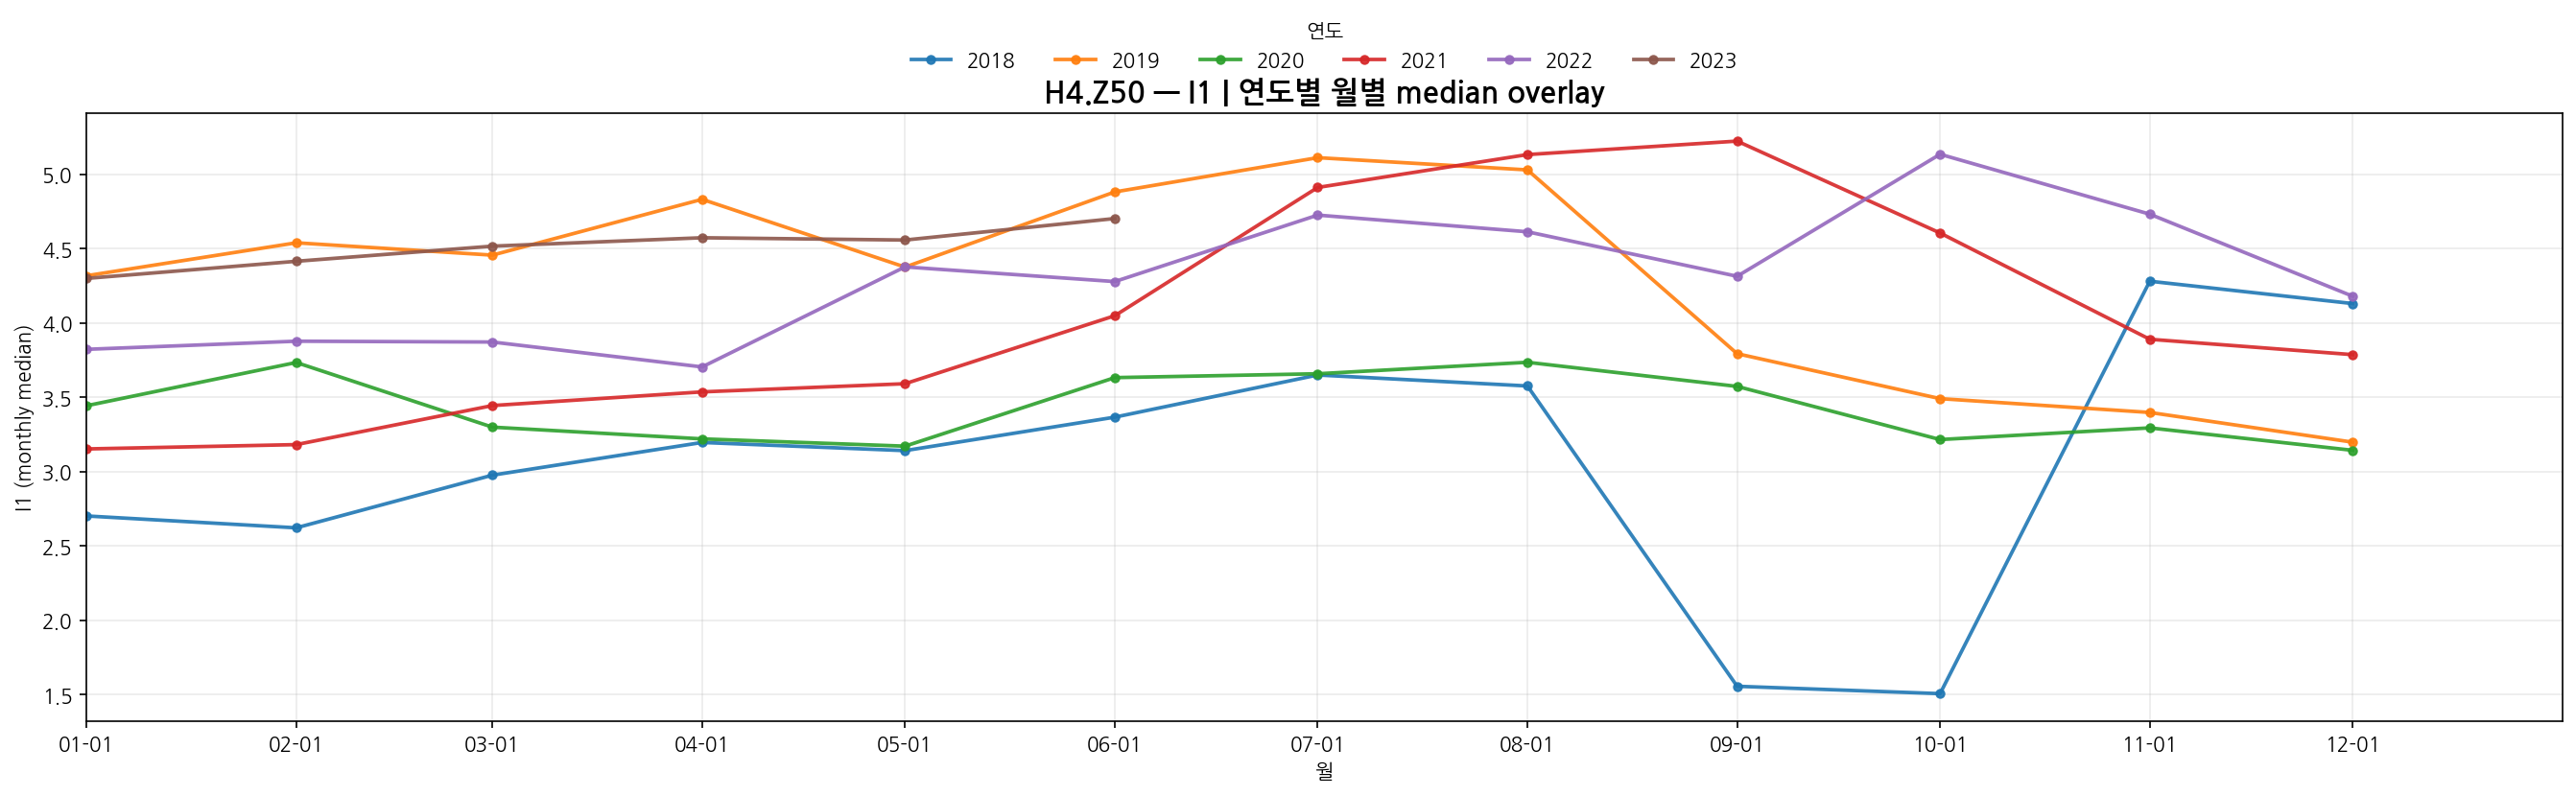

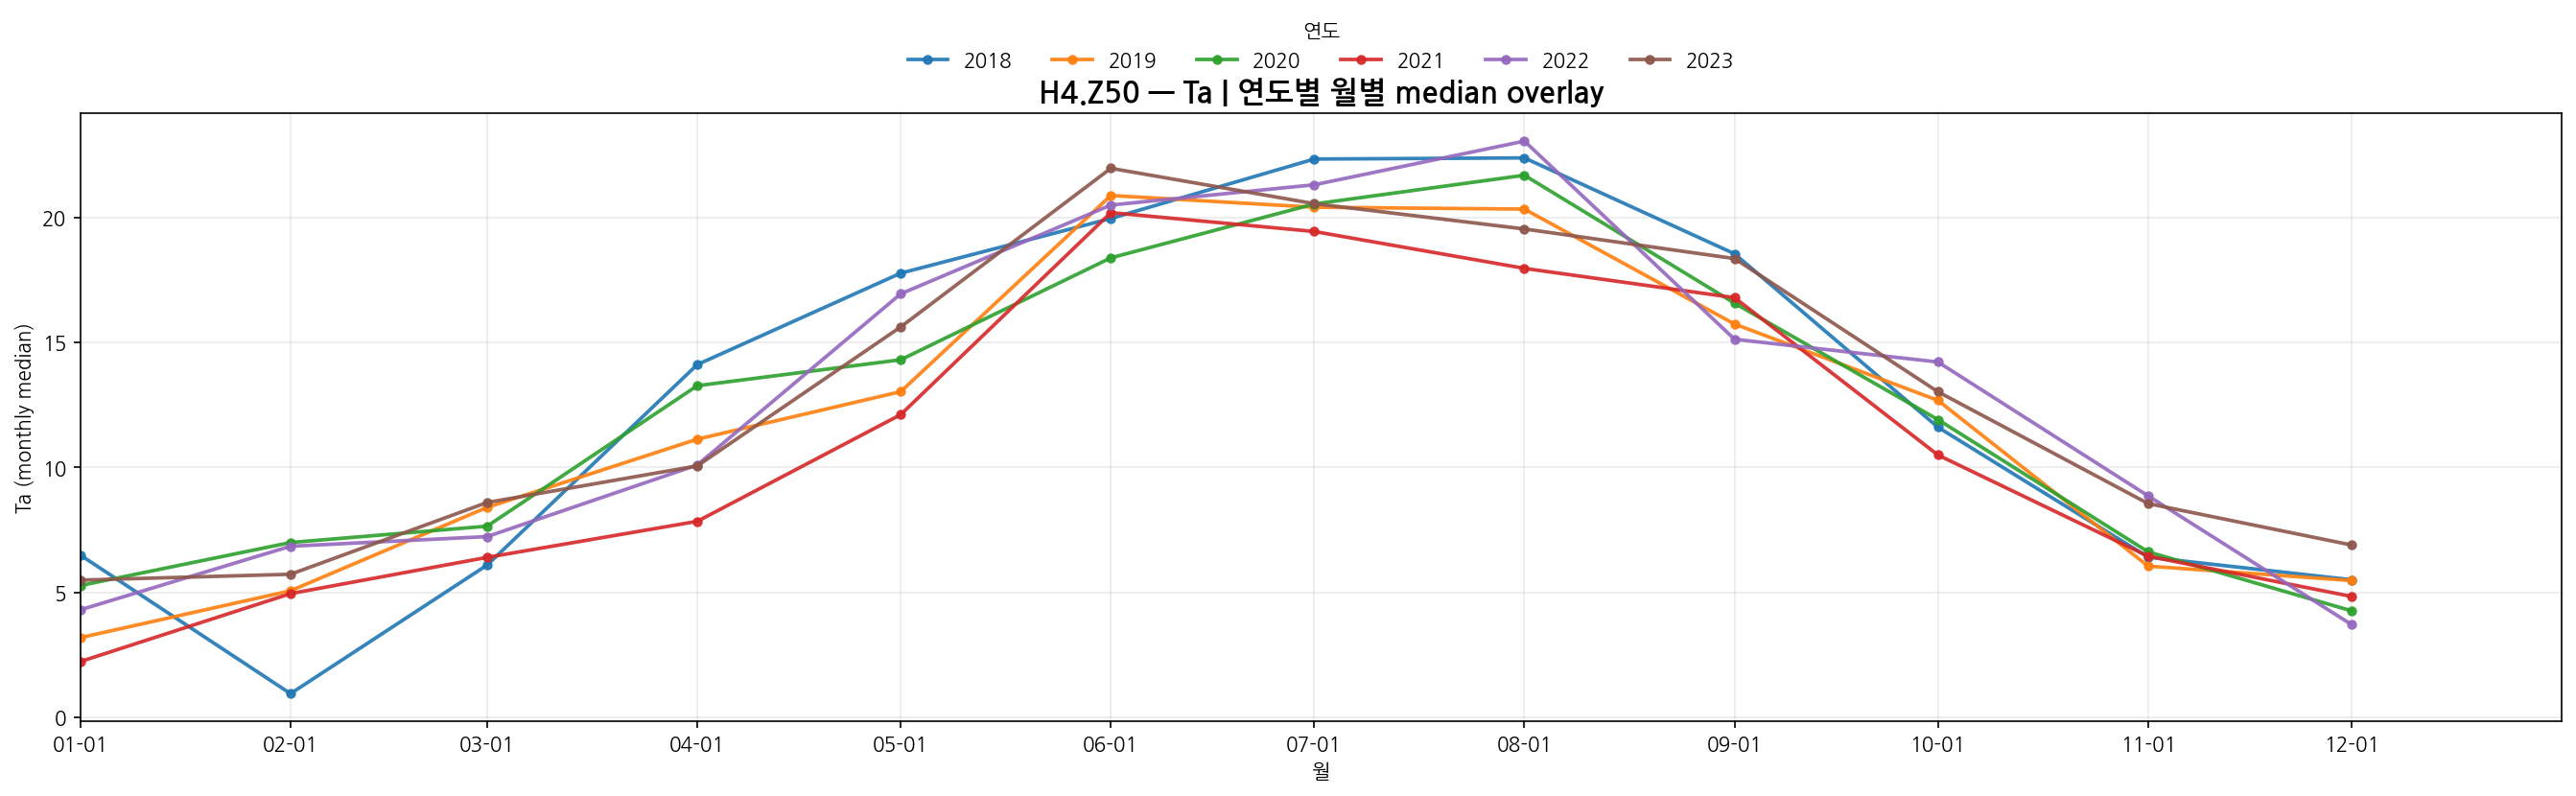

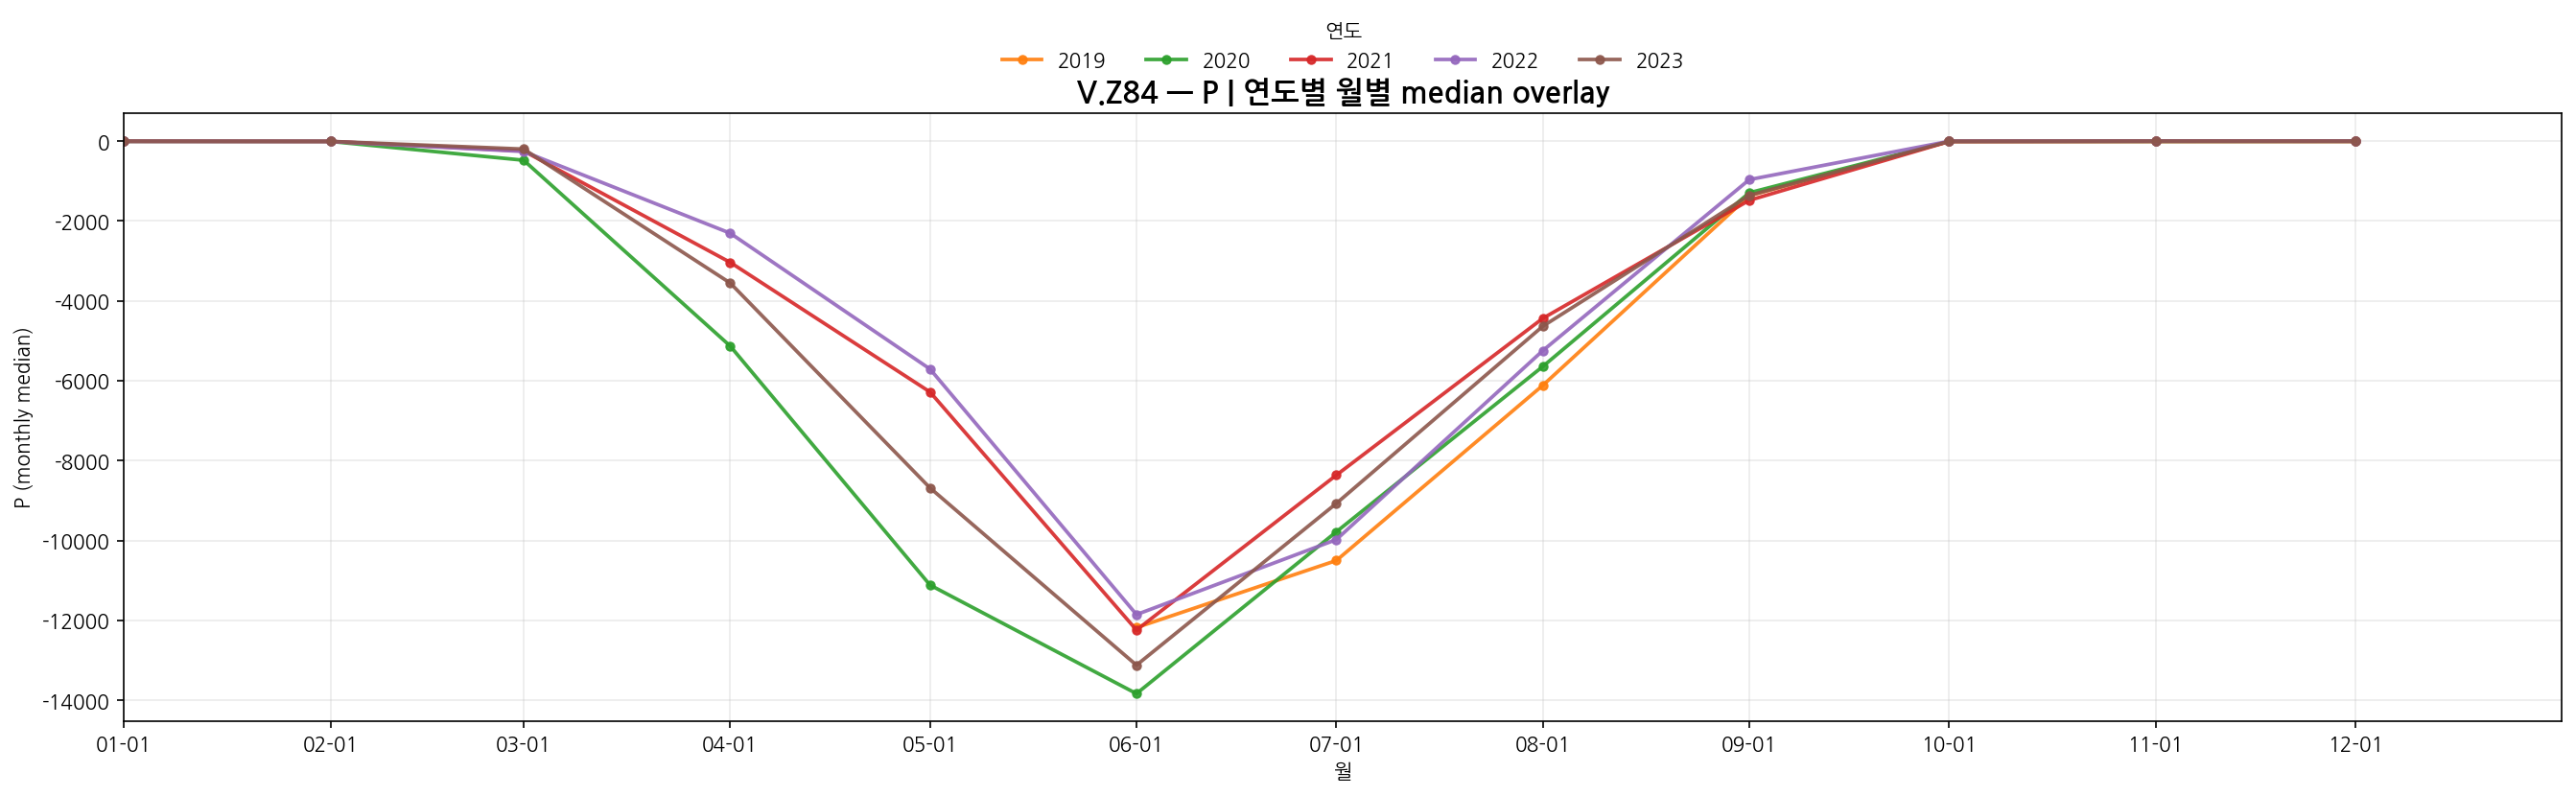

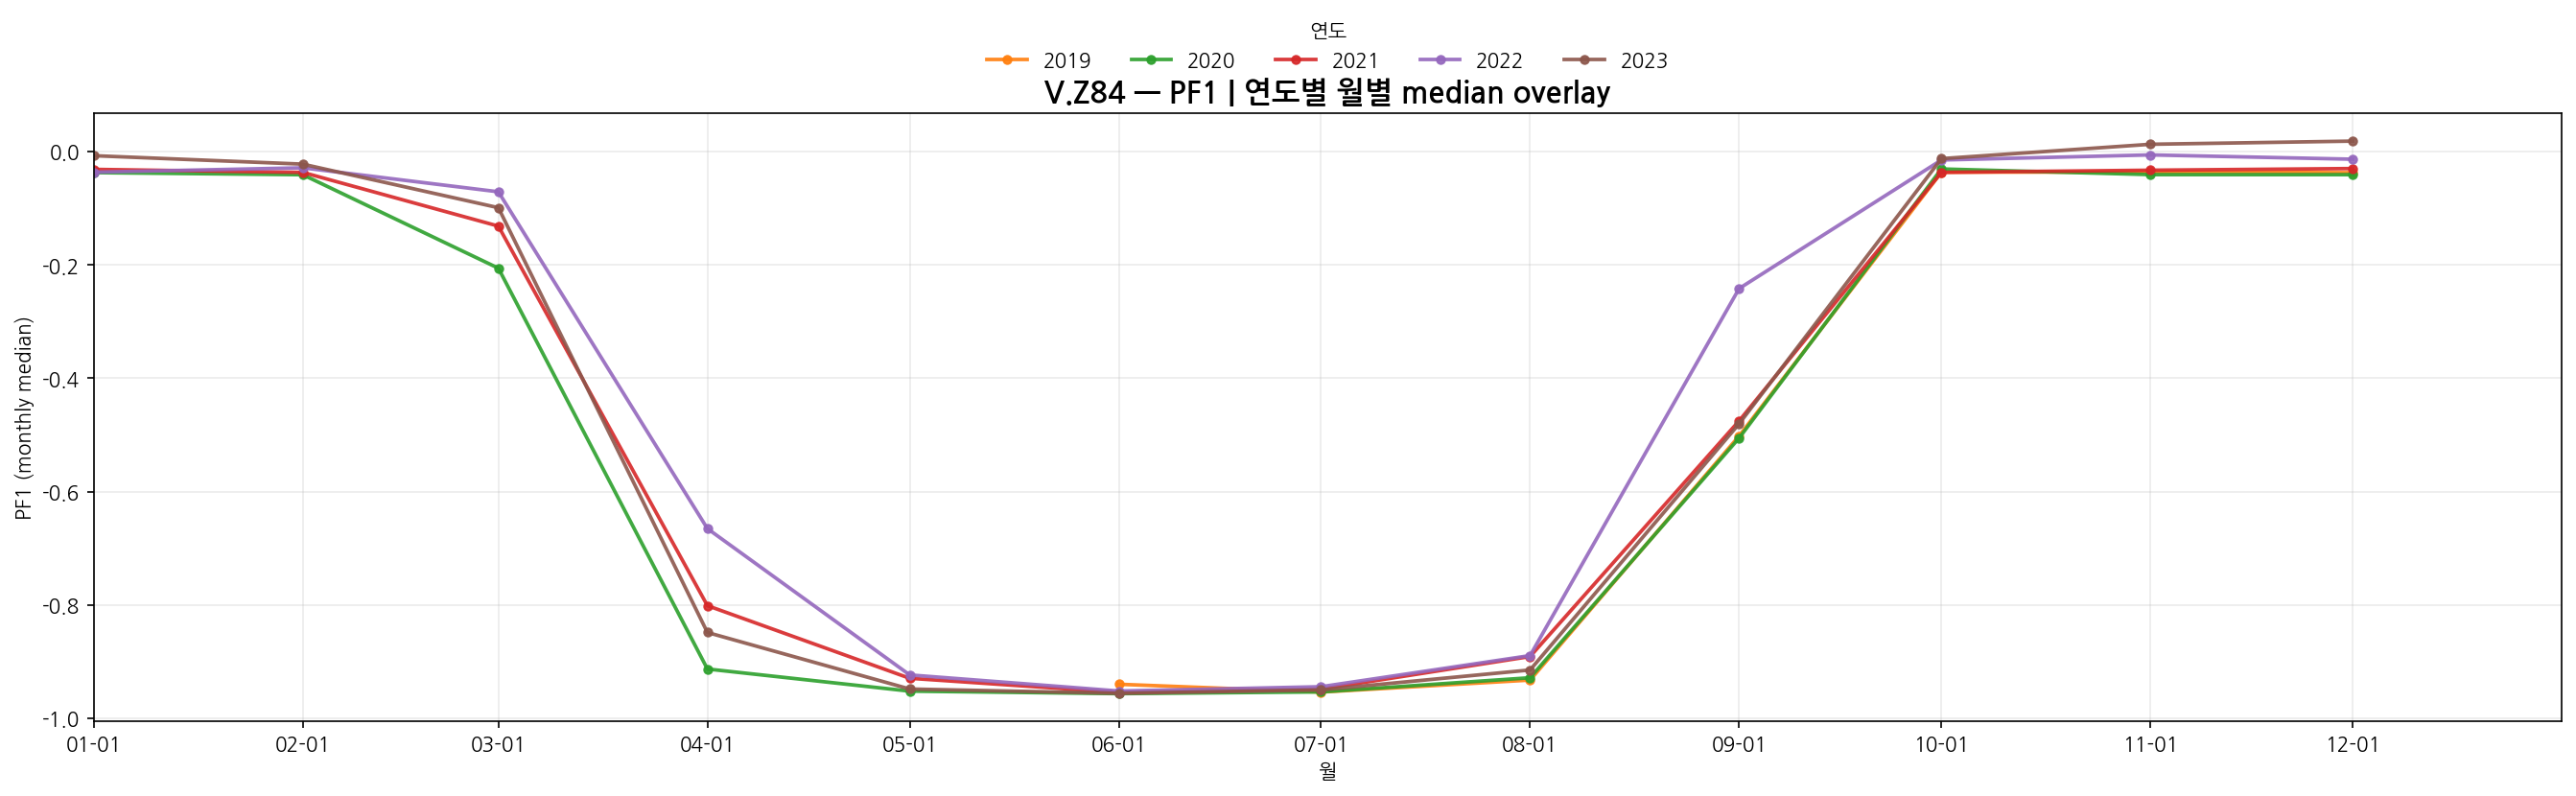

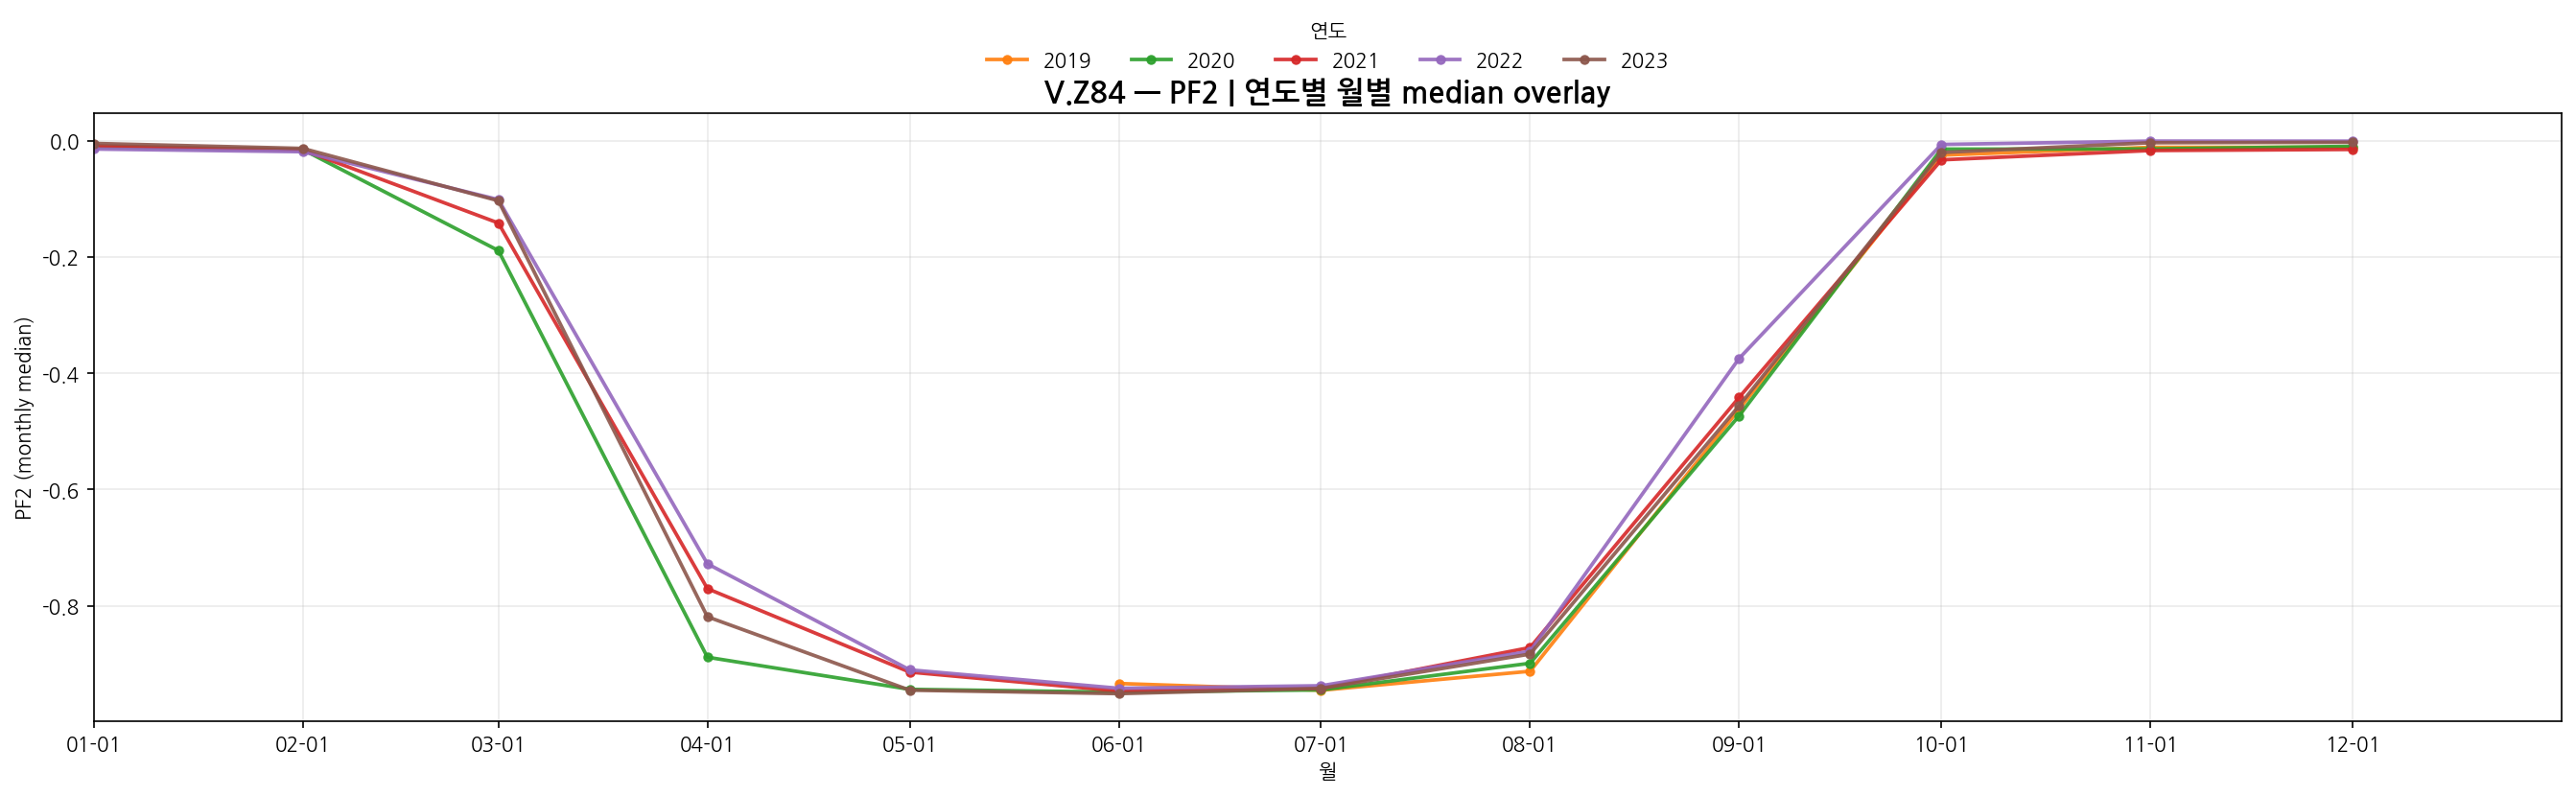

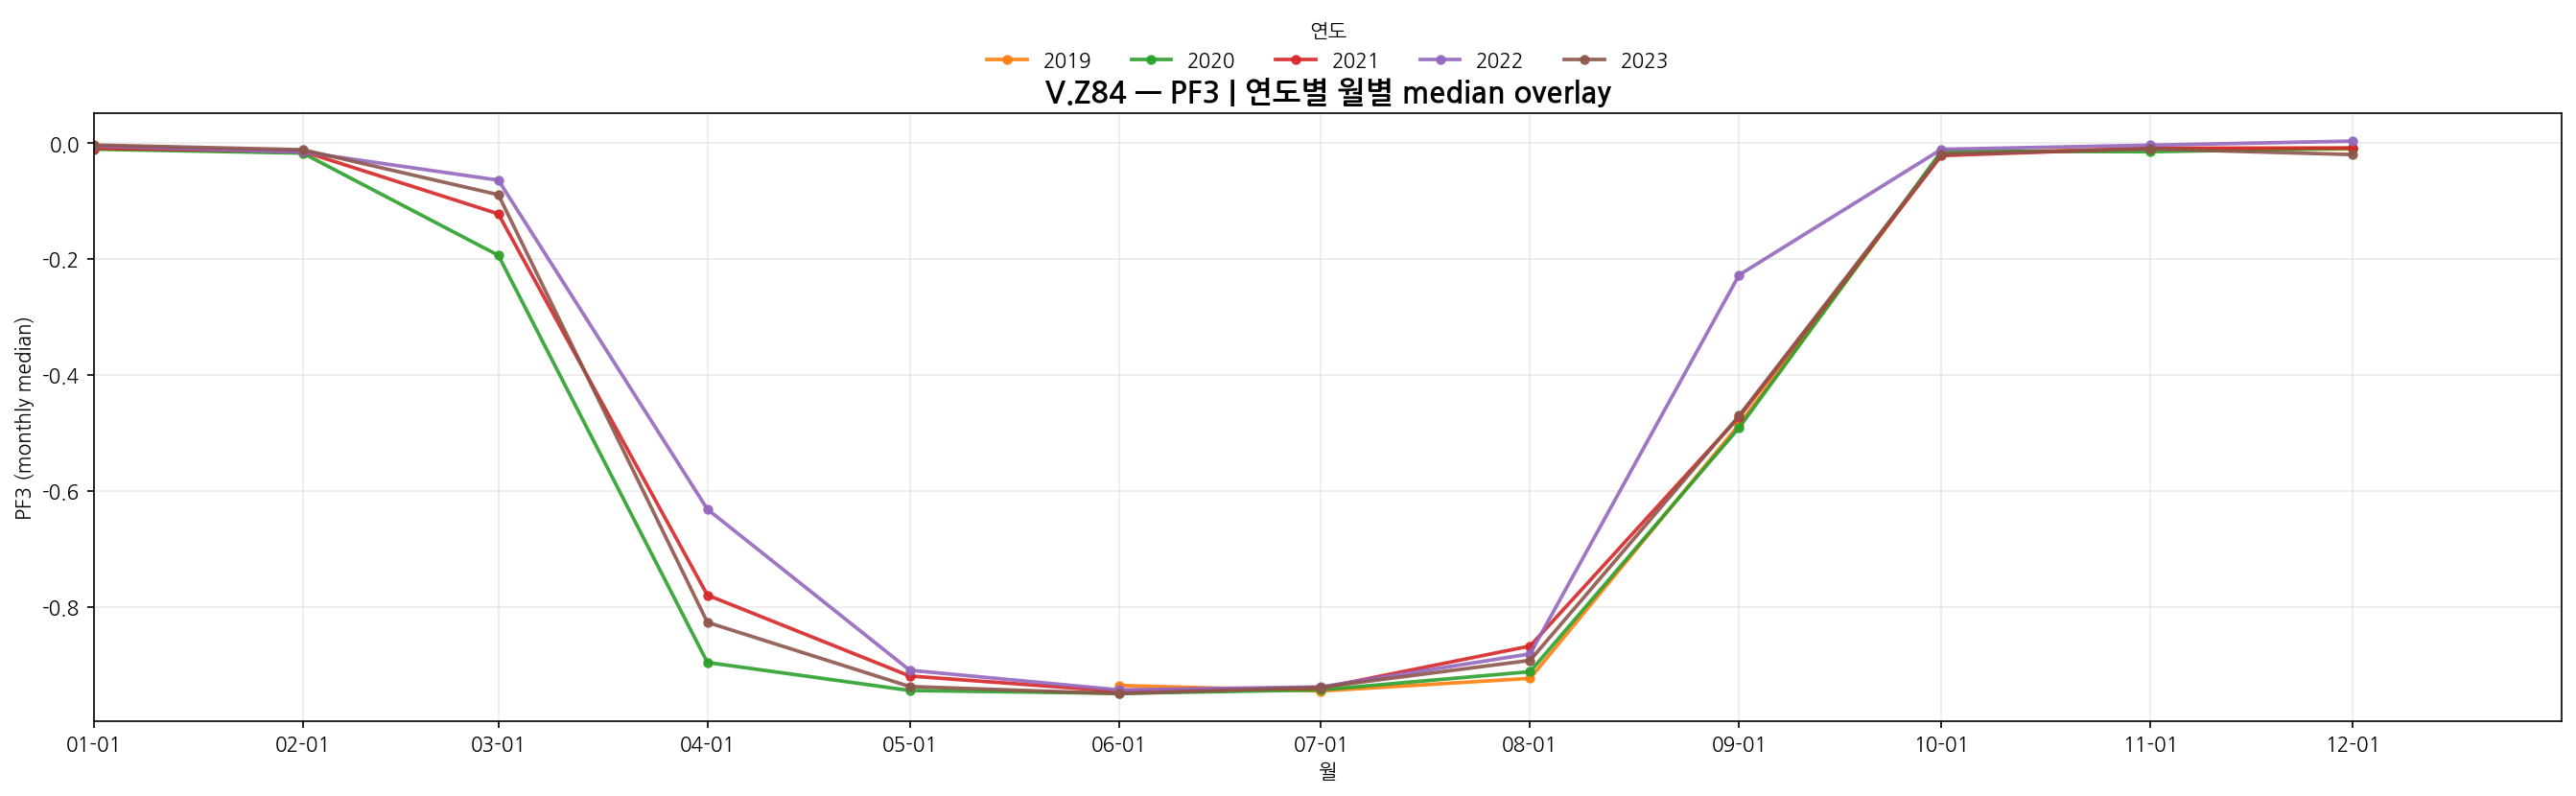

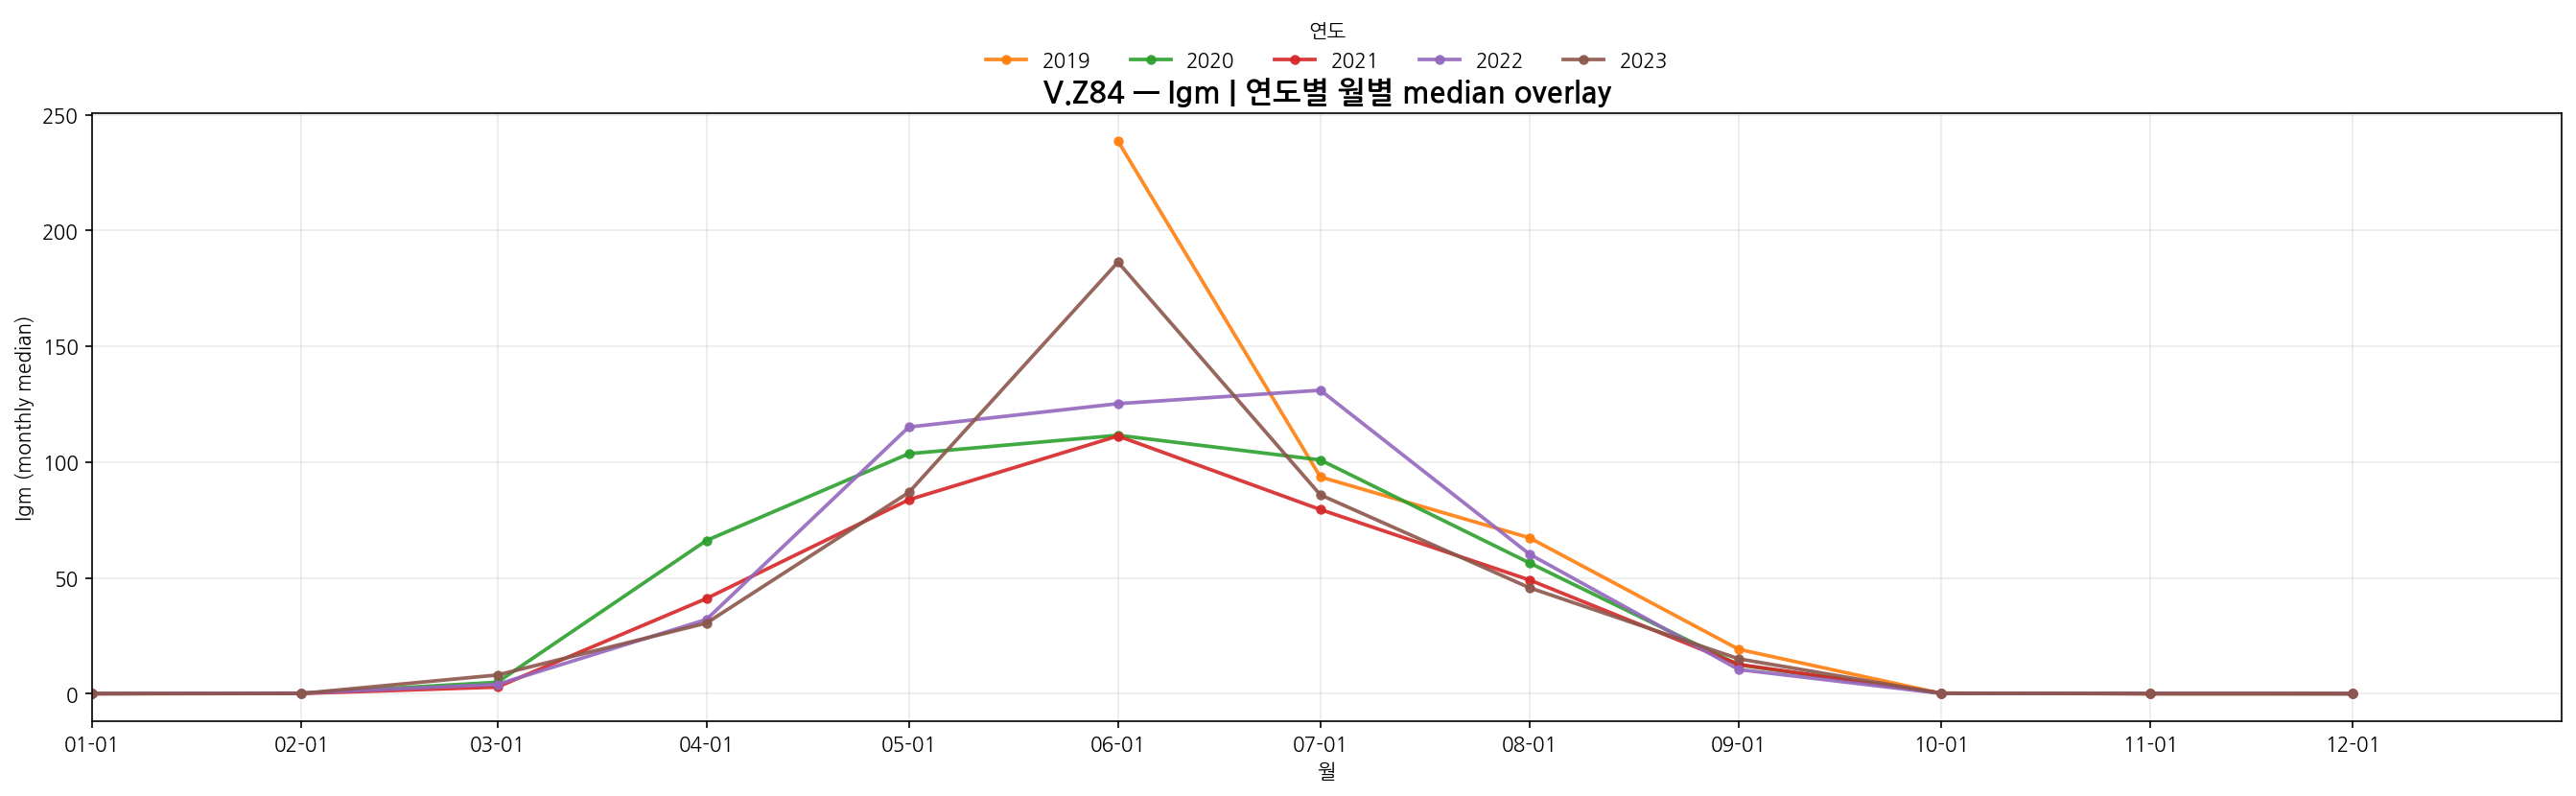

In [2]:
for meter_urn, features in resolved_meter_features.items():
    df = raw_meter_data[meter_urn]
    if not features:
        print(f'{meter_urn}: 유효 컬럼 없음, skip')
        continue

    for feature in features:
        base_sliding_df = build_sliding_frame(df, feature)
        if base_sliding_df.empty or base_sliding_df[feature].dropna().empty:
            print(f'{meter_urn} - {feature}: 유효 데이터 없음, skip')
            continue

        sliding_df = base_sliding_df.copy()
        fig = render_sliding_plot(meter_urn, feature, sliding_df)
        display(Image(data=figure_to_png_bytes(fig)))
        plt.close(fig)


In [3]:
for meter_urn, features in resolved_meter_features.items():
    df = raw_meter_data[meter_urn]
    for feature in features:
        base_sliding_df = build_sliding_frame(df, feature)
        if base_sliding_df.empty or base_sliding_df[feature].dropna().empty:
            continue
        sliding_df = base_sliding_df.copy()
        stats_df = summarize_sliding_by_year(sliding_df, meter_urn, feature)
        if stats_df.empty:
            continue
        print(f'[{meter_urn} — {feature}]')
        display(stats_df[['year', 'mean', 'std', 'min', 'max', 'null_ratio']].set_index('year'))


[H1.Z10 — P]


,mean,std,min,max,null_ratio
year,,,,,
2018,4640.608960,2251.454467,66.510833,21580.695167,0.000000
2019,4498.719749,2065.084486,1037.405963,22846.803333,0.000000
2020,4181.167116,2027.187324,313.300405,20910.257000,0.000000
2021,4966.868807,2082.540775,7.699432,24350.595000,0.000000
2022,4780.413345,2476.702630,-5664.686333,25976.326833,0.000000
2023,3743.958991,1838.181180,44.034000,18408.283333,0.011416


[H1.Z10 — PF]


,mean,std,min,max,null_ratio
year,,,,,
2018,0.916921,0.061347,0.337875,0.996525,0.000000
2019,0.919912,0.023436,0.831275,0.998165,0.000000
2020,0.915130,0.024878,0.826767,0.998575,0.000000
2021,0.939431,0.032871,0.503500,0.998108,0.000000
2022,0.926563,0.100604,-0.885642,0.998950,0.000000
2023,0.892897,0.127275,0.331558,0.999792,0.011416


[H1.Z10 — I1]


...

,mean,std,min,max,null_ratio
year,,,,,
2019,-0.438976,0.452240,-0.972084,0.010440,0.0
2020,-0.454049,0.454064,-0.972473,0.009534,0.0
2021,-0.445922,0.450878,-0.972558,0.008791,0.0
2022,-0.442557,0.453636,-0.974752,0.208606,0.0
2023,-0.445966,0.455012,-0.969664,0.498720,0.0


[V.Z84 — PF3]


,mean,std,min,max,null_ratio
year,,,,,
2019,-0.439771,0.457312,-0.977663,0.021904,0.0
2020,-0.454879,0.458877,-0.976605,0.026326,0.0
2021,-0.443178,0.456544,-0.978650,0.029599,0.0
2022,-0.434684,0.455948,-0.978981,0.207047,0.0
2023,-0.446118,0.458750,-0.975457,0.503868,0.0


[V.Z84 — Igm]


,mean,std,min,max,null_ratio
year,,,,,
2019,123.441010,208.634764,0.0,897.855049,1.522615
2020,133.994330,216.420192,0.0,990.356136,2.060565
2021,126.170875,202.287076,0.0,903.216155,2.534247
2022,138.199808,220.683951,0.0,913.343763,1.495434
2023,129.713821,209.070994,0.0,895.942033,0.000000


In [4]:
print_anomaly_notes()


[확인 필요 구간]
H2.ZE66 PF: |PF|>1 구간 (2023년)
H2.ZE67 PF: |PF|>1 구간 (2023년)
H2.Z35:     2020년 중반 이후 데이터 없음
H2.Z68:     2021년 I1, Q 폭증
H2.T.Z33:   2020년 이후 PF 급증 (PV 역조류)
H1.Z16:     2019년부터 데이터 시작
V.Z84:      2019년 중반부터 데이터 시작
